# Extension Step 1 (v2): Recipe Step Localization with ActionFormer

This notebook implements **Substep 1** of the Task Verification extension, using **ActionFormer** for automatic step localization.

**Goal:**
1.  Use a **ActionFormer**-based model to detect step boundaries (start, end) in recipe videos.
2.  Extract **step-level embeddings** by pooling EgoVLP features within these predicted boundaries.
3.  Save the step features for use in Step 2 (Task Verification).

**Key Features:**
- Implements the full **ActionFormer architecture** (Zhang et al., ECCV 2022)
- Runs on the **complete CaptainCook4D dataset** (384 videos)
- **Multiple hyperparameter configurations** for ablation studies
- **Multiple localization methods** for comprehensive evaluation

**Localization Methods Implemented:**
1. **Ground Truth (GT) Baseline** - Uses `step_annotation.csv` boundaries (upper bound)
2. **ActionFormer** - Full architecture with ConvTransformer backbone + FPN neck
3. **Zero-Shot Clustering** - Unsupervised step discovery using K-Means
4. **Change-Point Detection** - Statistical boundary detection

**ActionFormer Architecture Overview:**
- **Backbone**: ConvTransformer with local self-attention windows
- **Neck**: Feature Pyramid Network (FPN) for multi-scale temporal features
- **Heads**: Classification head + Regression head for boundary prediction

**Reference:**
Zhang et al., "ActionFormer: Localizing Moments of Actions with Transformers", ECCV 2022

In [1]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    # Mount Drive
    drive.mount('/content/drive')

    # Base paths
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"
    CODE_BASE = "/content/code"

    # Clone Main Repository (if not exists)
    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists(CODE_BASE):
        print(f"Cloning repository from {REPO_URL}...")
        !git clone --recursive {REPO_URL} {CODE_BASE}
        os.chdir(CODE_BASE)
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir(CODE_BASE)

    if CODE_BASE not in sys.path:
        sys.path.append(CODE_BASE)

    # Install requirements
    !pip install -q torcheval

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")
    DRIVE_BASE = "."
    CODE_BASE = os.getcwd()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- PATHS ---
if IN_COLAB:
    EGOVLP_FEATURE_DIR = os.path.join(DRIVE_BASE, "features/egovlp")
else:
    EGOVLP_FEATURE_DIR = "data/features/egovlp"

ANNOTATION_PATH = "annotations/annotation_json/step_annotations.json"
SPLIT_PATH = "er_annotations/recordings_combined_splits.json"

print(f"EgoVLP Features: {EGOVLP_FEATURE_DIR}")
print(f"Annotations: {ANNOTATION_PATH}")

Running in Google Colab
Mounted at /content/drive
Cloning repository from https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git...
Cloning into '/content/code'...
remote: Enumerating objects: 543, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 543 (delta 56), reused 75 (delta 28), pack-reused 430 (from 2)
Receiving objects: 100% (543/543), 800.42 KiB | 3.29 MiB/s, done.
Resolving deltas: 100% (337/337), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 3.10 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Subm

## 1. Load Data and Annotations

Load the EgoVLP features and ground truth step boundaries for training.

In [2]:
# Load annotations
with open(ANNOTATION_PATH, 'r') as f:
    step_annotations = json.load(f)

with open(SPLIT_PATH, 'r') as f:
    splits = json.load(f)

print(f"Total recordings: {len(step_annotations)}")
print(f"Train: {len(splits['train'])}, Val: {len(splits['val'])}, Test: {len(splits['test'])}")

# Helper to load features
def load_features(recording_id, feature_dir=EGOVLP_FEATURE_DIR):
    """Load EgoVLP features for a recording."""
    path = os.path.join(feature_dir, f"{recording_id}_360p_224.npz")
    if os.path.exists(path):
        data = np.load(path)
        return data[list(data.keys())[0]]
    return None

# Check feature availability
available_recordings = []
for rec_id in step_annotations.keys():
    if load_features(rec_id) is not None:
        available_recordings.append(rec_id)

print(f"Recordings with available features: {len(available_recordings)}/{len(step_annotations)}")

Total recordings: 384
Train: 287, Val: 48, Test: 48
Recordings with available features: 384/384


## 2. ActionFormer Architecture

We implement the full **ActionFormer** architecture from Zhang et al. (ECCV 2022):

**Architecture Components:**
1. **ConvTransformer Backbone**: 1D convolutions + Transformer with local self-attention
2. **Feature Pyramid Network (FPN)**: Multi-scale temporal feature aggregation
3. **Classification Head**: Per-timestep action class prediction
4. **Regression Head**: Boundary offset regression (start/end distances)

**Key Design Choices:**
- Local self-attention with configurable window size (avoids quadratic complexity)
- Multi-scale FPN for handling actions of different durations
- Point-based detection (no anchors/proposals needed)

In [3]:
# ==============================================================================
# ActionFormer Building Blocks
# Based on: https://github.com/happyharrycn/actionformer_release
# ==============================================================================

import math

def get_sinusoid_encoding(n_position, d_hid):
    """Sinusoidal positional encoding."""
    def get_position_angle_vec(position):
        return [position / np.power(10000, 2 * (hid_j // 2) / d_hid) for hid_j in range(d_hid)]

    sinusoid_table = np.array([get_position_angle_vec(pos_i) for pos_i in range(n_position)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0).transpose(1, 2)


class MaskedConv1D(nn.Module):
    """1D Convolution with masking support."""

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0,
                 dilation=1, groups=1, bias=True, padding_mode='zeros'):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride,
                              padding=padding, dilation=dilation, groups=groups,
                              bias=bias, padding_mode=padding_mode)

    def forward(self, x, mask):
        # x: (B, C, T), mask: (B, 1, T)
        x = self.conv(x)
        if mask is not None:
            # Adjust mask for stride
            if self.conv.stride[0] > 1:
                mask = mask[:, :, ::self.conv.stride[0]]
            x = x * mask.float()
        return x, mask


class LayerNorm(nn.Module):
    """LayerNorm for (B, C, T) format."""

    def __init__(self, num_channels, eps=1e-5, affine=True):
        super().__init__()
        self.num_channels = num_channels
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.weight = nn.Parameter(torch.ones(1, num_channels, 1))
            self.bias = nn.Parameter(torch.zeros(1, num_channels, 1))

    def forward(self, x):
        # x: (B, C, T)
        mu = x.mean(dim=1, keepdim=True)
        sigma = x.var(dim=1, unbiased=False, keepdim=True).clamp(min=self.eps).sqrt()
        x = (x - mu) / sigma
        if self.affine:
            x = x * self.weight + self.bias
        return x


class LocalMaskedMHCA(nn.Module):
    """Local Multi-Head Cross Attention with window-based attention."""

    def __init__(self, n_embd, n_head, window_size, attn_pdrop=0.0, proj_pdrop=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_embd = n_embd
        self.n_head = n_head
        self.n_channels = n_embd // n_head
        self.scale = 1.0 / math.sqrt(self.n_channels)
        self.window_size = window_size

        # key, query, value projections
        self.key = nn.Conv1d(n_embd, n_embd, 1)
        self.query = nn.Conv1d(n_embd, n_embd, 1)
        self.value = nn.Conv1d(n_embd, n_embd, 1)

        # output projection
        self.proj = nn.Conv1d(n_embd, n_embd, 1)

        # dropouts
        self.attn_drop = nn.Dropout(attn_pdrop)
        self.proj_drop = nn.Dropout(proj_pdrop)

    def forward(self, x, mask):
        # x: (B, C, T), mask: (B, 1, T)
        B, C, T = x.size()

        # qkv projection
        q = self.query(x)  # (B, C, T)
        k = self.key(x)
        v = self.value(x)

        # reshape for multi-head: (B, nh, C/nh, T)
        q = q.view(B, self.n_head, self.n_channels, T)
        k = k.view(B, self.n_head, self.n_channels, T)
        v = v.view(B, self.n_head, self.n_channels, T)

        # Use local window attention or full attention
        if self.window_size > 0 and T > self.window_size:
            # For simplicity, use chunked attention
            out = self._windowed_attention(q, k, v, mask, T)
        else:
            # Full attention
            attn = (q.transpose(-2, -1) @ k) * self.scale  # (B, nh, T, T)
            if mask is not None:
                mask_float = mask.unsqueeze(1).float()  # (B, 1, 1, T)
                attn = attn.masked_fill(mask_float == 0, float('-inf'))
            attn = F.softmax(attn, dim=-1)
            attn = self.attn_drop(attn)
            out = (attn @ v.transpose(-2, -1)).transpose(-2, -1)  # (B, nh, C/nh, T)

        # merge heads
        out = out.contiguous().view(B, C, T)
        out = self.proj_drop(self.proj(out))

        return out, mask

    def _windowed_attention(self, q, k, v, mask, T):
        """Simplified windowed attention."""
        B, nh, d, _ = q.shape
        ws = min(self.window_size, T)

        # Pad to make divisible by window size
        pad_len = (ws - T % ws) % ws
        if pad_len > 0:
            q = F.pad(q, (0, pad_len))
            k = F.pad(k, (0, pad_len))
            v = F.pad(v, (0, pad_len))

        T_padded = T + pad_len
        num_windows = T_padded // ws

        # Reshape to windows: (B, nh, d, num_windows, ws)
        q = q.view(B, nh, d, num_windows, ws)
        k = k.view(B, nh, d, num_windows, ws)
        v = v.view(B, nh, d, num_windows, ws)

        # Attention within windows
        attn = (q.permute(0, 1, 3, 4, 2) @ k.permute(0, 1, 3, 2, 4)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v.permute(0, 1, 3, 4, 2)).permute(0, 1, 4, 2, 3)  # (B, nh, d, num_windows, ws)
        out = out.contiguous().view(B, nh, d, T_padded)

        # Remove padding
        out = out[..., :T]
        return out


class TransformerBlock(nn.Module):
    """Transformer block with local self-attention and MLP."""

    def __init__(self, n_embd, n_head, n_ds_strides=(1, 1),
                 attn_pdrop=0.0, proj_pdrop=0.0, path_pdrop=0.0,
                 mha_win_size=-1):
        super().__init__()
        self.ln1 = LayerNorm(n_embd)
        self.ln2 = LayerNorm(n_embd)

        # Attention
        window_size = mha_win_size if mha_win_size > 0 else -1
        self.attn = LocalMaskedMHCA(n_embd, n_head, window_size, attn_pdrop, proj_pdrop)

        # MLP
        self.mlp = nn.Sequential(
            nn.Conv1d(n_embd, n_embd * 4, 1),
            nn.GELU(),
            nn.Dropout(proj_pdrop),
            nn.Conv1d(n_embd * 4, n_embd, 1),
            nn.Dropout(proj_pdrop),
        )

        # Downsampling
        self.stride = n_ds_strides[0]
        if self.stride > 1:
            self.pool_skip = nn.MaxPool1d(self.stride, stride=self.stride, padding=self.stride // 2)
        else:
            self.pool_skip = nn.Identity()

        # Drop path
        self.drop_path = path_pdrop

    def forward(self, x, mask):
        # Pre-LN transformer
        out, out_mask = self.attn(self.ln1(x), mask)

        # Residual with pooling
        if self.stride > 1:
            # Downsample attention output and x
            out = self.pool_skip(out)
            x = self.pool_skip(x)
            # Downsample mask to match dimensions
            if out_mask is not None:
                out_mask = self.pool_skip(out_mask.float())

        out_mask_float = out_mask.float() if out_mask is not None else 1.0
        out = x * out_mask_float + out

        # MLP
        out = out + self.mlp(self.ln2(out)) * out_mask_float

        return out, out_mask


class ConvTransformerBackbone(nn.Module):
    """
    ActionFormer Backbone: Convolutions + Transformer with local self-attention.
    """

    def __init__(self, n_in, n_embd, n_head, n_embd_ks=3, max_len=2048,
                 arch=(2, 2, 5), mha_win_size=[-1]*6, scale_factor=2,
                 with_ln=True, attn_pdrop=0.0, proj_pdrop=0.0, path_pdrop=0.0):
        super().__init__()
        self.n_in = n_in
        self.arch = arch
        self.max_len = max_len
        self.scale_factor = scale_factor
        self.mha_win_size = mha_win_size

        # Feature embedding
        self.embd = nn.ModuleList()
        self.embd_norm = nn.ModuleList()
        for idx in range(arch[0]):
            in_dim = n_in if idx == 0 else n_embd
            self.embd.append(MaskedConv1D(in_dim, n_embd, n_embd_ks, padding=n_embd_ks//2))
            self.embd_norm.append(LayerNorm(n_embd) if with_ln else nn.Identity())

        # Positional encoding
        self.pos_embd = get_sinusoid_encoding(max_len, n_embd)

        # Stem transformers (no downsampling)
        self.stem = nn.ModuleList()
        for idx in range(arch[1]):
            self.stem.append(
                TransformerBlock(n_embd, n_head, n_ds_strides=(1, 1),
                                 attn_pdrop=attn_pdrop, proj_pdrop=proj_pdrop,
                                 path_pdrop=path_pdrop, mha_win_size=mha_win_size[0])
            )

        # Branch transformers (with downsampling)
        self.branch = nn.ModuleList()
        for idx in range(arch[2]):
            self.branch.append(
                TransformerBlock(n_embd, n_head, n_ds_strides=(scale_factor, scale_factor),
                                 attn_pdrop=attn_pdrop, proj_pdrop=proj_pdrop,
                                 path_pdrop=path_pdrop, mha_win_size=mha_win_size[1 + idx])
            )

    def forward(self, x, mask):
        # x: (B, C, T), mask: (B, 1, T)
        B, C, T = x.size()

        # Embedding
        for idx, (embd, norm) in enumerate(zip(self.embd, self.embd_norm)):
            x, mask = embd(x, mask)
            x = F.relu(norm(x))

        # Add positional encoding
        if T <= self.max_len:
            pe = self.pos_embd[:, :, :T].to(x.device)
        else:
            pe = F.interpolate(self.pos_embd.to(x.device), T, mode='linear', align_corners=False)
        x = x + pe * mask.float()

        # Stem (no downsampling)
        for block in self.stem:
            x, mask = block(x, mask)

        # Collect multi-scale outputs
        out_feats = (x,)
        out_masks = (mask,)

        # Branch (with downsampling)
        for block in self.branch:
            x, mask = block(x, mask)
            out_feats = out_feats + (x,)
            out_masks = out_masks + (mask,)

        return out_feats, out_masks


class FPN1D(nn.Module):
    """Feature Pyramid Network for 1D temporal features."""

    def __init__(self, in_channels, out_channel, scale_factor=2.0, with_ln=True):
        super().__init__()
        self.scale_factor = scale_factor

        # Lateral connections
        self.lateral_convs = nn.ModuleList()
        self.fpn_convs = nn.ModuleList()
        self.fpn_norms = nn.ModuleList()

        for i, in_ch in enumerate(in_channels):
            l_conv = MaskedConv1D(in_ch, out_channel, 1)
            fpn_conv = MaskedConv1D(out_channel, out_channel, 3, padding=1, groups=out_channel)
            fpn_norm = LayerNorm(out_channel) if with_ln else nn.Identity()

            self.lateral_convs.append(l_conv)
            self.fpn_convs.append(fpn_conv)
            self.fpn_norms.append(fpn_norm)

    def forward(self, inputs, fpn_masks):
        # Build laterals
        laterals = []
        for i, (lat_conv, (feat, mask)) in enumerate(zip(self.lateral_convs, zip(inputs, fpn_masks))):
            lat, _ = lat_conv(feat, mask)
            laterals.append(lat)

        # Top-down pathway
        for i in range(len(laterals) - 1, 0, -1):
            # Upsample to match dimension of previous level
            # This handles cases where size is not exactly 2x due to odd dimensions/padding
            target_size = laterals[i - 1].shape[-1]
            laterals[i - 1] = laterals[i - 1] + F.interpolate(
                laterals[i], size=target_size, mode='nearest'
            )

        # Output convolutions
        fpn_feats = []
        new_masks = []
        for i, (lat, mask) in enumerate(zip(laterals, fpn_masks)):
            out, new_mask = self.fpn_convs[i](lat, mask)
            out = self.fpn_norms[i](out)
            fpn_feats.append(out)
            new_masks.append(new_mask)

        return tuple(fpn_feats), tuple(new_masks)


class PointGenerator(nn.Module):
    """Generate point coordinates for each FPN level."""

    def __init__(self, max_seq_len, fpn_strides, regression_range):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.fpn_strides = fpn_strides
        self.regression_range = regression_range

    def forward(self, fpn_feats):
        points = []
        for l, feat in enumerate(fpn_feats):
            T = feat.size(-1)
            stride = self.fpn_strides[l]
            reg_range = self.regression_range[l]

            # Generate points at center of each temporal location
            pts = torch.arange(0, T, dtype=torch.float32, device=feat.device)
            pts = pts * stride + stride / 2

            # Stack: (T, 4) - [time, stride, reg_min, reg_max]
            pts_info = torch.stack([
                pts,
                torch.full_like(pts, stride),
                torch.full_like(pts, reg_range[0]),
                torch.full_like(pts, reg_range[1])
            ], dim=-1)
            points.append(pts_info)

        return points


class ActionFormer(nn.Module):
    """
    Full ActionFormer Model for Temporal Action Localization.

    Reference: Zhang et al., "ActionFormer: Localizing Moments of Actions
    with Transformers", ECCV 2022.

    Architecture:
    1. ConvTransformer Backbone: Local self-attention with multi-scale outputs
    2. FPN Neck: Feature pyramid for multi-scale temporal features
    3. Classification Head: Per-timestep class prediction
    4. Regression Head: Boundary offset regression
    """

    def __init__(
        self,
        input_dim=256,           # Input feature dimension (EgoVLP=256)
        embd_dim=256,            # Embedding dimension
        n_head=4,                # Number of attention heads
        embd_kernel_size=3,      # Kernel size for embedding conv
        max_seq_len=2048,        # Maximum sequence length
        arch=(2, 2, 5),          # (#embed_convs, #stem_transformers, #branch_transformers)
        mha_win_size=19,         # Local attention window size (-1 for global)
        scale_factor=2,          # Downsampling factor between FPN levels
        fpn_dim=256,             # FPN output dimension
        head_dim=256,            # Head hidden dimension
        num_classes=1,           # Number of action classes (1 for binary boundary)
        regression_range=None,   # Regression range for each FPN level
        attn_pdrop=0.0,
        proj_pdrop=0.0,
        path_pdrop=0.1,
    ):
        super().__init__()

        self.input_dim = input_dim
        self.num_classes = num_classes
        self.max_seq_len = max_seq_len
        self.scale_factor = scale_factor

        # Compute FPN strides
        self.fpn_strides = [scale_factor ** i for i in range(arch[2] + 1)]

        # Default regression range - Extended to support deeper architectures
        if regression_range is None:
            regression_range = [
                (0, 4), (4, 8), (8, 16), (16, 32),
                (32, 64), (64, 128), (128, 256), (256, 512), (512, 1024)
            ]

        # Select ranges for the current number of levels
        self.regression_range = regression_range[:arch[2] + 1]

        # Ensure the last level handles all larger scales
        if len(self.regression_range) > 0:
             self.regression_range[-1] = (self.regression_range[-1][0], float('inf'))

        # Window sizes for each level
        if isinstance(mha_win_size, int):
            mha_win_size = [mha_win_size] * (1 + arch[2])

        # Backbone
        self.backbone = ConvTransformerBackbone(
            n_in=input_dim,
            n_embd=embd_dim,
            n_head=n_head,
            n_embd_ks=embd_kernel_size,
            max_len=max_seq_len,
            arch=arch,
            mha_win_size=mha_win_size,
            scale_factor=scale_factor,
            attn_pdrop=attn_pdrop,
            proj_pdrop=proj_pdrop,
            path_pdrop=path_pdrop,
        )

        # FPN Neck
        fpn_in_channels = [embd_dim] * (arch[2] + 1)
        self.neck = FPN1D(fpn_in_channels, fpn_dim, scale_factor=scale_factor)

        # Point generator
        self.point_generator = PointGenerator(max_seq_len, self.fpn_strides, self.regression_range)

        # Classification head (multi-level)
        self.cls_head = nn.ModuleList()
        for _ in range(len(self.fpn_strides)):
            self.cls_head.append(nn.Sequential(
                nn.Conv1d(fpn_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, num_classes, 3, padding=1),
            ))

        # Regression head (multi-level)
        self.reg_head = nn.ModuleList()
        for _ in range(len(self.fpn_strides)):
            self.reg_head.append(nn.Sequential(
                nn.Conv1d(fpn_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, head_dim, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv1d(head_dim, 2, 3, padding=1),  # Start and end offsets
                nn.ReLU(),  # Offsets should be positive
            ))

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv1d)):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x, mask=None):
        """
        Args:
            x: (B, T, C) or (B, C, T) - Input features
            mask: (B, T) - Optional mask for valid positions

        Returns:
            out_cls_logits: List of (B, num_classes, T_i) for each FPN level
            out_offsets: List of (B, 2, T_i) for each FPN level
            points: List of (T_i, 4) point info for each FPN level
        """
        B = x.size(0)

        # Ensure (B, C, T) format
        if x.dim() == 3 and x.size(-1) != self.input_dim and x.size(1) == self.input_dim:
            pass  # Already (B, C, T)
        elif x.dim() == 3 and x.size(-1) == self.input_dim:
            x = x.transpose(1, 2)  # (B, T, C) -> (B, C, T)

        T = x.size(-1)

        # Create mask if not provided
        if mask is None:
            mask = torch.ones(B, 1, T, device=x.device, dtype=torch.bool)
        elif mask.dim() == 2:
            mask = mask.unsqueeze(1)  # (B, T) -> (B, 1, T)

        # Backbone
        feats, masks = self.backbone(x, mask)

        # FPN
        fpn_feats, fpn_masks = self.neck(feats, masks)

        # Generate points
        points = self.point_generator(fpn_feats)

        # Apply heads
        out_cls_logits = []
        out_offsets = []

        for l, (feat, fpn_mask) in enumerate(zip(fpn_feats, fpn_masks)):
            cls_logits = self.cls_head[l](feat)
            offsets = self.reg_head[l](feat)

            out_cls_logits.append(cls_logits)
            out_offsets.append(offsets)

        return out_cls_logits, out_offsets, points, fpn_masks

    def predict_boundaries(self, x, mask=None, threshold=0.5, nms_threshold=0.5):
        """
        Predict step boundaries from features.

        Returns:
            List of (start_time, end_time, score) tuples
        """
        self.eval()
        with torch.no_grad():
            out_cls, out_offsets, points, fpn_masks = self.forward(x, mask)

        all_segments = []
        all_scores = []

        for l, (cls_logits, offsets, pts, m) in enumerate(zip(out_cls, out_offsets, points, fpn_masks)):
            # cls_logits: (B, 1, T), offsets: (B, 2, T)
            probs = torch.sigmoid(cls_logits).squeeze(1)  # (B, T)

            # Get predictions above threshold
            batch_size = probs.size(0)
            for b in range(batch_size):
                prob = probs[b]  # (T,)
                offset = offsets[b]  # (2, T)
                point = pts  # (T, 4)

                above_thresh = prob > threshold
                if not above_thresh.any():
                    continue

                # Get center points and offsets
                centers = point[above_thresh, 0]  # Time positions
                stride = point[above_thresh, 1]
                start_offset = offset[0, above_thresh]
                end_offset = offset[1, above_thresh]

                # Compute segment boundaries
                starts = centers - start_offset * stride
                ends = centers + end_offset * stride
                scores = prob[above_thresh]

                all_segments.append(torch.stack([starts, ends], dim=-1))
                all_scores.append(scores)

        if not all_segments:
            return []

        # Concatenate all predictions
        all_segments = torch.cat(all_segments, dim=0)
        all_scores = torch.cat(all_scores, dim=0)

        # Apply NMS
        segments_np = all_segments.cpu().numpy()
        scores_np = all_scores.cpu().numpy()

        # Simple NMS
        keep = self._nms(segments_np, scores_np, nms_threshold)

        results = []
        for idx in keep:
            results.append({
                'segment': [float(segments_np[idx, 0]), float(segments_np[idx, 1])],
                'score': float(scores_np[idx])
            })

        return sorted(results, key=lambda x: x['segment'][0])

    def _nms(self, segments, scores, threshold):
        """Non-maximum suppression for temporal segments."""
        if len(segments) == 0:
            return []

        # Sort by score
        order = scores.argsort()[::-1]
        keep = []

        while order.size > 0:
            i = order[0]
            keep.append(i)

            # Compute IoU with rest
            xx1 = np.maximum(segments[i, 0], segments[order[1:], 0])
            xx2 = np.minimum(segments[i, 1], segments[order[1:], 1])
            inter = np.maximum(0, xx2 - xx1)

            len_i = segments[i, 1] - segments[i, 0]
            len_rest = segments[order[1:], 1] - segments[order[1:], 0]
            union = len_i + len_rest - inter

            iou = inter / (union + 1e-8)

            # Keep segments with low IoU
            inds = np.where(iou <= threshold)[0]
            order = order[inds + 1]

        return keep


print("ActionFormer model defined (full architecture).")
print("Components: ConvTransformerBackbone + FPN1D + Classification/Regression Heads")

ActionFormer model defined (full architecture).
Components: ConvTransformerBackbone + FPN1D + Classification/Regression Heads


In [4]:
class StepLocalizationDataset(Dataset):
    """
    Dataset for training step boundary detection.
    Creates binary labels: 1 at step boundary frames, 0 elsewhere.
    """

    def __init__(self, recording_ids, annotations, feature_dir, max_len=2000, feature_fps=30):
        self.recording_ids = recording_ids
        self.annotations = annotations
        self.feature_dir = feature_dir
        self.max_len = max_len
        self.feature_fps = feature_fps

        # Filter to only recordings with features
        self.valid_ids = []
        for rec_id in recording_ids:
            if load_features(rec_id, feature_dir) is not None:
                self.valid_ids.append(rec_id)

        print(f"Dataset: {len(self.valid_ids)} valid recordings out of {len(recording_ids)}")

    def __len__(self):
        return len(self.valid_ids)

    def __getitem__(self, idx):
        rec_id = self.valid_ids[idx]

        # Load features
        features = load_features(rec_id, self.feature_dir)
        seq_len = len(features)

        # Create boundary labels (1 at step start/end, 0 elsewhere)
        boundary_labels = np.zeros(seq_len, dtype=np.float32)

        steps = self.annotations[rec_id]['steps']
        for step in steps:
            start_frame = int(float(step['start_time']) * self.feature_fps)
            end_frame = int(float(step['end_time']) * self.feature_fps)

            # Mark boundaries (with small tolerance window)
            tolerance = 3  # frames
            for offset in range(-tolerance, tolerance + 1):
                if 0 <= start_frame + offset < seq_len:
                    boundary_labels[start_frame + offset] = 1.0
                if 0 <= end_frame + offset < seq_len:
                    boundary_labels[end_frame + offset] = 1.0

        # Truncate or pad
        if seq_len > self.max_len:
            features = features[:self.max_len]
            boundary_labels = boundary_labels[:self.max_len]
            seq_len = self.max_len

        return {
            'recording_id': rec_id,
            'features': torch.tensor(features, dtype=torch.float32),
            'boundary_labels': torch.tensor(boundary_labels, dtype=torch.float32),
            'seq_len': seq_len
        }

def collate_fn(batch):
    """Collate with padding."""
    max_len = max(item['seq_len'] for item in batch)

    features = []
    labels = []
    masks = []
    rec_ids = []

    for item in batch:
        seq_len = item['seq_len']
        feat = item['features']
        label = item['boundary_labels']

        # Pad
        if seq_len < max_len:
            pad_len = max_len - seq_len
            feat = F.pad(feat, (0, 0, 0, pad_len))
            label = F.pad(label, (0, pad_len))

        features.append(feat)
        labels.append(label)

        # Create mask (1 for valid, 0 for padding)
        mask = torch.zeros(max_len)
        mask[:seq_len] = 1
        masks.append(mask)
        rec_ids.append(item['recording_id'])

    return {
        'recording_ids': rec_ids,
        'features': torch.stack(features),
        'boundary_labels': torch.stack(labels),
        'masks': torch.stack(masks)
    }

print("Dataset class defined.")

Dataset class defined.


In [5]:
# ==============================================================================
# Dataset Setup - Full CaptainCook4D Dataset (384 Videos)
# ==============================================================================

print("=" * 60)
print("DATASET SETUP - Full CaptainCook4D Dataset")
print("=" * 60)

# Get all available recordings across splits
all_train_ids = [r for r in splits['train'] if r in available_recordings]
all_val_ids = [r for r in splits['val'] if r in available_recordings]
all_test_ids = [r for r in splits['test'] if r in available_recordings]

print(f"Train recordings: {len(all_train_ids)}")
print(f"Val recordings: {len(all_val_ids)}")
print(f"Test recordings: {len(all_test_ids)}")
print(f"Total: {len(all_train_ids) + len(all_val_ids) + len(all_test_ids)}")

train_dataset = StepLocalizationDataset(
    all_train_ids, step_annotations, EGOVLP_FEATURE_DIR
)
val_dataset = StepLocalizationDataset(
    all_val_ids, step_annotations, EGOVLP_FEATURE_DIR
)
test_dataset = StepLocalizationDataset(
    all_test_ids, step_annotations, EGOVLP_FEATURE_DIR
)

# DataLoaders
BATCH_SIZE = 4  # Adjust based on GPU memory
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DATASET SETUP - Full CaptainCook4D Dataset
Train recordings: 287
Val recordings: 48
Test recordings: 48
Total: 383
Dataset: 287 valid recordings out of 287
Dataset: 48 valid recordings out of 48
Dataset: 48 valid recordings out of 48

Train batches: 72
Val batches: 12
Test batches: 12


In [ ]:
## 3. Hyperparameter Configuration

#Define hyperparameter configurations for ablation studies.

In [7]:
# ==============================================================================
# HYPERPARAMETER CONFIGURATIONS - TRAIN FROM SCRATCH
# ==============================================================================
# NOTE: As confirmed by TA (12/30/25), there are NO pre-trained ActionFormer
# checkpoints for CaptainCook4D. We MUST train from scratch.
#
# Reference training time: ~1 day for full 384 videos (per student Sanam, 12/31/25)
# ==============================================================================

# High epoch count to observe full training curve - early stopping will kick in
MAX_EPOCHS = 100

# Base configuration that all experiments share
BASE_CONFIG = {
    "input_dim": 256,          # EgoVLP feature dimension (fixed)
    "embd_dim": 256,           # Embedding dimension
    "n_head": 4,               # Number of attention heads
    "arch": (2, 2, 5),         # (#embed, #stem, #branch)
    "mha_win_size": 19,        # Local attention window
    "scale_factor": 2,         # FPN downsampling factor
    "fpn_dim": 256,            # FPN output dimension
    "head_dim": 256,           # Head hidden dimension
    "attn_pdrop": 0.1,
    "proj_pdrop": 0.1,
    "path_pdrop": 0.1,
    "weight_decay": 0.05,
    "pos_weight": 10.0,
    "num_epochs": MAX_EPOCHS,
    "warmup_epochs": 5,
}

print("Base configuration loaded.")
print("Run the experiment cells below to train with different hyperparameters.")
print("=" * 70)


Base configuration loaded.
Run the experiment cells below to train with different hyperparameters.


In [6]:
# ==============================================================================
# TRAINING FUNCTION - Used by all experiment cells below
# ==============================================================================

import time
import pickle
import matplotlib.pyplot as plt

def run_experiment(batch_size, lr, experiment_name, config_overrides=None):
    """
    Run a single training experiment with specified hyperparameters.

    Args:
        batch_size: Batch size for training
        lr: Learning rate
        experiment_name: Name for saving results
        config_overrides: Optional dict to override BASE_CONFIG values
    """
    # Build config
    config = {**BASE_CONFIG}
    if config_overrides:
        config.update(config_overrides)
    config["batch_size"] = batch_size
    config["lr"] = lr

    print("=" * 70)
    print(f"EXPERIMENT: {experiment_name}")
    print(f"Batch Size: {batch_size} | Learning Rate: {lr}")
    print("=" * 70)

    # Create data loaders with this batch size
    exp_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    exp_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    # Initialize model
    exp_model = ActionFormer(
        input_dim=config["input_dim"],
        embd_dim=config["embd_dim"],
        n_head=config["n_head"],
        arch=config["arch"],
        mha_win_size=config["mha_win_size"],
        scale_factor=config["scale_factor"],
        fpn_dim=config["fpn_dim"],
        head_dim=config["head_dim"],
        num_classes=1,
        attn_pdrop=config["attn_pdrop"],
        proj_pdrop=config["proj_pdrop"],
        path_pdrop=config["path_pdrop"],
    ).to(device)

    num_params = sum(p.numel() for p in exp_model.parameters() if p.requires_grad)
    print(f"Model parameters: {num_params:,}")

    # Optimizer
    exp_optimizer = torch.optim.AdamW(
        exp_model.parameters(),
        lr=lr,
        weight_decay=config["weight_decay"]
    )

    # Loss
    exp_pos_weight = torch.tensor([config["pos_weight"]]).to(device)

    def exp_compute_loss(model, batch):
        features = batch['features'].to(device)
        labels = batch['boundary_labels'].to(device)
        masks = batch['masks'].to(device)
        out_cls, out_offsets, points, fpn_masks = model(features)
        cls_logits = out_cls[0].squeeze(1)
        if cls_logits.size(-1) != labels.size(-1):
            labels = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
            masks = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
        loss = F.binary_cross_entropy_with_logits(
            cls_logits, labels,
            pos_weight=exp_pos_weight.expand_as(cls_logits),
            reduction='none'
        )
        return (loss * masks).sum() / (masks.sum() + 1e-8)

    def exp_train_epoch(model, loader, optimizer):
        model.train()
        total_loss = 0
        for batch in tqdm(loader, desc="Training", leave=False):
            optimizer.zero_grad()
            loss = exp_compute_loss(model, batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def exp_evaluate(model, loader):
        model.eval()
        total_loss = 0
        all_preds, all_labels_list = [], []
        with torch.no_grad():
            for batch in loader:
                features = batch['features'].to(device)
                labels = batch['boundary_labels'].to(device)
                masks = batch['masks'].to(device)
                out_cls, _, _, _ = exp_model(features)
                cls_logits = out_cls[0].squeeze(1)
                if cls_logits.size(-1) != labels.size(-1):
                    labels_i = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
                    masks_i = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
                else:
                    labels_i, masks_i = labels, masks
                loss = F.binary_cross_entropy_with_logits(
                    cls_logits, labels_i,
                    pos_weight=exp_pos_weight.expand_as(cls_logits),
                    reduction='none'
                )
                total_loss += ((loss * masks_i).sum() / (masks_i.sum() + 1e-8)).item()
                probs = torch.sigmoid(cls_logits)
                for i in range(len(batch['recording_ids'])):
                    seq_len = int(masks_i[i].sum())
                    all_preds.extend(probs[i, :seq_len].cpu().numpy())
                    all_labels_list.extend(labels_i[i, :seq_len].cpu().numpy())
        all_preds = np.array(all_preds)
        all_labels_arr = np.array(all_labels_list)
        binary_preds = (all_preds > 0.5).astype(float)
        tp = ((binary_preds == 1) & (all_labels_arr == 1)).sum()
        fp = ((binary_preds == 1) & (all_labels_arr == 0)).sum()
        fn = ((binary_preds == 0) & (all_labels_arr == 1)).sum()
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        return total_loss / len(loader), precision, recall, f1

    # Warmup + Cosine LR schedule
    def get_lr(epoch):
        warmup = config.get("warmup_epochs", 5)
        if epoch < warmup:
            return lr * (epoch + 1) / warmup
        else:
            progress = (epoch - warmup) / (config["num_epochs"] - warmup)
            return lr * 0.5 * (1 + np.cos(np.pi * progress))

    # Training loop
    num_epochs = config["num_epochs"]
    best_f1, best_epoch = 0, 0
    patience, no_improve = 20, 0
    history = {"epoch": [], "train_loss": [], "val_loss": [], "precision": [], "recall": [], "f1": [], "lr": []}

    start_time = time.time()

    for epoch in range(num_epochs):
        current_lr = get_lr(epoch)
        for pg in exp_optimizer.param_groups:
            pg['lr'] = current_lr

        train_loss = exp_train_epoch(exp_model, exp_train_loader, exp_optimizer)
        val_loss, precision, recall, f1 = exp_evaluate(exp_model, exp_val_loader)

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["precision"].append(precision)
        history["recall"].append(recall)
        history["f1"].append(f1)
        history["lr"].append(current_lr)

        elapsed = time.time() - start_time
        eta = elapsed / (epoch + 1) * (num_epochs - epoch - 1)

        print(f"Epoch {epoch+1:3d}/{num_epochs} | LR: {current_lr:.2e} | "
              f"Time: {elapsed/60:.1f}m | ETA: {eta/60:.1f}m")
        print(f"  Loss: {train_loss:.4f}/{val_loss:.4f} | P: {precision:.4f} | R: {recall:.4f} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_epoch = epoch + 1
            no_improve = 0
            torch.save({
                'model_state_dict': exp_model.state_dict(),
                'config': config,
                'experiment_name': experiment_name,
                'epoch': epoch,
                'best_f1': best_f1,
                'history': history
            }, f"actionformer_{experiment_name}.pt")
            print(f"  ✓ Best model saved! F1: {best_f1:.4f}")
        else:
            no_improve += 1

        if no_improve >= patience and epoch > config.get("warmup_epochs", 5) + 10:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    total_time = time.time() - start_time
    print("=" * 70)
    print(f"DONE: {experiment_name} | Best F1: {best_f1:.4f} at epoch {best_epoch}")
    print(f"Total time: {total_time/60:.1f} min ({total_time/3600:.2f} hours)")
    print("=" * 70)

    # Save history
    with open(f"history_{experiment_name}.pkl", "wb") as f:
        pickle.dump(history, f)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history["epoch"], history["train_loss"], label="Train")
    axes[0].plot(history["epoch"], history["val_loss"], label="Val")
    axes[0].axvline(best_epoch, color='r', linestyle='--')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")

    axes[1].plot(history["epoch"], history["f1"], 'g-', linewidth=2)
    axes[1].axvline(best_epoch, color='r', linestyle='--')
    axes[1].axhline(best_f1, color='r', linestyle=':')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1"); axes[1].set_title(f"F1 (Best: {best_f1:.4f})")

    axes[2].plot(history["epoch"], history["precision"], label="Precision")
    axes[2].plot(history["epoch"], history["recall"], label="Recall")
    axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].set_title("P/R")

    plt.tight_layout()
    plt.savefig(f"curves_{experiment_name}.png", dpi=150)
    plt.show()

    return best_f1, best_epoch, history

print("Training function 'run_experiment(batch_size, lr, name)' defined.")
print("Run the experiment cells below to train with different configurations.")

Training function 'run_experiment(batch_size, lr, name)' defined.
Run the experiment cells below to train with different configurations.


## 3.1 Hyperparameter Grid Search Experiments

Run the cells below to train ActionFormer with different hyperparameter combinations.
Each cell is a separate experiment - run them one by one and compare results.

**Experiments organized by:**
1. Batch Size experiments (4, 8, 16, 32)
2. Learning Rate experiments (1e-3, 5e-4, 1e-4, 5e-5, 1e-5)
3. Combined experiments (best combinations)

EXPERIMENT: bs4_lr1e-4
Batch Size: 4 | Learning Rate: 0.0001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-05 | Time: 0.1m | ETA: 9.1m
  Loss: 0.4029/0.3512 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.2m | ETA: 9.2m
  Loss: 0.3243/0.3352 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-05 | Time: 0.3m | ETA: 9.1m
  Loss: 0.3055/0.3394 | P: 0.1313 | R: 0.0594 | F1: 0.0818
  ✓ Best model saved! F1: 0.0818


Epoch   4/100 | LR: 8.00e-05 | Time: 0.4m | ETA: 9.1m
  Loss: 0.2720/0.3737 | P: 0.0839 | R: 0.0594 | F1: 0.0695


...

Epoch  28/100 | LR: 8.73e-05 | Time: 2.7m | ETA: 6.9m
  Loss: 0.0039/1.2725 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  29/100 | LR: 8.62e-05 | Time: 2.8m | ETA: 6.8m
  Loss: 0.0052/1.2865 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  30/100 | LR: 8.51e-05 | Time: 2.9m | ETA: 6.7m
  Loss: 0.0038/1.4185 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  31/100 | LR: 8.39e-05 | Time: 3.0m | ETA: 6.6m
  Loss: 0.0062/1.3470 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  32/100 | LR: 8.26e-05 | Time: 3.1m | ETA: 6.5m
  Loss: 0.0021/1.3860 | P: 0.0000 | R: 0.0000 | F1: 0.0000

Early stopping at epoch 32
DONE: bs4_lr1e-4 | Best F1: 0.0833 at epoch 12
Total time: 3.1 min (0.05 hours)


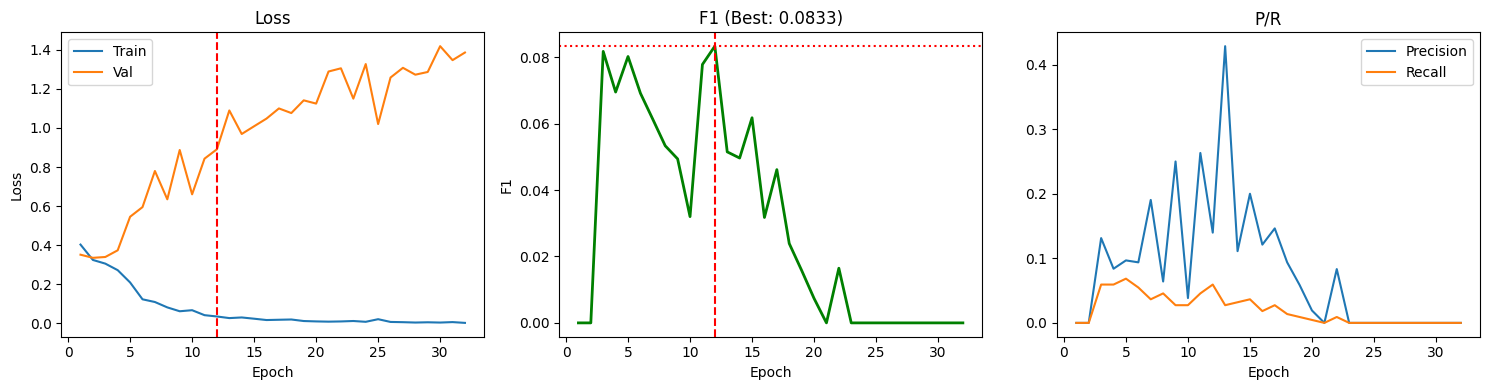

(np.float64(0.08333332914345025),
 12,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32],
  'train_loss': [0.40291313578685123,
   0.32428108900785446,
   0.3054648858184616,
   0.27196223857916063,
   0.20905242353263828,
   0.122838407729028,
   0.10898351808363158,
   0.081456822472521,
   0.061664354379495814,
   0.06705206028547966,
   0.04163894452762583,
   0.03495137469144538,
   0.02665354674374814,
   0.029931333229898074,
   0.02351244585477414,
   0.016701696722116646,
   0.018148241862541506,
   0.019485331277084898,
   0.011645142246884966,
   0.00969776630750453,
   0.008463863774876599,
   0.009542927036957534,
   0.011758886100753645,
   0.007668486778028536,
   0.021023993279161206,
   0.006967178205337,
   0.005741972878846961,
   0.003908185435648193,
   0.005205396474240034,
   0.00384203836370

In [ ]:
# ==============================================================================
# EXPERIMENT 1: Batch Size 4, Learning Rate 1e-4
# ==============================================================================
run_experiment(batch_size=4, lr=1e-4, experiment_name="bs4_lr1e-4")

EXPERIMENT: bs8_lr1e-4
Batch Size: 8 | Learning Rate: 0.0001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-05 | Time: 0.1m | ETA: 7.9m
  Loss: 0.4978/0.3558 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.2m | ETA: 7.9m
  Loss: 0.3279/0.3347 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-05 | Time: 0.2m | ETA: 7.7m
  Loss: 0.3144/0.3273 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 8.00e-05 | Time: 0.3m | ETA: 7.5m
  Loss: 0.2904/0.3399 | P: 0.1176 | R: 0.0731 | F1: 0.0901
  ✓ Best model saved! F1: 0.0901


...

Epoch  20/100 | LR: 9.47e-05 | Time: 1.6m | ETA: 6.4m
  Loss: 0.0129/1.0107 | P: 0.1087 | R: 0.0457 | F1: 0.0643


Epoch  21/100 | LR: 9.40e-05 | Time: 1.7m | ETA: 6.3m
  Loss: 0.0123/1.1032 | P: 0.1538 | R: 0.0183 | F1: 0.0327


Epoch  22/100 | LR: 9.32e-05 | Time: 1.8m | ETA: 6.2m
  Loss: 0.0124/1.1373 | P: 0.3000 | R: 0.0137 | F1: 0.0262


Epoch  23/100 | LR: 9.23e-05 | Time: 1.8m | ETA: 6.1m
  Loss: 0.0111/1.1023 | P: 0.0667 | R: 0.0183 | F1: 0.0287


Epoch  24/100 | LR: 9.14e-05 | Time: 1.9m | ETA: 6.0m
  Loss: 0.0093/1.1963 | P: 0.1600 | R: 0.0183 | F1: 0.0328

Early stopping at epoch 24
DONE: bs8_lr1e-4 | Best F1: 0.0901 at epoch 4
Total time: 1.9 min (0.03 hours)


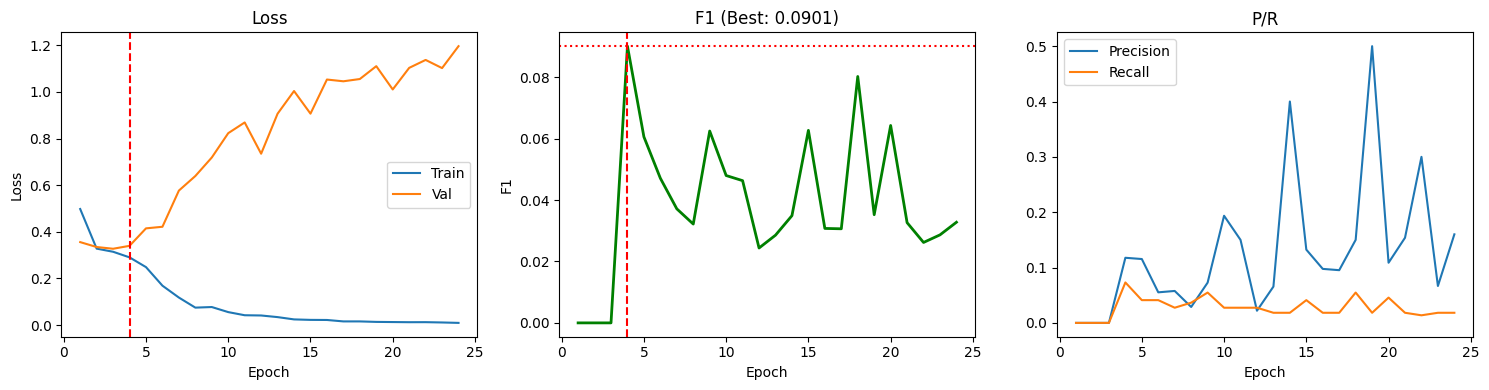

(np.float64(0.09014084033866321),
 4,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24],
  'train_loss': [0.4978073495957587,
   0.3278679669731193,
   0.3144296883708901,
   0.2903922179506885,
   0.2485535213102897,
   0.16892726605551112,
   0.11795992776751518,
   0.07477625451671581,
   0.07732705228651564,
   0.0555782083214985,
   0.04213060366196765,
   0.04110622134370109,
   0.03410059098516487,
   0.02428019225286941,
   0.022226487713245053,
   0.02180910353652305,
   0.01567992904326982,
   0.01566024414367146,
   0.013584028984445872,
   0.012910070977846367,
   0.012255341215576563,
   0.01242964426961003,
   0.01112407877937787,
   0.009338522527185786],
  'val_loss': [0.3558090403676033,
   0.3347361733516057,
   0.327300397058328,
   0.3398602431019147,
   0.4147925277551015,
   0.4216494138042132,
   0.5768368865052859,
   0.6393205026785532,
   0.718

In [ ]:
# ==============================================================================
# EXPERIMENT 2: Batch Size 8, Learning Rate 1e-4
# ==============================================================================
run_experiment(batch_size=8, lr=1e-4, experiment_name="bs8_lr1e-4")

EXPERIMENT: bs16_lr1e-4
Batch Size: 16 | Learning Rate: 0.0001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-05 | Time: 0.1m | ETA: 8.5m
  Loss: 0.5625/0.4126 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.2m | ETA: 8.4m
  Loss: 0.3503/0.3393 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-05 | Time: 0.3m | ETA: 8.2m
  Loss: 0.3208/0.3214 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 8.00e-05 | Time: 0.3m | ETA: 8.1m
  Loss: 0.3069/0.3218 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  22/100 | LR: 9.32e-05 | Time: 1.8m | ETA: 6.5m
  Loss: 0.0158/0.9460 | P: 0.0426 | R: 0.0091 | F1: 0.0150


Epoch  23/100 | LR: 9.23e-05 | Time: 1.9m | ETA: 6.4m
  Loss: 0.0125/1.0871 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  24/100 | LR: 9.14e-05 | Time: 2.0m | ETA: 6.3m
  Loss: 0.0123/1.0284 | P: 0.1333 | R: 0.0365 | F1: 0.0573


Epoch  25/100 | LR: 9.05e-05 | Time: 2.1m | ETA: 6.2m
  Loss: 0.0119/1.0896 | P: 0.1538 | R: 0.0091 | F1: 0.0172


Epoch  26/100 | LR: 8.95e-05 | Time: 2.1m | ETA: 6.1m
  Loss: 0.0128/1.0456 | P: 0.0000 | R: 0.0000 | F1: 0.0000

Early stopping at epoch 26
DONE: bs16_lr1e-4 | Best F1: 0.0909 at epoch 6
Total time: 2.1 min (0.04 hours)


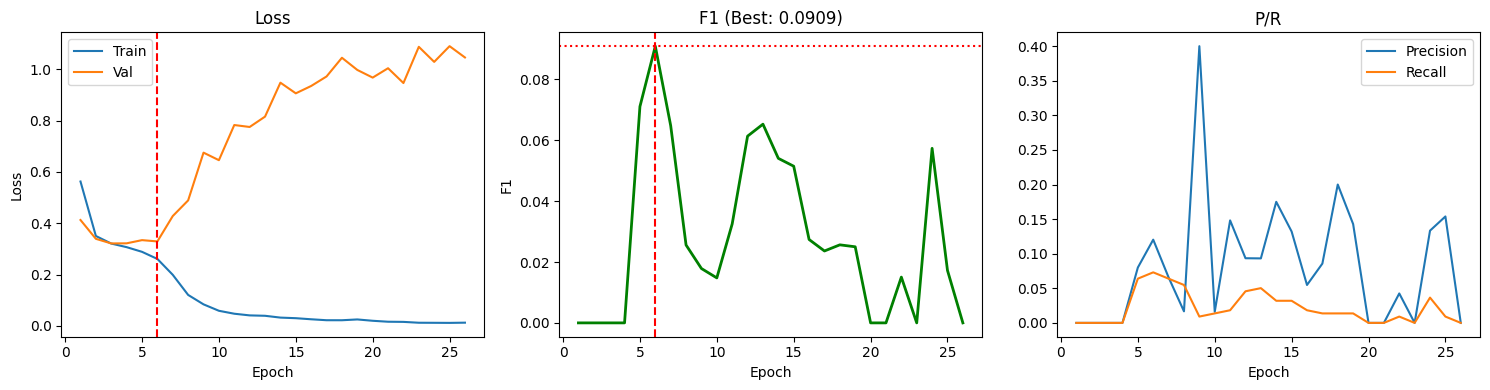

(np.float64(0.09090908620238274),
 6,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26],
  'train_loss': [0.5624995165401034,
   0.35031329095363617,
   0.32083983884917366,
   0.30689874705341125,
   0.288682801855935,
   0.26096158971389133,
   0.19913926223913828,
   0.12084746919572353,
   0.08412327534622616,
   0.059088641984595194,
   0.047633848980897,
   0.04113965616044071,
   0.03959845192730427,
   0.03252767067816523,
   0.030231050215661526,
   0.026005621378620464,
   0.022306382863057986,
   0.02223363642891248,
   0.025351068056705926,
   0.02014989343782266,
   0.016459971433505416,
   0.015843806840065453,
   0.012505960107470552,
   0.01225149799655709,
   0.011942445455739895,
   0.012775320896050997],
  'val_loss': [0.4125949740409851,
   0.3393126428127289,
   0.3213511010011037,
   0.3217844565709432,
   0.3342111309369405,
   0.329

In [ ]:
# ==============================================================================
# EXPERIMENT 3: Batch Size 16, Learning Rate 1e-4 (Default)
# ==============================================================================
run_experiment(batch_size=16, lr=1e-4, experiment_name="bs16_lr1e-4")

EXPERIMENT: bs32_lr1e-4
Batch Size: 32 | Learning Rate: 0.0001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-05 | Time: 0.1m | ETA: 8.7m
  Loss: 0.6413/0.5620 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.2m | ETA: 8.4m
  Loss: 0.4630/0.3938 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-05 | Time: 0.3m | ETA: 8.4m
  Loss: 0.3403/0.3634 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 8.00e-05 | Time: 0.3m | ETA: 8.4m
  Loss: 0.3303/0.3493 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  24/100 | LR: 9.14e-05 | Time: 2.1m | ETA: 6.6m
  Loss: 0.0192/1.0117 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  25/100 | LR: 9.05e-05 | Time: 2.2m | ETA: 6.5m
  Loss: 0.0167/1.0096 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  26/100 | LR: 8.95e-05 | Time: 2.3m | ETA: 6.4m
  Loss: 0.0145/1.0062 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  27/100 | LR: 8.84e-05 | Time: 2.3m | ETA: 6.3m
  Loss: 0.0137/1.0544 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  28/100 | LR: 8.73e-05 | Time: 2.4m | ETA: 6.3m
  Loss: 0.0139/1.0978 | P: 0.0000 | R: 0.0000 | F1: 0.0000

Early stopping at epoch 28
DONE: bs32_lr1e-4 | Best F1: 0.0662 at epoch 8
Total time: 2.4 min (0.04 hours)


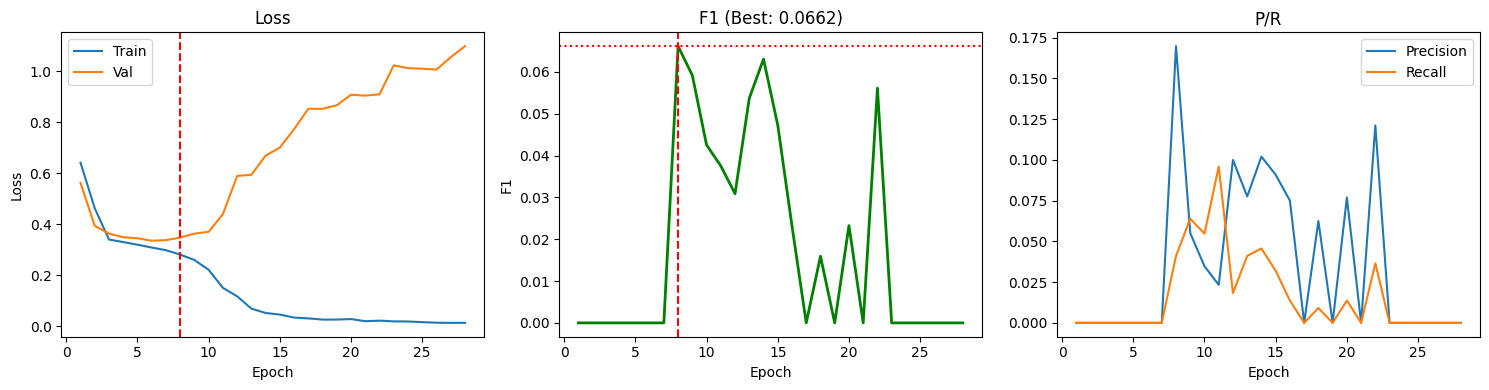

(np.float64(0.06617646744566406),
 8,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28],
  'train_loss': [0.6413486666149564,
   0.4629518720838759,
   0.34025360147158307,
   0.3303135832150777,
   0.3199892176522149,
   0.3089677194754283,
   0.2984624703725179,
   0.2812086327208413,
   0.2600744581884808,
   0.2215767651796341,
   0.15104529592725965,
   0.1178704591261016,
   0.06959602360924085,
   0.052487100578016706,
   0.0463228900399473,
   0.0345970071438286,
   0.03137234184477064,
   0.026650468301441934,
   0.026766939502623346,
   0.028714460010329883,
   0.020377875512672797,
   0.022468196642067697,
   0.019672876844803493,
   0.019249807215399213,
   0.01666088919672701,
   0.014482941892411973,
   0.013735095452931192,
   0.013883499325149588],
  'val_loss': [0.5619558691978455,
   0.393801286816597,
   0.36342404782772064

In [ ]:
# ==============================================================================
# EXPERIMENT 4: Batch Size 32, Learning Rate 1e-4
# ==============================================================================
run_experiment(batch_size=32, lr=1e-4, experiment_name="bs32_lr1e-4")

EXPERIMENT: bs8_lr1e-3
Batch Size: 8 | Learning Rate: 0.001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-04 | Time: 0.1m | ETA: 7.8m
  Loss: 0.3534/0.3461 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-04 | Time: 0.2m | ETA: 8.0m
  Loss: 0.3207/0.3324 | P: 0.1103 | R: 0.0731 | F1: 0.0879
  ✓ Best model saved! F1: 0.0879


Epoch   3/100 | LR: 6.00e-04 | Time: 0.2m | ETA: 7.8m
  Loss: 0.3153/0.3282 | P: 0.1746 | R: 0.0502 | F1: 0.0780


Epoch   4/100 | LR: 8.00e-04 | Time: 0.3m | ETA: 7.7m
  Loss: 0.3062/0.3299 | P: 0.1293 | R: 0.0685 | F1: 0.0896
  ✓ Best model saved! F1: 0.0896


...

Epoch  21/100 | LR: 9.40e-04 | Time: 1.7m | ETA: 6.3m
  Loss: 0.0908/0.6222 | P: 0.0692 | R: 0.0502 | F1: 0.0582


Epoch  22/100 | LR: 9.32e-04 | Time: 1.8m | ETA: 6.2m
  Loss: 0.0870/0.6280 | P: 0.0235 | R: 0.1142 | F1: 0.0390


Epoch  23/100 | LR: 9.23e-04 | Time: 1.8m | ETA: 6.2m
  Loss: 0.0745/0.8060 | P: 0.0201 | R: 0.0365 | F1: 0.0259


Epoch  24/100 | LR: 9.14e-04 | Time: 1.9m | ETA: 6.1m
  Loss: 0.0710/0.9642 | P: 0.0349 | R: 0.0365 | F1: 0.0357


Epoch  25/100 | LR: 9.05e-04 | Time: 2.0m | ETA: 6.0m
  Loss: 0.0532/0.8635 | P: 0.0181 | R: 0.0320 | F1: 0.0231

Early stopping at epoch 25
DONE: bs8_lr1e-3 | Best F1: 0.0918 at epoch 5
Total time: 2.0 min (0.03 hours)


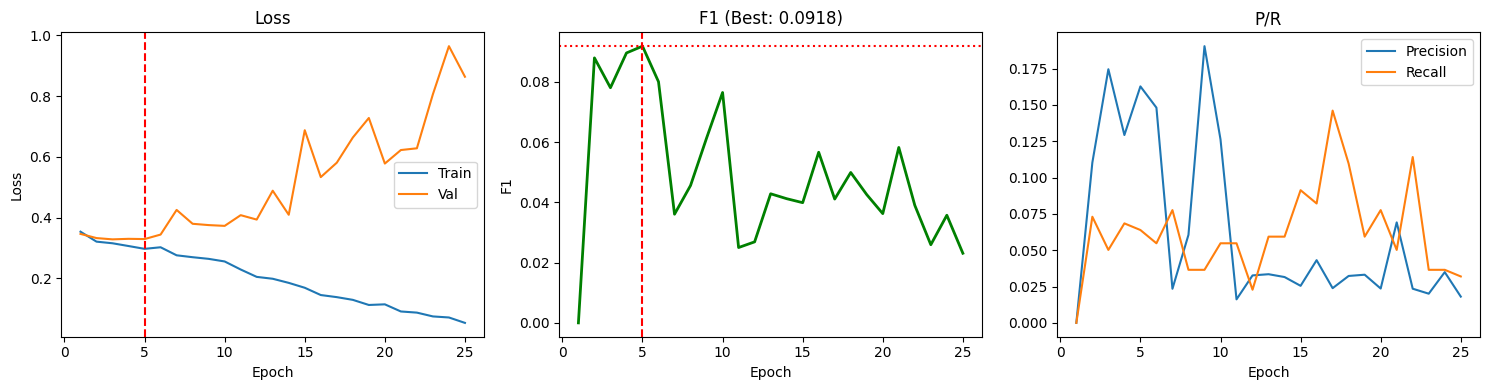

(np.float64(0.09180327463327079),
 5,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25],
  'train_loss': [0.35341793422897655,
   0.32065746933221817,
   0.31529002802239525,
   0.30621174060636097,
   0.29696063780122334,
   0.3021534677180979,
   0.27570419675774044,
   0.2694309850533803,
   0.2640158991432852,
   0.2554200558612744,
   0.22892050258815289,
   0.20466795480913585,
   0.19847387075424194,
   0.1849472818689214,
   0.16882676558776033,
   0.1448755262212621,
   0.1379698763291041,
   0.12904107725868622,
   0.11218838057377273,
   0.11426475245712532,
   0.09076588999273048,
   0.08700752423869239,
   0.07447969727218151,
   0.07100459281355143,
   0.0532049180732833],
  'val_loss': [0.34614723920822144,
   0.33240294208129245,
   0.32819173236687976,
   0.32993454734484357,
   0.32913920780022937,
   0.3439629649122556,
   0.42509763936201733,


In [ ]:
# ==============================================================================
# EXPERIMENT 5: Batch Size 8, Learning Rate 1e-3 (Higher LR)
# ==============================================================================
run_experiment(batch_size=8, lr=1e-3, experiment_name="bs8_lr1e-3")

EXPERIMENT: bs8_lr5e-4
Batch Size: 8 | Learning Rate: 0.0005
Model parameters: 11,065,618


Epoch   1/100 | LR: 1.00e-04 | Time: 0.1m | ETA: 8.4m
  Loss: 0.3795/0.3373 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 2.00e-04 | Time: 0.2m | ETA: 8.0m
  Loss: 0.3179/0.3589 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 3.00e-04 | Time: 0.2m | ETA: 7.8m
  Loss: 0.3071/0.3309 | P: 0.0949 | R: 0.0594 | F1: 0.0730
  ✓ Best model saved! F1: 0.0730


Epoch   4/100 | LR: 4.00e-04 | Time: 0.3m | ETA: 7.8m
  Loss: 0.2896/0.3409 | P: 0.1463 | R: 0.0548 | F1: 0.0797
  ✓ Best model saved! F1: 0.0797


...

Epoch  21/100 | LR: 4.70e-04 | Time: 1.7m | ETA: 6.3m
  Loss: 0.0245/0.9339 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  22/100 | LR: 4.66e-04 | Time: 1.8m | ETA: 6.2m
  Loss: 0.0205/1.0626 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  23/100 | LR: 4.62e-04 | Time: 1.8m | ETA: 6.2m
  Loss: 0.0183/0.9595 | P: 0.0284 | R: 0.0183 | F1: 0.0222


Epoch  24/100 | LR: 4.57e-04 | Time: 1.9m | ETA: 6.1m
  Loss: 0.0108/1.1216 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  25/100 | LR: 4.52e-04 | Time: 2.0m | ETA: 6.0m
  Loss: 0.0172/0.9833 | P: 0.0088 | R: 0.0183 | F1: 0.0119

Early stopping at epoch 25
DONE: bs8_lr5e-4 | Best F1: 0.0888 at epoch 5
Total time: 2.0 min (0.03 hours)


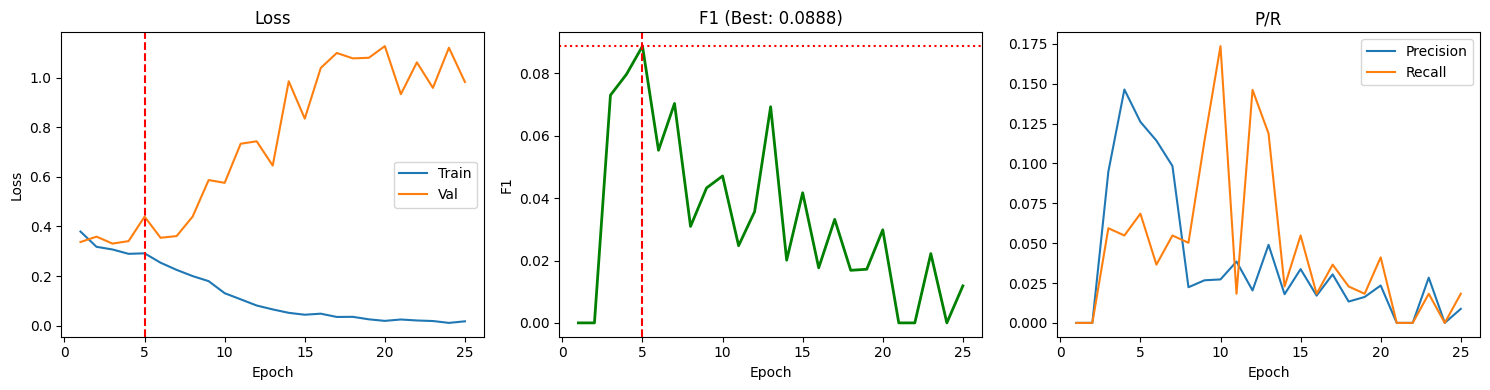

(np.float64(0.08875739188211221),
 5,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25],
  'train_loss': [0.3794845665494601,
   0.31789881736040115,
   0.30712250247597694,
   0.2895787333448728,
   0.2915968808035056,
   0.2536372948024008,
   0.2248367898994022,
   0.19974358048703936,
   0.17926775312258136,
   0.13070981628778908,
   0.10593789774510595,
   0.08093253926684459,
   0.06518214620235893,
   0.05137276708976262,
   0.04373463217376007,
   0.047957419521278806,
   0.034718297266711794,
   0.0352534863502822,
   0.025161786276536684,
   0.018900701879627176,
   0.02449438671788408,
   0.020522473179476544,
   0.018310119391470734,
   0.010786258647890968,
   0.017151601664308045],
  'val_loss': [0.3372756093740463,
   0.3589131683111191,
   0.33087244381507236,
   0.34090852240721387,
   0.4396367532511552,
   0.35438962280750275,
   0.36124305923

In [ ]:
# ==============================================================================
# EXPERIMENT 6: Batch Size 8, Learning Rate 5e-4
# ==============================================================================
run_experiment(batch_size=8, lr=5e-4, experiment_name="bs8_lr5e-4")

EXPERIMENT: bs8_lr5e-5
Batch Size: 8 | Learning Rate: 5e-05
Model parameters: 11,065,618


Epoch   1/100 | LR: 1.00e-05 | Time: 0.1m | ETA: 7.9m
  Loss: 0.5912/0.4576 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 2.00e-05 | Time: 0.2m | ETA: 7.8m
  Loss: 0.3546/0.3491 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 3.00e-05 | Time: 0.2m | ETA: 7.8m
  Loss: 0.3193/0.3338 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 4.00e-05 | Time: 0.3m | ETA: 7.6m
  Loss: 0.3024/0.3363 | P: 0.1290 | R: 0.0183 | F1: 0.0320
  ✓ Best model saved! F1: 0.0320


...

Epoch  21/100 | LR: 4.70e-05 | Time: 1.7m | ETA: 6.3m
  Loss: 0.0217/0.9857 | P: 0.1333 | R: 0.0183 | F1: 0.0321


Epoch  22/100 | LR: 4.66e-05 | Time: 1.8m | ETA: 6.2m
  Loss: 0.0160/1.0506 | P: 0.0741 | R: 0.0183 | F1: 0.0293


Epoch  23/100 | LR: 4.62e-05 | Time: 1.8m | ETA: 6.1m
  Loss: 0.0147/1.1127 | P: 0.1111 | R: 0.0183 | F1: 0.0314


Epoch  24/100 | LR: 4.57e-05 | Time: 1.9m | ETA: 6.0m
  Loss: 0.0142/1.0463 | P: 0.1290 | R: 0.0183 | F1: 0.0320


Epoch  25/100 | LR: 4.52e-05 | Time: 2.0m | ETA: 6.0m
  Loss: 0.0200/1.1254 | P: 0.1818 | R: 0.0183 | F1: 0.0332

Early stopping at epoch 25
DONE: bs8_lr5e-5 | Best F1: 0.0785 at epoch 5
Total time: 2.0 min (0.03 hours)


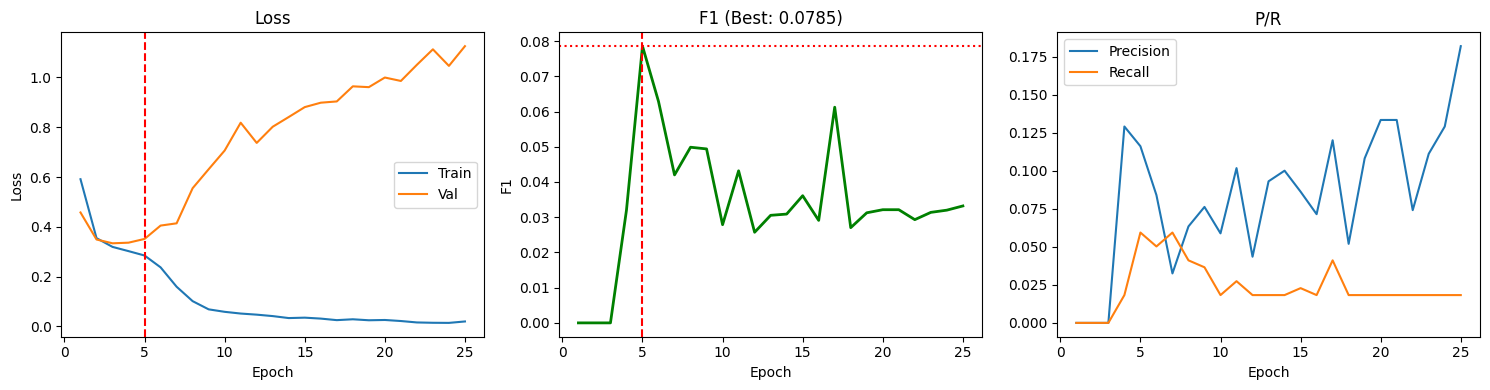

(np.float64(0.07854984446034655),
 5,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25],
  'train_loss': [0.5912031051185396,
   0.3545643819702996,
   0.31934908115201527,
   0.3023553043603897,
   0.28477586184938747,
   0.23724025736252466,
   0.1594047722303205,
   0.10154333451969756,
   0.06861297599971294,
   0.05864707577145762,
   0.05174559773877263,
   0.04728605812932882,
   0.04152199918300741,
   0.033567226440128356,
   0.03522281381689633,
   0.03145975429409494,
   0.0252686580707733,
   0.02872337494045496,
   0.024766328705785174,
   0.02590247057378292,
   0.02172851566380511,
   0.01600602295689492,
   0.014662214658326574,
   0.014240867238388293,
   0.019959729798655543],
  'val_loss': [0.4576369822025299,
   0.34907043476899463,
   0.3338187038898468,
   0.33633265147606534,
   0.3514084642132123,
   0.4049796164035797,
   0.41402142494916

In [ ]:
# ==============================================================================
# EXPERIMENT 7: Batch Size 8, Learning Rate 5e-5 (Lower LR)
# ==============================================================================
run_experiment(batch_size=8, lr=5e-5, experiment_name="bs8_lr5e-5")

EXPERIMENT: bs8_lr1e-5
Batch Size: 8 | Learning Rate: 1e-05
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-06 | Time: 0.1m | ETA: 7.8m
  Loss: 0.7108/0.6714 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-06 | Time: 0.2m | ETA: 7.8m
  Loss: 0.5921/0.5235 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-06 | Time: 0.2m | ETA: 7.8m
  Loss: 0.4306/0.3749 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 8.00e-06 | Time: 0.3m | ETA: 7.6m
  Loss: 0.3398/0.3478 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  38/100 | LR: 7.45e-06 | Time: 3.1m | ETA: 5.0m
  Loss: 0.0255/0.8207 | P: 0.1091 | R: 0.0274 | F1: 0.0438


Epoch  39/100 | LR: 7.31e-06 | Time: 3.1m | ETA: 4.9m
  Loss: 0.0217/0.8428 | P: 0.1000 | R: 0.0183 | F1: 0.0309


Epoch  40/100 | LR: 7.16e-06 | Time: 3.2m | ETA: 4.8m
  Loss: 0.0215/0.8506 | P: 0.1111 | R: 0.0228 | F1: 0.0379


Epoch  41/100 | LR: 7.01e-06 | Time: 3.3m | ETA: 4.7m
  Loss: 0.0251/0.8191 | P: 0.0779 | R: 0.0274 | F1: 0.0405


Epoch  42/100 | LR: 6.86e-06 | Time: 3.4m | ETA: 4.7m
  Loss: 0.0218/0.8839 | P: 0.1667 | R: 0.0183 | F1: 0.0329

Early stopping at epoch 42
DONE: bs8_lr1e-5 | Best F1: 0.0688 at epoch 22
Total time: 3.4 min (0.06 hours)


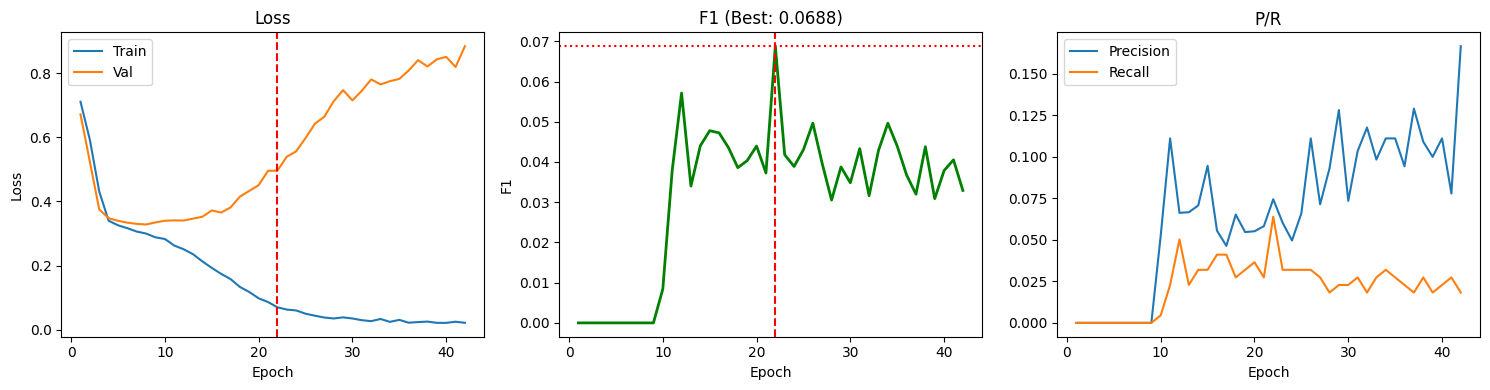

(np.float64(0.06879606382169563),
 22,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42],
  'train_loss': [0.7107900778452555,
   0.5920701523621877,
   0.43063659055365455,
   0.33984406996104455,
   0.32567323537336457,
   0.3166845887899399,
   0.3061463650729921,
   0.29983961085478467,
   0.2880787224405342,
   0.2829491053190496,
   0.2625304340488381,
   0.2508976368440522,
   0.2355433656937546,
   0.21311390275756517,
   0.1929448116570711,
   0.17423849573565853,
   0.15809483639895916,
   0.13351017898983425,
   0.11775030992511246,
   0.09808957162830564,
   0.08646447708209355,
   0.07014026058216889,
   0.06299691525701848,
   0.060263949963781566,
   0.05016086379893952,
   0.04381344115568532,
   0.03826425374589033,
   0.03525293

In [ ]:
# ==============================================================================
# EXPERIMENT 8: Batch Size 8, Learning Rate 1e-5 (Very Low LR)
# ==============================================================================
run_experiment(batch_size=8, lr=1e-5, experiment_name="bs8_lr1e-5")

EXPERIMENT: bs16_lr5e-4
Batch Size: 16 | Learning Rate: 0.0005
Model parameters: 11,065,618


Epoch   1/100 | LR: 1.00e-04 | Time: 0.1m | ETA: 8.3m
  Loss: 0.3946/0.3476 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 2.00e-04 | Time: 0.2m | ETA: 8.1m
  Loss: 0.3259/0.3290 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 3.00e-04 | Time: 0.2m | ETA: 8.0m
  Loss: 0.3104/0.3158 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 4.00e-04 | Time: 0.3m | ETA: 7.9m
  Loss: 0.2954/0.3525 | P: 0.1161 | R: 0.0594 | F1: 0.0785
  ✓ Best model saved! F1: 0.0785


...

Epoch  28/100 | LR: 4.37e-04 | Time: 2.3m | ETA: 5.9m
  Loss: 0.0103/0.9631 | P: 0.0506 | R: 0.0183 | F1: 0.0268


Epoch  29/100 | LR: 4.31e-04 | Time: 2.4m | ETA: 5.8m
  Loss: 0.0102/1.0359 | P: 0.1556 | R: 0.0320 | F1: 0.0530


Epoch  30/100 | LR: 4.25e-04 | Time: 2.5m | ETA: 5.7m
  Loss: 0.0069/1.1139 | P: 0.0952 | R: 0.0183 | F1: 0.0307


Epoch  31/100 | LR: 4.19e-04 | Time: 2.5m | ETA: 5.6m
  Loss: 0.0090/1.0207 | P: 0.0816 | R: 0.0183 | F1: 0.0299


Epoch  32/100 | LR: 4.13e-04 | Time: 2.6m | ETA: 5.6m
  Loss: 0.0062/1.0413 | P: 0.1333 | R: 0.0183 | F1: 0.0321

Early stopping at epoch 32
DONE: bs16_lr5e-4 | Best F1: 0.0842 at epoch 12
Total time: 2.6 min (0.04 hours)


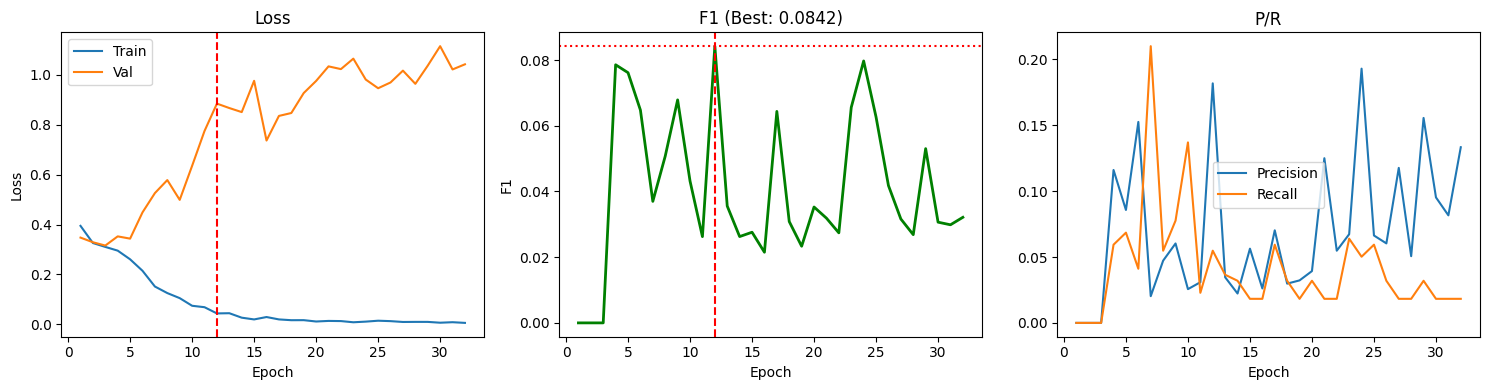

(np.float64(0.08421052275087734),
 12,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32],
  'train_loss': [0.3946469732456737,
   0.3259420014090008,
   0.3103569696346919,
   0.2954379957583215,
   0.2607475080423885,
   0.2147928869558705,
   0.15180274885561731,
   0.12557939771148893,
   0.10531732833219899,
   0.07474357013901074,
   0.06902594305574894,
   0.04415761255141762,
   0.04497179150995281,
   0.027106447093602683,
   0.020091835719843704,
   0.0296838717121217,
   0.020145121754871473,
   0.017001593640695017,
   0.017159007567291457,
   0.011786044083742632,
   0.01411776306728522,
   0.013472085094286336,
   0.00870934825959719,
   0.011295130916146768,
   0.01494596598462926,
   0.013250572619856231,
   0.009910350122178594,
   0.01025802812849482,
   0.010225159387725094,
   0.00694929614352683

In [ ]:
# ==============================================================================
# EXPERIMENT 9: Batch Size 16, Learning Rate 5e-4
# ==============================================================================
run_experiment(batch_size=16, lr=5e-4, experiment_name="bs16_lr5e-4")

EXPERIMENT: bs16_lr1e-3
Batch Size: 16 | Learning Rate: 0.001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-04 | Time: 0.1m | ETA: 8.4m
  Loss: 0.3734/0.3367 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-04 | Time: 0.2m | ETA: 8.1m
  Loss: 0.3204/0.3175 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-04 | Time: 0.2m | ETA: 8.1m
  Loss: 0.3127/0.3319 | P: 0.1333 | R: 0.0548 | F1: 0.0777
  ✓ Best model saved! F1: 0.0777


Epoch   4/100 | LR: 8.00e-04 | Time: 0.3m | ETA: 8.0m
  Loss: 0.3051/0.3362 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  21/100 | LR: 9.40e-04 | Time: 1.7m | ETA: 6.5m
  Loss: 0.0451/0.9133 | P: 0.0460 | R: 0.1233 | F1: 0.0670


Epoch  22/100 | LR: 9.32e-04 | Time: 1.8m | ETA: 6.4m
  Loss: 0.0455/1.0110 | P: 0.0516 | R: 0.1050 | F1: 0.0692


Epoch  23/100 | LR: 9.23e-04 | Time: 1.9m | ETA: 6.3m
  Loss: 0.0375/0.8661 | P: 0.0496 | R: 0.0868 | F1: 0.0631


Epoch  24/100 | LR: 9.14e-04 | Time: 2.0m | ETA: 6.2m
  Loss: 0.0349/0.8011 | P: 0.0870 | R: 0.0365 | F1: 0.0514


Epoch  25/100 | LR: 9.05e-04 | Time: 2.0m | ETA: 6.1m
  Loss: 0.0465/0.8559 | P: 0.0377 | R: 0.0548 | F1: 0.0447

Early stopping at epoch 25
DONE: bs16_lr1e-3 | Best F1: 0.0874 at epoch 5
Total time: 2.0 min (0.03 hours)


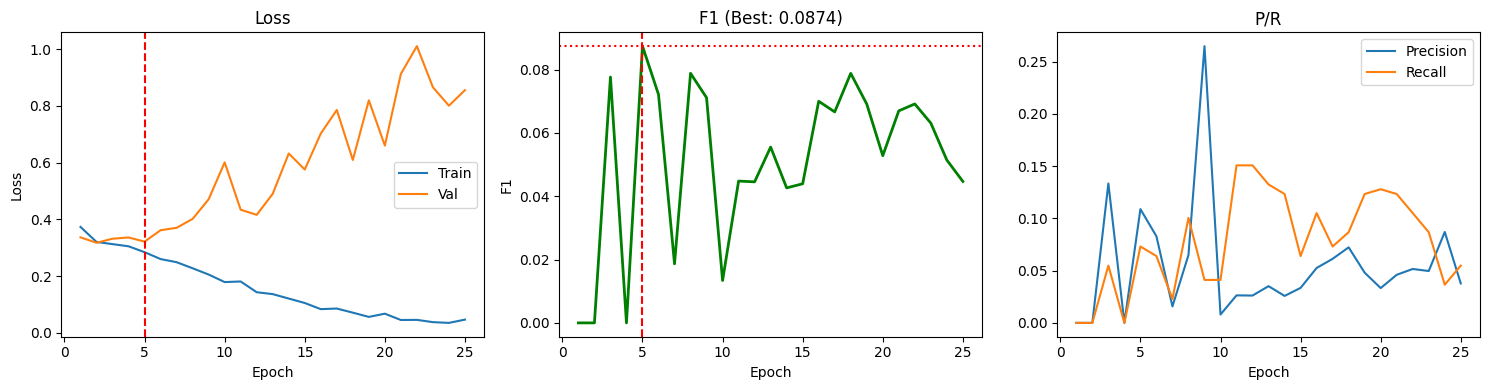

(np.float64(0.08743168917779),
 5,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25],
  'train_loss': [0.3734346032142639,
   0.32039156887266373,
   0.3127184907595317,
   0.30509427852100796,
   0.28430215683248306,
   0.26004834721485776,
   0.24894047694073784,
   0.2275828868150711,
   0.2054162070982986,
   0.178875293996599,
   0.18096838229232365,
   0.14305075092448127,
   0.13640148813525835,
   0.12072667934828335,
   0.10507918563154009,
   0.08340674338655339,
   0.08548222337332037,
   0.0709956952681144,
   0.056000530098875366,
   0.06738601345568895,
   0.04511247595979108,
   0.045549899236195616,
   0.03753480998178323,
   0.034905870341592364,
   0.04646588034100003],
  'val_loss': [0.3367096682389577,
   0.3175020068883896,
   0.33188462257385254,
   0.33621328075726825,
   0.3216212789217631,
   0.3617507169644038,
   0.37032463153203327,
  

In [ ]:
# ==============================================================================
# EXPERIMENT 10: Batch Size 16, Learning Rate 1e-3
# ==============================================================================
run_experiment(batch_size=16, lr=1e-3, experiment_name="bs16_lr1e-3")

EXPERIMENT: bs4_lr5e-4
Batch Size: 4 | Learning Rate: 0.0005
Model parameters: 11,065,618


Epoch   1/100 | LR: 1.00e-04 | Time: 0.1m | ETA: 10.6m
  Loss: 0.3514/0.3392 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 2.00e-04 | Time: 0.2m | ETA: 10.8m
  Loss: 0.3236/0.3588 | P: 0.2500 | R: 0.0046 | F1: 0.0090
  ✓ Best model saved! F1: 0.0090


Epoch   3/100 | LR: 3.00e-04 | Time: 0.3m | ETA: 10.4m
  Loss: 0.3183/0.3408 | P: 0.3333 | R: 0.0091 | F1: 0.0178
  ✓ Best model saved! F1: 0.0178


Epoch   4/100 | LR: 4.00e-04 | Time: 0.4m | ETA: 10.4m
  Loss: 0.3162/0.4105 | P: 1.0000 | R: 0.0046 | F1: 0.0091


...

Epoch  24/100 | LR: 4.57e-04 | Time: 2.4m | ETA: 7.7m
  Loss: 0.0275/1.0732 | P: 0.0114 | R: 0.0091 | F1: 0.0101


Epoch  25/100 | LR: 4.52e-04 | Time: 2.5m | ETA: 7.6m
  Loss: 0.0258/1.1155 | P: 0.0548 | R: 0.0183 | F1: 0.0274


Epoch  26/100 | LR: 4.47e-04 | Time: 2.6m | ETA: 7.5m
  Loss: 0.0183/0.9067 | P: 0.0533 | R: 0.0594 | F1: 0.0562


Epoch  27/100 | LR: 4.42e-04 | Time: 2.7m | ETA: 7.3m
  Loss: 0.0274/0.9855 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  28/100 | LR: 4.37e-04 | Time: 2.8m | ETA: 7.3m
  Loss: 0.0169/1.0216 | P: 0.0270 | R: 0.0183 | F1: 0.0218

Early stopping at epoch 28
DONE: bs4_lr5e-4 | Best F1: 0.0855 at epoch 8
Total time: 2.8 min (0.05 hours)


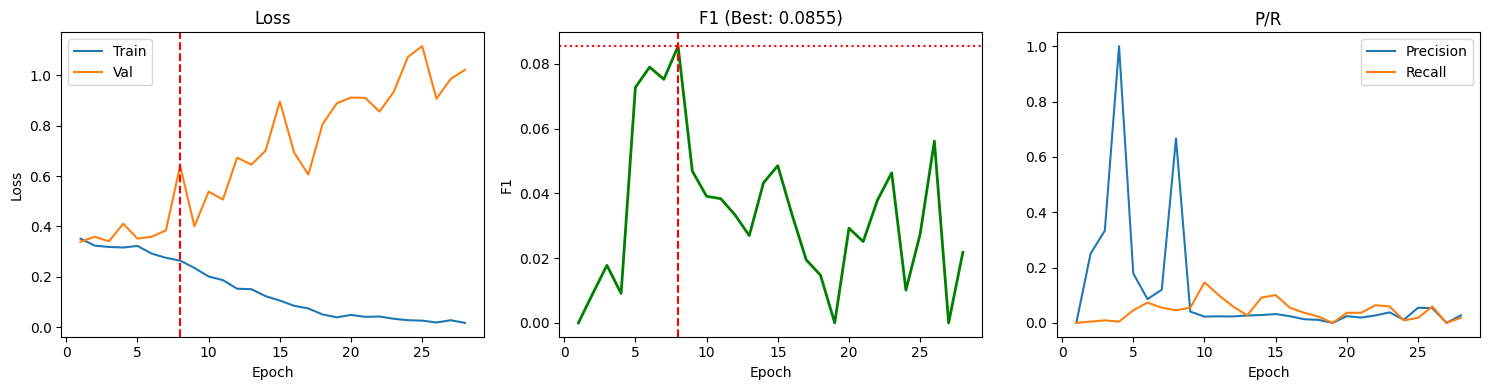

(np.float64(0.08547008426291183),
 8,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28],
  'train_loss': [0.35140776903265053,
   0.32361885429256493,
   0.3183435322716832,
   0.3162071919068694,
   0.322329037098421,
   0.2918254438166817,
   0.2752859019156959,
   0.2641267865482304,
   0.23503261147480872,
   0.20093232362220684,
   0.18660557668449151,
   0.15244412039303118,
   0.15068027617720267,
   0.12293684999975893,
   0.10558675252832472,
   0.08473930675407043,
   0.07418902054066873,
   0.05032221751429865,
   0.03898715986805554,
   0.048518757358477965,
   0.04073401518528246,
   0.04222477710573003,
   0.033149669850697845,
   0.027476788802030368,
   0.025794664258784097,
   0.018329202468117325,
   0.027373081900198788,
   0.01686370485266606],
  'val_loss': [0.33920611813664436,
   0.35882879545291263,
   0.34081897325813

In [ ]:
# ==============================================================================
# EXPERIMENT 11: Batch Size 4, Learning Rate 5e-4
# ==============================================================================
run_experiment(batch_size=4, lr=5e-4, experiment_name="bs4_lr5e-4")

EXPERIMENT: bs32_lr5e-4
Batch Size: 32 | Learning Rate: 0.0005
Model parameters: 11,065,618


Epoch   1/100 | LR: 1.00e-04 | Time: 0.1m | ETA: 8.7m
  Loss: 0.4789/0.3560 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 2.00e-04 | Time: 0.2m | ETA: 8.6m
  Loss: 0.3403/0.3521 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 3.00e-04 | Time: 0.3m | ETA: 8.4m
  Loss: 0.3219/0.3387 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 4.00e-04 | Time: 0.3m | ETA: 8.3m
  Loss: 0.3103/0.3485 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  23/100 | LR: 4.62e-04 | Time: 2.0m | ETA: 6.7m
  Loss: 0.0156/1.0850 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  24/100 | LR: 4.57e-04 | Time: 2.1m | ETA: 6.6m
  Loss: 0.0145/1.1253 | P: 0.0645 | R: 0.0183 | F1: 0.0285


Epoch  25/100 | LR: 4.52e-04 | Time: 2.2m | ETA: 6.5m
  Loss: 0.0142/1.0958 | P: 0.0797 | R: 0.0502 | F1: 0.0616


Epoch  26/100 | LR: 4.47e-04 | Time: 2.2m | ETA: 6.4m
  Loss: 0.0112/1.1036 | P: 0.0377 | R: 0.0183 | F1: 0.0246


Epoch  27/100 | LR: 4.42e-04 | Time: 2.3m | ETA: 6.3m
  Loss: 0.0107/1.1463 | P: 0.0385 | R: 0.0502 | F1: 0.0436

Early stopping at epoch 27
DONE: bs32_lr5e-4 | Best F1: 0.0840 at epoch 7
Total time: 2.3 min (0.04 hours)


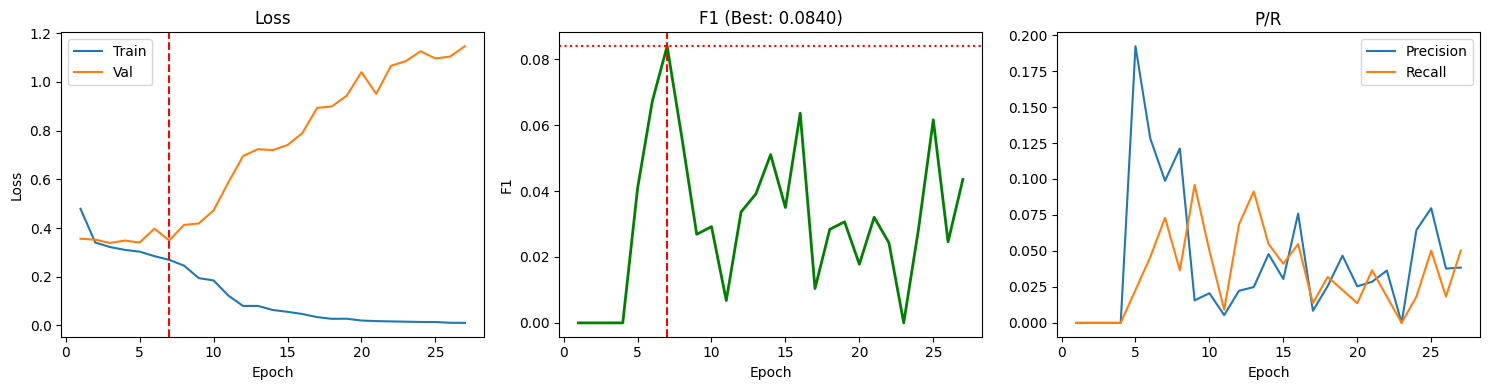

(np.float64(0.08398949641983756),
 7,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27],
  'train_loss': [0.4788544211122725,
   0.34031106366051567,
   0.3218985100587209,
   0.31026144491301644,
   0.3029855125480228,
   0.28452934159172905,
   0.2693154000573688,
   0.24574266374111176,
   0.19429098731941646,
   0.1849427041080263,
   0.12252317286199993,
   0.08008152743180592,
   0.0803299347559611,
   0.06368874344560835,
   0.0560705711444219,
   0.04711580566234059,
   0.0344648826867342,
   0.027283936532007322,
   0.027829598842395678,
   0.02033861115988758,
   0.018021393463843398,
   0.016688903069330588,
   0.015641590787304774,
   0.014499410159058042,
   0.01419526245445013,
   0.011211664829817083,
   0.010673352724148167],
  'val_loss': [0.35597094893455505,
   0.35211488604545593,
   0.33869998157024384,
   0.3484978973865509,
  

In [ ]:
# ==============================================================================
# EXPERIMENT 12: Batch Size 32, Learning Rate 5e-4
# ==============================================================================
run_experiment(batch_size=32, lr=5e-4, experiment_name="bs32_lr5e-4")

EXPERIMENT: deeper_bs8_lr5e-5
Batch Size: 8 | Learning Rate: 5e-05
Model parameters: 30,182,037


Epoch   1/100 | LR: 1.00e-05 | Time: 0.1m | ETA: 14.7m
  Loss: 0.5008/0.4567 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 2.00e-05 | Time: 0.3m | ETA: 14.5m
  Loss: 0.4277/0.4292 | P: 0.0833 | R: 0.0046 | F1: 0.0087
  ✓ Best model saved! F1: 0.0087


Epoch   3/100 | LR: 3.00e-05 | Time: 0.5m | ETA: 14.8m
  Loss: 0.3935/0.4293 | P: 0.1951 | R: 0.0365 | F1: 0.0615
  ✓ Best model saved! F1: 0.0615


Epoch   4/100 | LR: 4.00e-05 | Time: 0.6m | ETA: 14.7m
  Loss: 0.3611/0.4356 | P: 0.0914 | R: 0.0731 | F1: 0.0812
  ✓ Best model saved! F1: 0.0812


...

Epoch  20/100 | LR: 4.74e-05 | Time: 2.9m | ETA: 11.8m
  Loss: 0.0271/1.6023 | P: 0.1667 | R: 0.0137 | F1: 0.0253


Epoch  21/100 | LR: 4.70e-05 | Time: 3.1m | ETA: 11.6m
  Loss: 0.0168/1.7793 | P: 0.1154 | R: 0.0137 | F1: 0.0245


Epoch  22/100 | LR: 4.66e-05 | Time: 3.2m | ETA: 11.5m
  Loss: 0.0138/1.7371 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  23/100 | LR: 4.62e-05 | Time: 3.4m | ETA: 11.3m
  Loss: 0.0127/1.7938 | P: 0.1333 | R: 0.0091 | F1: 0.0171


Epoch  24/100 | LR: 4.57e-05 | Time: 3.5m | ETA: 11.2m
  Loss: 0.0105/1.7611 | P: 0.0000 | R: 0.0000 | F1: 0.0000

Early stopping at epoch 24
DONE: deeper_bs8_lr5e-5 | Best F1: 0.0812 at epoch 4
Total time: 3.5 min (0.06 hours)


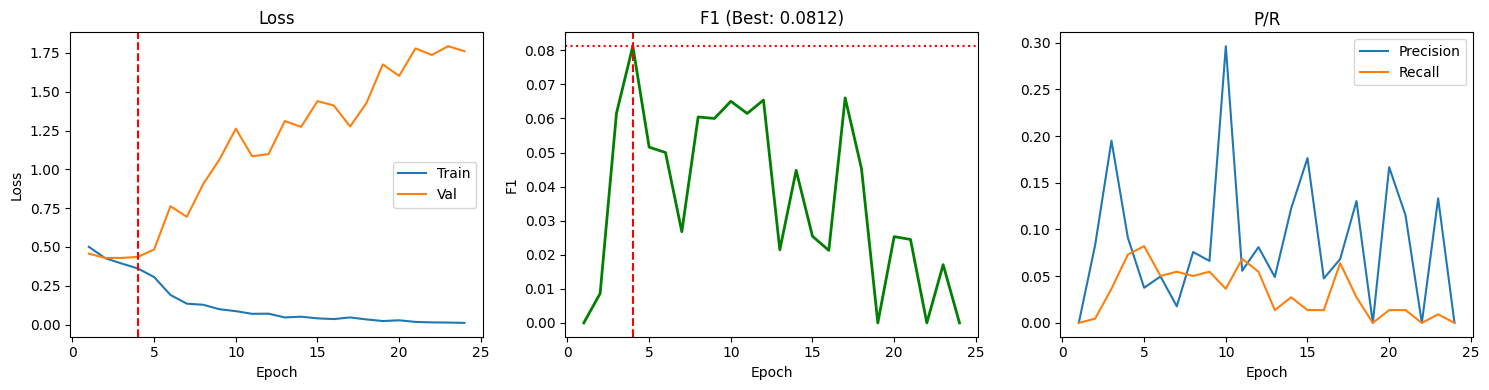

(np.float64(0.08121826916990935),
 4,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24],
  'train_loss': [0.5008113773332702,
   0.4277155043350326,
   0.393509225298961,
   0.361133460369375,
   0.30588163828684223,
   0.19048479861683315,
   0.13434185408469704,
   0.12735769230251512,
   0.09846182079571816,
   0.08615863866483171,
   0.06893786813856827,
   0.06992251979601052,
   0.04580251798809817,
   0.05043179280538526,
   0.03973959981360369,
   0.03505623024991817,
   0.04564107993307213,
   0.032842551493862025,
   0.022549121304311685,
   0.027133820888896782,
   0.016805528051918373,
   0.013797307011878325,
   0.012681858497671783,
   0.010549262524970496],
  'val_loss': [0.4567142029603322,
   0.42920006066560745,
   0.429324912528197,
   0.43564718465010327,
   0.4833476046721141,
   0.762583722670873,
   0.6940965702136358,
   0.9048108607530594,
   1.

In [ ]:
# ==============================================================================
# EXPERIMENT 13: Deeper Model (More Transformer Layers)
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=5e-5,
    experiment_name="deeper_bs8_lr5e-5",
    config_overrides={
        "embd_dim": 384,
        "n_head": 6,
        "arch": (2, 3, 6),  # More transformer layers
        "fpn_dim": 384,
        "head_dim": 384,
        "pos_weight": 15.0,
    }
)

EXPERIMENT: wider_bs8_lr1e-4
Batch Size: 8 | Learning Rate: 0.0001
Model parameters: 43,758,098


Epoch   1/100 | LR: 2.00e-05 | Time: 0.2m | ETA: 17.7m
  Loss: 0.4180/0.3761 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.4m | ETA: 17.6m
  Loss: 0.3490/0.3773 | P: 0.1068 | R: 0.0502 | F1: 0.0683
  ✓ Best model saved! F1: 0.0683


Epoch   3/100 | LR: 6.00e-05 | Time: 0.5m | ETA: 17.6m
  Loss: 0.3420/0.3999 | P: 0.1702 | R: 0.0365 | F1: 0.0602


Epoch   4/100 | LR: 8.00e-05 | Time: 0.7m | ETA: 17.4m
  Loss: 0.2932/0.4236 | P: 0.0637 | R: 0.0594 | F1: 0.0615


...

Epoch  26/100 | LR: 8.95e-05 | Time: 4.7m | ETA: 13.4m
  Loss: 0.0030/1.5678 | P: 0.1739 | R: 0.0183 | F1: 0.0331


Epoch  27/100 | LR: 8.84e-05 | Time: 4.9m | ETA: 13.2m
  Loss: 0.0050/1.7033 | P: 0.1111 | R: 0.0183 | F1: 0.0314


Epoch  28/100 | LR: 8.73e-05 | Time: 5.0m | ETA: 13.0m
  Loss: 0.0035/1.6860 | P: 0.5000 | R: 0.0320 | F1: 0.0601


Epoch  29/100 | LR: 8.62e-05 | Time: 5.2m | ETA: 12.8m
  Loss: 0.0036/1.6043 | P: 0.1250 | R: 0.0183 | F1: 0.0319


Epoch  30/100 | LR: 8.51e-05 | Time: 5.4m | ETA: 12.6m
  Loss: 0.0030/1.6041 | P: 0.2105 | R: 0.0183 | F1: 0.0336

Early stopping at epoch 30
DONE: wider_bs8_lr1e-4 | Best F1: 0.1197 at epoch 10
Total time: 5.4 min (0.09 hours)


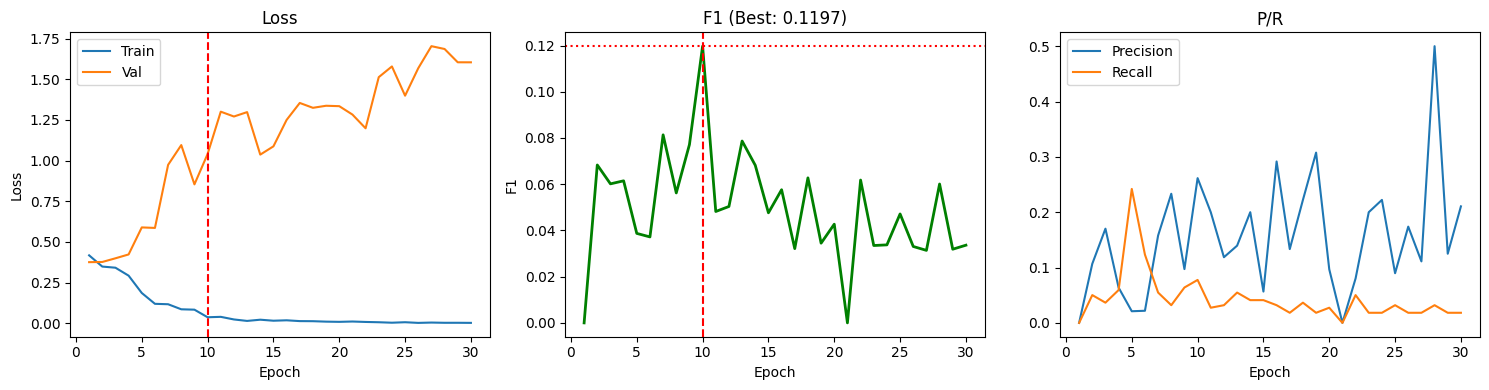

(np.float64(0.11971830632091858),
 10,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30],
  'train_loss': [0.418015752815538,
   0.3490266522599591,
   0.3420179933309555,
   0.29317450068063206,
   0.18670367718570763,
   0.12011260766949919,
   0.11755790623525779,
   0.08649840076557463,
   0.08417306232473089,
   0.03759111405815929,
   0.040097891741121806,
   0.024068600045413606,
   0.015046843625087705,
   0.022527489468403574,
   0.016301204424558416,
   0.018852102272729907,
   0.013925689718841264,
   0.013366401266668819,
   0.010626218346361484,
   0.009358933276315737,
   0.011396398146947226,
   0.008715144510562014,
   0.00691964998582585,
   0.004058453375667644,
   0.007004357560718846,
   0.0029686592541919607,
   0.004979058184188843,
   0.0035150333262410844,
   0.003595120563356128,
   0.003039240361734604]

In [ ]:
# ==============================================================================
# EXPERIMENT 14: Wider Model (Larger Hidden Dimension)
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=1e-4,
    experiment_name="wider_bs8_lr1e-4",
    config_overrides={
        "embd_dim": 512,
        "n_head": 8,
        "fpn_dim": 512,
        "head_dim": 512,
        "pos_weight": 12.0,
    }
)

EXPERIMENT: small_bs32_lr2e-4
Batch Size: 32 | Learning Rate: 0.0002
Model parameters: 1,753,996


Epoch   1/100 | LR: 4.00e-05 | Time: 0.0m | ETA: 4.7m
  Loss: 0.7186/0.6912 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 8.00e-05 | Time: 0.1m | ETA: 4.5m
  Loss: 0.6178/0.5442 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 1.20e-04 | Time: 0.1m | ETA: 4.4m
  Loss: 0.4430/0.3708 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 1.60e-04 | Time: 0.2m | ETA: 4.3m
  Loss: 0.3433/0.3819 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  36/100 | LR: 1.55e-04 | Time: 1.6m | ETA: 2.9m
  Loss: 0.0154/0.9480 | P: 0.0980 | R: 0.0228 | F1: 0.0370


Epoch  37/100 | LR: 1.52e-04 | Time: 1.7m | ETA: 2.8m
  Loss: 0.0125/0.9956 | P: 0.1944 | R: 0.0320 | F1: 0.0549


Epoch  38/100 | LR: 1.49e-04 | Time: 1.7m | ETA: 2.8m
  Loss: 0.0110/1.0225 | P: 0.1224 | R: 0.0274 | F1: 0.0448


Epoch  39/100 | LR: 1.46e-04 | Time: 1.8m | ETA: 2.8m
  Loss: 0.0092/1.0589 | P: 0.1765 | R: 0.0274 | F1: 0.0474


Epoch  40/100 | LR: 1.43e-04 | Time: 1.8m | ETA: 2.7m
  Loss: 0.0085/1.0911 | P: 0.1176 | R: 0.0274 | F1: 0.0444

Early stopping at epoch 40
DONE: small_bs32_lr2e-4 | Best F1: 0.0656 at epoch 20
Total time: 1.8 min (0.03 hours)


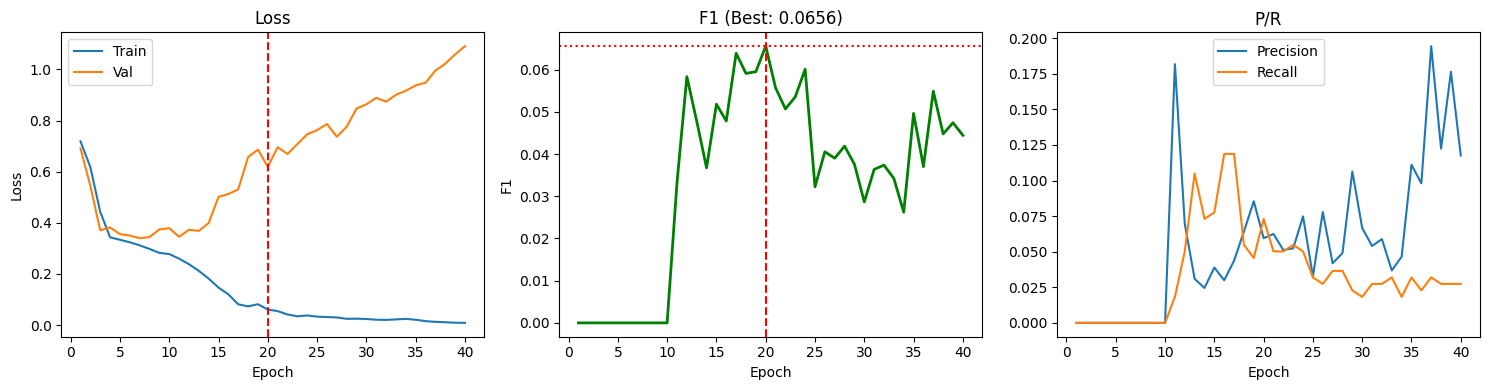

(np.float64(0.06557376554160546),
 20,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40],
  'train_loss': [0.7185839811960856,
   0.6178441908624437,
   0.44295696086353725,
   0.34333719809850055,
   0.33361276653077865,
   0.32386426793204415,
   0.3119047631820043,
   0.2977409329679277,
   0.2823883493741353,
   0.27765677041477627,
   0.25990938146909076,
   0.23806623121102652,
   0.21210870146751404,
   0.1817154818110996,
   0.14657717694838843,
   0.12009258651071125,
   0.08111870909730594,
   0.07303888640469974,
   0.08140969276428223,
   0.060756860921780266,
   0.05444810498091909,
   0.041488376135627426,
   0.03417020208305783,
   0.03743248970972167,
   0.03303100789586703,
   0.031208462806211576,
   0.029786652367975976,
   0.024402756243944

In [ ]:
# ==============================================================================
# EXPERIMENT 15: Small Model (Fast Training for Testing)
# ==============================================================================
run_experiment(
    batch_size=32,
    lr=2e-4,
    experiment_name="small_bs32_lr2e-4",
    config_overrides={
        "embd_dim": 128,
        "n_head": 4,
        "arch": (1, 1, 3),  # Smaller model
        "mha_win_size": 9,
        "fpn_dim": 128,
        "head_dim": 128,
        "attn_pdrop": 0.05,
        "proj_pdrop": 0.05,
        "path_pdrop": 0.05,
    }
)

EXPERIMENT: global_attn_bs8_lr5e-5
Batch Size: 8 | Learning Rate: 5e-05
Model parameters: 11,065,618


Epoch   1/100 | LR: 1.00e-05 | Time: 0.1m | ETA: 11.2m
  Loss: 0.5792/0.4436 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 2.00e-05 | Time: 0.2m | ETA: 11.0m
  Loss: 0.3552/0.3451 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 3.00e-05 | Time: 0.3m | ETA: 10.7m
  Loss: 0.3213/0.3324 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 4.00e-05 | Time: 0.4m | ETA: 10.5m
  Loss: 0.3034/0.3451 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  21/100 | LR: 4.70e-05 | Time: 2.2m | ETA: 8.3m
  Loss: 0.0289/0.8323 | P: 0.0650 | R: 0.0365 | F1: 0.0468


Epoch  22/100 | LR: 4.66e-05 | Time: 2.3m | ETA: 8.2m
  Loss: 0.0173/0.8807 | P: 0.1333 | R: 0.0457 | F1: 0.0680


Epoch  23/100 | LR: 4.62e-05 | Time: 2.4m | ETA: 8.1m
  Loss: 0.0192/1.0186 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  24/100 | LR: 4.57e-05 | Time: 2.5m | ETA: 8.0m
  Loss: 0.0186/0.9699 | P: 0.0690 | R: 0.0091 | F1: 0.0161


Epoch  25/100 | LR: 4.52e-05 | Time: 2.6m | ETA: 7.9m
  Loss: 0.0146/1.0707 | P: 0.2500 | R: 0.0091 | F1: 0.0176

Early stopping at epoch 25
DONE: global_attn_bs8_lr5e-5 | Best F1: 0.0851 at epoch 5
Total time: 2.6 min (0.04 hours)


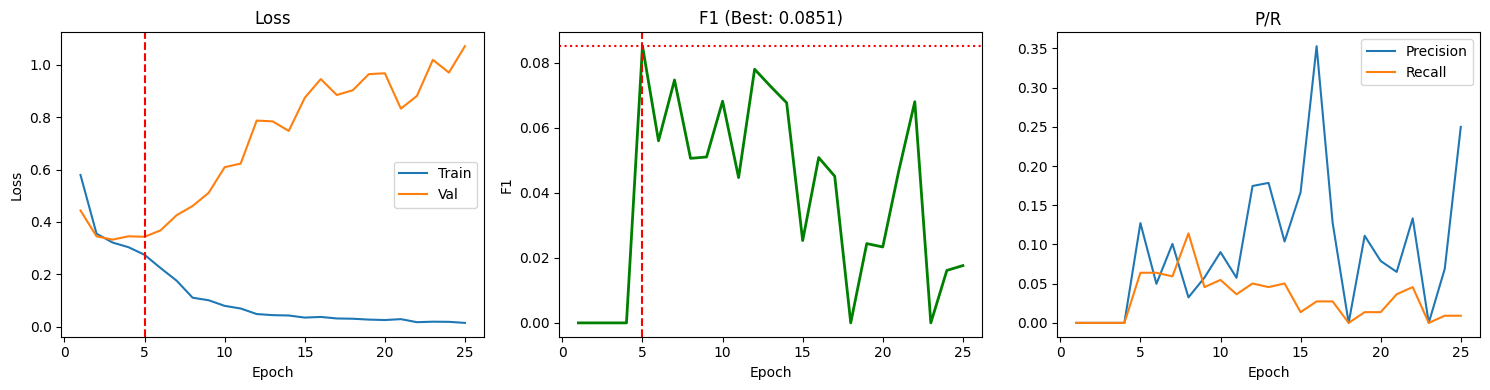

(np.float64(0.0851063785223716),
 5,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25],
  'train_loss': [0.5791620992951922,
   0.355228453874588,
   0.32129687401983476,
   0.3033711579110887,
   0.27437575947907233,
   0.22379503481917912,
   0.17575612291693687,
   0.11075327234963576,
   0.10101589700207114,
   0.07960656404288279,
   0.06949891946795914,
   0.04841011240043574,
   0.04417375886502365,
   0.04281003509337703,
   0.03486536293187075,
   0.03731730277650058,
   0.031497890608281724,
   0.030480548144421644,
   0.027149981405172083,
   0.02545581936525802,
   0.028942566676252883,
   0.017278540575514652,
   0.019198014711340267,
   0.018604400296074648,
   0.014622104684046159],
  'val_loss': [0.44361763695875805,
   0.3450837656855583,
   0.3323933308323224,
   0.3451170052091281,
   0.3432453026374181,
   0.3677774866422017,
   0.425455925365

In [ ]:
# ==============================================================================
# EXPERIMENT 16: Global Attention (No Local Windowing)
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=5e-5,
    experiment_name="global_attn_bs8_lr5e-5",
    config_overrides={
        "mha_win_size": -1,  # Global attention
        "attn_pdrop": 0.15,
        "proj_pdrop": 0.15,
    }
)

## Optimized Experiments (Based on Grid Search Analysis)

The following experiments use the best-performing configurations identified from the grid search, with additional regularization to combat overfitting.

EXPERIMENT: opt_standard_dropout03
Batch Size: 8 | Learning Rate: 0.001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-04 | Time: 0.2m | ETA: 16.8m
  Loss: 0.3568/0.3331 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-04 | Time: 0.2m | ETA: 12.2m
  Loss: 0.3264/0.3458 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-04 | Time: 0.3m | ETA: 10.7m
  Loss: 0.3150/0.3727 | P: 0.2000 | R: 0.0137 | F1: 0.0256
  ✓ Best model saved! F1: 0.0256


Epoch   4/100 | LR: 8.00e-04 | Time: 0.4m | ETA: 9.9m
  Loss: 0.3167/0.3610 | P: 0.1304 | R: 0.0548 | F1: 0.0772
  ✓ Best model saved! F1: 0.0772


...

Epoch  21/100 | LR: 9.40e-04 | Time: 1.8m | ETA: 6.7m
  Loss: 0.1371/0.4967 | P: 0.0229 | R: 0.0502 | F1: 0.0314


Epoch  22/100 | LR: 9.32e-04 | Time: 1.8m | ETA: 6.5m
  Loss: 0.1278/0.5921 | P: 0.0221 | R: 0.0685 | F1: 0.0334


Epoch  23/100 | LR: 9.23e-04 | Time: 1.9m | ETA: 6.4m
  Loss: 0.1128/0.7682 | P: 0.0129 | R: 0.0731 | F1: 0.0219


Epoch  24/100 | LR: 9.14e-04 | Time: 2.0m | ETA: 6.3m
  Loss: 0.1004/0.8556 | P: 0.0174 | R: 0.0365 | F1: 0.0235


Epoch  25/100 | LR: 9.05e-04 | Time: 2.1m | ETA: 6.2m
  Loss: 0.1121/0.7494 | P: 0.0208 | R: 0.0594 | F1: 0.0308

Early stopping at epoch 25
DONE: opt_standard_dropout03 | Best F1: 0.0886 at epoch 5
Total time: 2.1 min (0.03 hours)


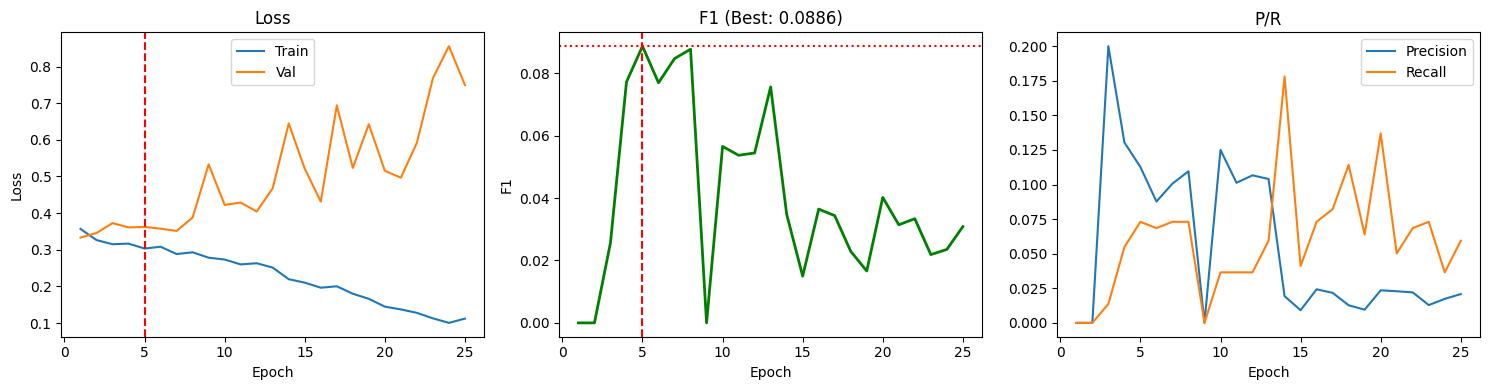

(np.float64(0.08864265450234447),
 5,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25],
  'train_loss': [0.35679320245981216,
   0.3264123784999053,
   0.31504108218683136,
   0.3167228284809325,
   0.3033417537808418,
   0.3081716067261166,
   0.2882918367783229,
   0.2930378628273805,
   0.27830047429435784,
   0.27326923774348366,
   0.259961136099365,
   0.263186046646701,
   0.2513355045682854,
   0.21955995882550874,
   0.21022899759312472,
   0.19639930646452639,
   0.20028014812204573,
   0.1799129978236225,
   0.16602871380746365,
   0.14473430843402943,
   0.13714023451838228,
   0.1278014433466726,
   0.11278057077692615,
   0.10037473837534587,
   0.11208800661067168],
  'val_loss': [0.3331417789061864,
   0.3457978541652362,
   0.37268735468387604,
   0.3609856441617012,
   0.3622395396232605,
   0.35742709288994473,
   0.351357139647007,
   0.38809

In [ ]:
# ==============================================================================
# OPTIMIZED EXPERIMENT 1: Best Standard Config with Stronger Regularization
# Based on: bs8_lr1e-3 (Best F1=0.0918)
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=1e-3,
    experiment_name="opt_standard_dropout03",
    config_overrides={
        "dropout": 0.3,
        "attn_pdrop": 0.3,
        "proj_pdrop": 0.3,
    }
)

EXPERIMENT: opt_standard_dropout05
Batch Size: 8 | Learning Rate: 0.001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-04 | Time: 0.1m | ETA: 7.9m
  Loss: 0.3727/0.4235 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-04 | Time: 0.2m | ETA: 7.8m
  Loss: 0.3288/0.4370 | P: 0.0865 | R: 0.0731 | F1: 0.0792
  ✓ Best model saved! F1: 0.0792


Epoch   3/100 | LR: 6.00e-04 | Time: 0.3m | ETA: 8.3m
  Loss: 0.3270/0.3394 | P: 0.1346 | R: 0.0320 | F1: 0.0517


Epoch   4/100 | LR: 8.00e-04 | Time: 0.3m | ETA: 8.1m
  Loss: 0.3106/0.3416 | P: 0.1143 | R: 0.0183 | F1: 0.0315


...

Epoch  24/100 | LR: 9.14e-04 | Time: 1.9m | ETA: 6.1m
  Loss: 0.1915/0.4204 | P: 0.0255 | R: 0.1005 | F1: 0.0406


Epoch  25/100 | LR: 9.05e-04 | Time: 2.0m | ETA: 6.0m
  Loss: 0.1799/0.8102 | P: 0.0232 | R: 0.3927 | F1: 0.0437


Epoch  26/100 | LR: 8.95e-04 | Time: 2.1m | ETA: 5.9m
  Loss: 0.1899/0.5107 | P: 0.0310 | R: 0.1644 | F1: 0.0522


Epoch  27/100 | LR: 8.84e-04 | Time: 2.2m | ETA: 5.9m
  Loss: 0.1651/0.5158 | P: 0.0258 | R: 0.0502 | F1: 0.0341


Epoch  28/100 | LR: 8.73e-04 | Time: 2.2m | ETA: 5.8m
  Loss: 0.1466/0.5589 | P: 0.0253 | R: 0.1826 | F1: 0.0445

Early stopping at epoch 28
DONE: opt_standard_dropout05 | Best F1: 0.0936 at epoch 8
Total time: 2.2 min (0.04 hours)


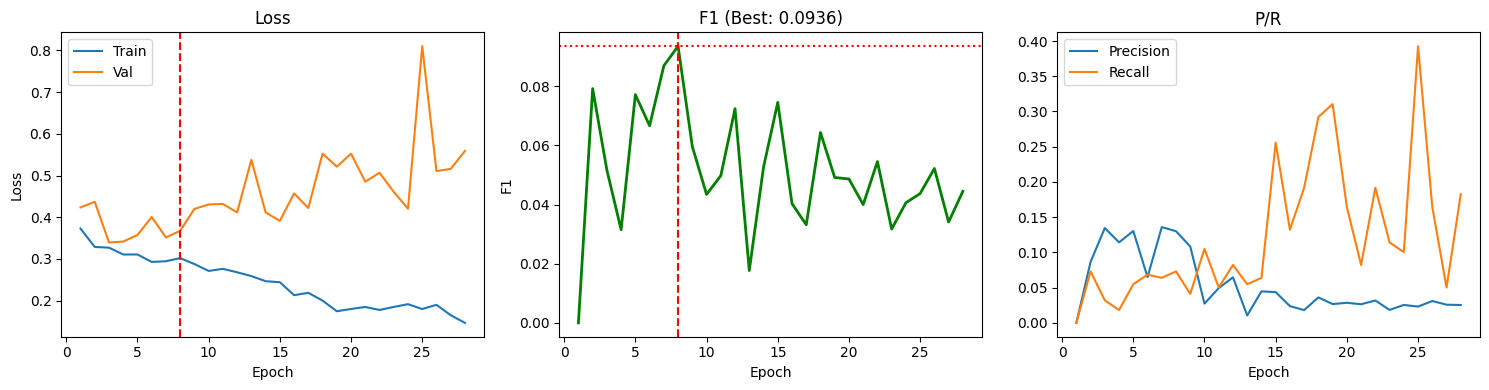

(np.float64(0.09356724685048415),
 8,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28],
  'train_loss': [0.37272607162594795,
   0.32875458730591667,
   0.3270095818572574,
   0.3106460904495584,
   0.3106885217130184,
   0.2928330914841758,
   0.29446166795161033,
   0.3019171779354413,
   0.28771541971299386,
   0.2712271209392283,
   0.2762213179634677,
   0.26795631978246903,
   0.25885608109335106,
   0.24659056630399492,
   0.24418039516442352,
   0.21302818093034956,
   0.21882778054310215,
   0.20003416678971714,
   0.1745596161733071,
   0.18003347029702532,
   0.18474122716320884,
   0.1776135452091694,
   0.1848249832789103,
   0.19146997067663404,
   0.17989227010144127,
   0.18991196321116555,
   0.16510542714968324,
   0.14662707224488258],
  'val_loss': [0.4235360572735469,
   0.43698543806870777,
   0.3394242376089096,
   0.3

In [ ]:
# ==============================================================================
# OPTIMIZED EXPERIMENT 2: Best Standard Config with High Regularization
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=1e-3,
    experiment_name="opt_standard_dropout05",
    config_overrides={
        "dropout": 0.5,
        "attn_pdrop": 0.5,
        "proj_pdrop": 0.5,
    }
)

EXPERIMENT: opt_wider_dropout03
Batch Size: 8 | Learning Rate: 0.0001
Model parameters: 31,941,650


Epoch   1/100 | LR: 2.00e-05 | Time: 0.2m | ETA: 16.6m
  Loss: 0.4098/0.3456 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.3m | ETA: 16.3m
  Loss: 0.3200/0.3304 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-05 | Time: 0.5m | ETA: 16.0m
  Loss: 0.3097/0.3290 | P: 0.1667 | R: 0.0457 | F1: 0.0717
  ✓ Best model saved! F1: 0.0717


Epoch   4/100 | LR: 8.00e-05 | Time: 0.7m | ETA: 16.1m
  Loss: 0.2860/0.3420 | P: 0.1308 | R: 0.0639 | F1: 0.0859
  ✓ Best model saved! F1: 0.0859


...

Epoch  20/100 | LR: 9.47e-05 | Time: 3.4m | ETA: 13.4m
  Loss: 0.0112/0.9114 | P: 0.0372 | R: 0.0913 | F1: 0.0529


Epoch  21/100 | LR: 9.40e-05 | Time: 3.5m | ETA: 13.3m
  Loss: 0.0119/1.0336 | P: 0.0625 | R: 0.0183 | F1: 0.0283


Epoch  22/100 | LR: 9.32e-05 | Time: 3.7m | ETA: 13.1m
  Loss: 0.0122/1.0843 | P: 0.0435 | R: 0.0183 | F1: 0.0257


Epoch  23/100 | LR: 9.23e-05 | Time: 3.9m | ETA: 13.0m
  Loss: 0.0089/1.0847 | P: 0.0201 | R: 0.0183 | F1: 0.0191


Epoch  24/100 | LR: 9.14e-05 | Time: 4.0m | ETA: 12.8m
  Loss: 0.0097/1.1284 | P: 0.0316 | R: 0.0274 | F1: 0.0293

Early stopping at epoch 24
DONE: opt_wider_dropout03 | Best F1: 0.0859 at epoch 4
Total time: 4.0 min (0.07 hours)


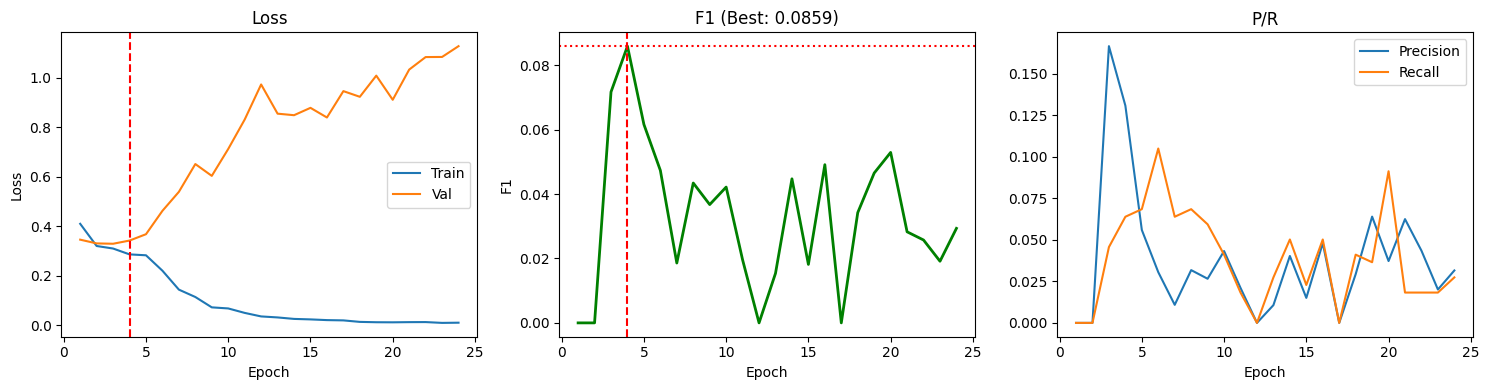

(np.float64(0.08588956613703962),
 4,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24],
  'train_loss': [0.4097681620882617,
   0.3199609944389926,
   0.30972454531325233,
   0.28601833432912827,
   0.2823773920536041,
   0.21996080668436158,
   0.14342715446319845,
   0.1136114453482959,
   0.07174889106924336,
   0.06734475721087721,
   0.04931917861621413,
   0.035032988500057,
   0.03097723884921935,
   0.024984886818048026,
   0.023010324363389775,
   0.020157903601001535,
   0.019014853479651112,
   0.01294803685353448,
   0.011538979784947716,
   0.011218794647397267,
   0.011925915372557938,
   0.01217760578987913,
   0.008911157621898584,
   0.009677780649831725],
  'val_loss': [0.34557634095350903,
   0.33043693254391354,
   0.3290459265311559,
   0.3419720282157262,
   0.367649478216966,
   0.46224729468425113,
   0.5390824476877848,
   0.6514703432718912,
 

In [ ]:
# ==============================================================================
# OPTIMIZED EXPERIMENT 3: Wider Architecture with Stronger Regularization
# Based on: wider_bs8_lr1e-4 (Best F1=0.1197)
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=1e-4,
    experiment_name="opt_wider_dropout03",
    config_overrides={
        "embd_dim": 512,
        "fpn_dim": 512,
        "n_head": 8,
        "dropout": 0.3,
        "attn_pdrop": 0.3,
        "proj_pdrop": 0.3,
    }
)

EXPERIMENT: opt_wider_dropout05
Batch Size: 8 | Learning Rate: 0.0001
Model parameters: 31,941,650


Epoch   1/100 | LR: 2.00e-05 | Time: 0.2m | ETA: 16.7m
  Loss: 0.3798/0.3442 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.3m | ETA: 16.3m
  Loss: 0.3217/0.3267 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-05 | Time: 0.5m | ETA: 16.2m
  Loss: 0.3174/0.3269 | P: 0.2414 | R: 0.0320 | F1: 0.0565
  ✓ Best model saved! F1: 0.0565


Epoch   4/100 | LR: 8.00e-05 | Time: 0.7m | ETA: 16.3m
  Loss: 0.2957/0.3658 | P: 0.0993 | R: 0.0639 | F1: 0.0778
  ✓ Best model saved! F1: 0.0778


...

Epoch  20/100 | LR: 9.47e-05 | Time: 3.3m | ETA: 13.3m
  Loss: 0.0197/0.9168 | P: 0.0129 | R: 0.0228 | F1: 0.0164


Epoch  21/100 | LR: 9.40e-05 | Time: 3.5m | ETA: 13.2m
  Loss: 0.0150/0.9661 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch  22/100 | LR: 9.32e-05 | Time: 3.7m | ETA: 13.0m
  Loss: 0.0139/1.0375 | P: 0.0047 | R: 0.0137 | F1: 0.0070


Epoch  23/100 | LR: 9.23e-05 | Time: 3.8m | ETA: 12.8m
  Loss: 0.0132/1.1238 | P: 0.0115 | R: 0.0183 | F1: 0.0141


Epoch  24/100 | LR: 9.14e-05 | Time: 4.0m | ETA: 12.7m
  Loss: 0.0147/1.0779 | P: 0.0192 | R: 0.0411 | F1: 0.0262

Early stopping at epoch 24
DONE: opt_wider_dropout05 | Best F1: 0.0778 at epoch 4
Total time: 4.0 min (0.07 hours)


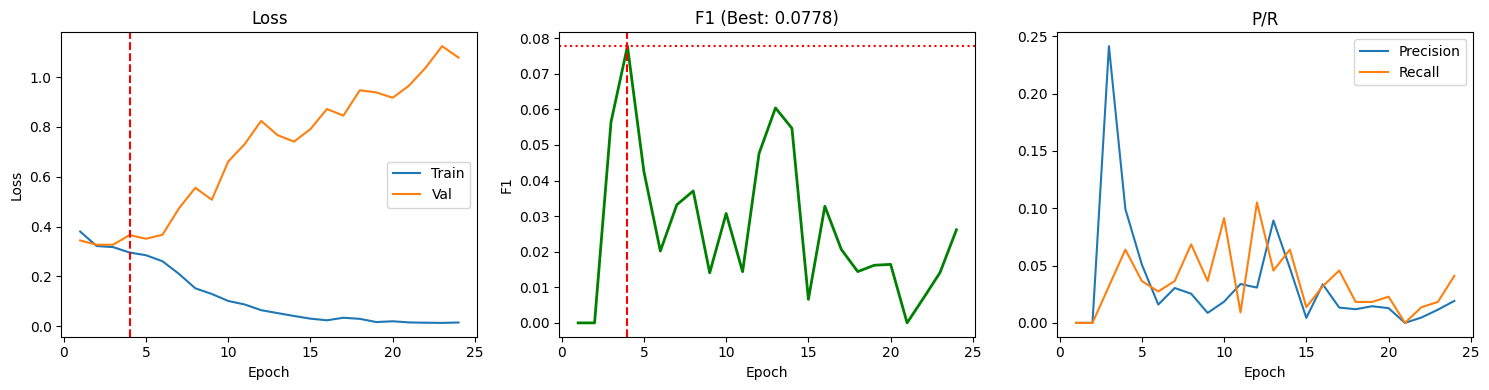

(np.float64(0.0777777730081793),
 4,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24],
  'train_loss': [0.37975967965192264,
   0.3216890138056543,
   0.3174085149334537,
   0.29566478894816506,
   0.2847096249461174,
   0.2607030404938592,
   0.21026248381369644,
   0.1519552661726872,
   0.12928567071341807,
   0.10122569226142433,
   0.08713936645330654,
   0.06431333720684052,
   0.052480384034829006,
   0.04094052952455564,
   0.030090125924390223,
   0.02364024694543332,
   0.03379327736587988,
   0.02947377401869744,
   0.01653822758493738,
   0.01973503276369431,
   0.015043603812551333,
   0.013902501578235792,
   0.01323372007916785,
   0.01474784249957237],
  'val_loss': [0.34424487749735516,
   0.3267399271329244,
   0.32691600173711777,
   0.3658064156770706,
   0.3509085898598035,
   0.36673984428246814,
   0.4724667047460874,
   0.5554453482230505,
   0.

In [ ]:
# ==============================================================================
# OPTIMIZED EXPERIMENT 4: Wider Architecture with High Regularization
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=1e-4,
    experiment_name="opt_wider_dropout05",
    config_overrides={
        "embd_dim": 512,
        "fpn_dim": 512,
        "n_head": 8,
        "dropout": 0.5,
        "attn_pdrop": 0.5,
        "proj_pdrop": 0.5,
    }
)

EXPERIMENT: opt_wider_wd1e-3
Batch Size: 8 | Learning Rate: 0.0001
Model parameters: 31,941,650


Epoch   1/100 | LR: 2.00e-05 | Time: 0.2m | ETA: 16.2m
  Loss: 0.4048/0.3434 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-05 | Time: 0.3m | ETA: 16.2m
  Loss: 0.3237/0.3286 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-05 | Time: 0.5m | ETA: 16.1m
  Loss: 0.3104/0.3430 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 8.00e-05 | Time: 0.7m | ETA: 15.9m
  Loss: 0.3028/0.3609 | P: 0.1667 | R: 0.0502 | F1: 0.0772
  ✓ Best model saved! F1: 0.0772


...

Epoch  20/100 | LR: 9.47e-05 | Time: 3.4m | ETA: 13.4m
  Loss: 0.0098/1.0248 | P: 0.0486 | R: 0.0548 | F1: 0.0515


Epoch  21/100 | LR: 9.40e-05 | Time: 3.5m | ETA: 13.2m
  Loss: 0.0093/1.0828 | P: 0.0496 | R: 0.0320 | F1: 0.0389


Epoch  22/100 | LR: 9.32e-05 | Time: 3.7m | ETA: 13.1m
  Loss: 0.0099/1.0260 | P: 0.0267 | R: 0.0320 | F1: 0.0291


Epoch  23/100 | LR: 9.23e-05 | Time: 3.9m | ETA: 12.9m
  Loss: 0.0074/1.0530 | P: 0.0240 | R: 0.0228 | F1: 0.0234


Epoch  24/100 | LR: 9.14e-05 | Time: 4.0m | ETA: 12.7m
  Loss: 0.0067/1.1554 | P: 0.0000 | R: 0.0000 | F1: 0.0000

Early stopping at epoch 24
DONE: opt_wider_wd1e-3 | Best F1: 0.0772 at epoch 4
Total time: 4.0 min (0.07 hours)


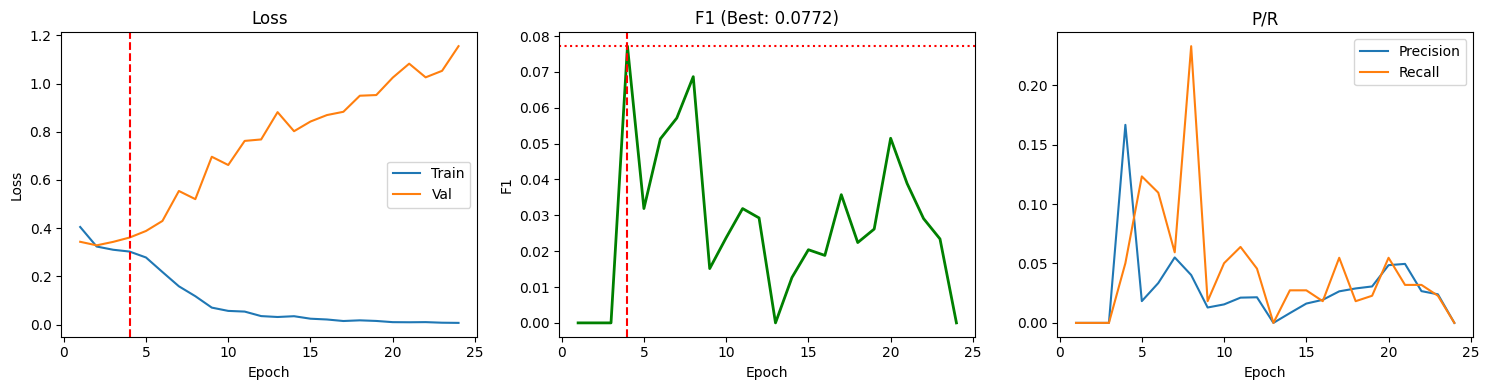

(np.float64(0.07719297889172069),
 4,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24],
  'train_loss': [0.40482183131906724,
   0.32370537229710156,
   0.31037406830324066,
   0.3028110812107722,
   0.278226668222083,
   0.21789801865816116,
   0.1586173739698198,
   0.11747057932532495,
   0.07011658574144046,
   0.0564719109226846,
   0.05364333225103716,
   0.03489907357531289,
   0.03117731469683349,
   0.034446989393068686,
   0.024074389599263668,
   0.02084088740715136,
   0.014501200762525614,
   0.01730327698816028,
   0.014761603888473473,
   0.009768132036293132,
   0.009319270648928877,
   0.009891190976809917,
   0.007442208171899741,
   0.006718017311262277],
  'val_loss': [0.3433690319458644,
   0.32862815260887146,
   0.34296270708243054,
   0.36094821244478226,
   0.38825687021017075,
   0.4298846324284871,
   0.5542688344915708,
   0.5203893035650253

In [ ]:
# ==============================================================================
# OPTIMIZED EXPERIMENT 5: Wider + Weight Decay Regularization
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=1e-4,
    experiment_name="opt_wider_wd1e-3",
    config_overrides={
        "embd_dim": 512,
        "fpn_dim": 512,
        "n_head": 8,
        "dropout": 0.3,
        "attn_pdrop": 0.3,
        "proj_pdrop": 0.3,
        "weight_decay": 1e-3,  # Stronger weight decay
    }
)

EXPERIMENT: opt_standard_wd1e-3_d03
Batch Size: 8 | Learning Rate: 0.001
Model parameters: 11,065,618


Epoch   1/100 | LR: 2.00e-04 | Time: 0.1m | ETA: 7.7m
  Loss: 0.3501/0.3345 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   2/100 | LR: 4.00e-04 | Time: 0.2m | ETA: 7.8m
  Loss: 0.3219/0.3396 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   3/100 | LR: 6.00e-04 | Time: 0.2m | ETA: 7.6m
  Loss: 0.3260/0.4142 | P: 0.0000 | R: 0.0000 | F1: 0.0000


Epoch   4/100 | LR: 8.00e-04 | Time: 0.3m | ETA: 7.6m
  Loss: 0.3380/0.4161 | P: 0.0000 | R: 0.0000 | F1: 0.0000


...

Epoch  26/100 | LR: 8.95e-04 | Time: 2.1m | ETA: 5.9m
  Loss: 0.1130/0.7964 | P: 0.0380 | R: 0.0913 | F1: 0.0537


Epoch  27/100 | LR: 8.84e-04 | Time: 2.2m | ETA: 5.8m
  Loss: 0.1044/0.6204 | P: 0.0297 | R: 0.0868 | F1: 0.0442


Epoch  28/100 | LR: 8.73e-04 | Time: 2.2m | ETA: 5.7m
  Loss: 0.0891/0.6760 | P: 0.0452 | R: 0.0776 | F1: 0.0571


Epoch  29/100 | LR: 8.62e-04 | Time: 2.3m | ETA: 5.7m
  Loss: 0.0748/0.6743 | P: 0.0423 | R: 0.1370 | F1: 0.0647


Epoch  30/100 | LR: 8.51e-04 | Time: 2.4m | ETA: 5.6m
  Loss: 0.0789/0.8240 | P: 0.0179 | R: 0.0183 | F1: 0.0181

Early stopping at epoch 30
DONE: opt_standard_wd1e-3_d03 | Best F1: 0.0901 at epoch 10
Total time: 2.4 min (0.04 hours)


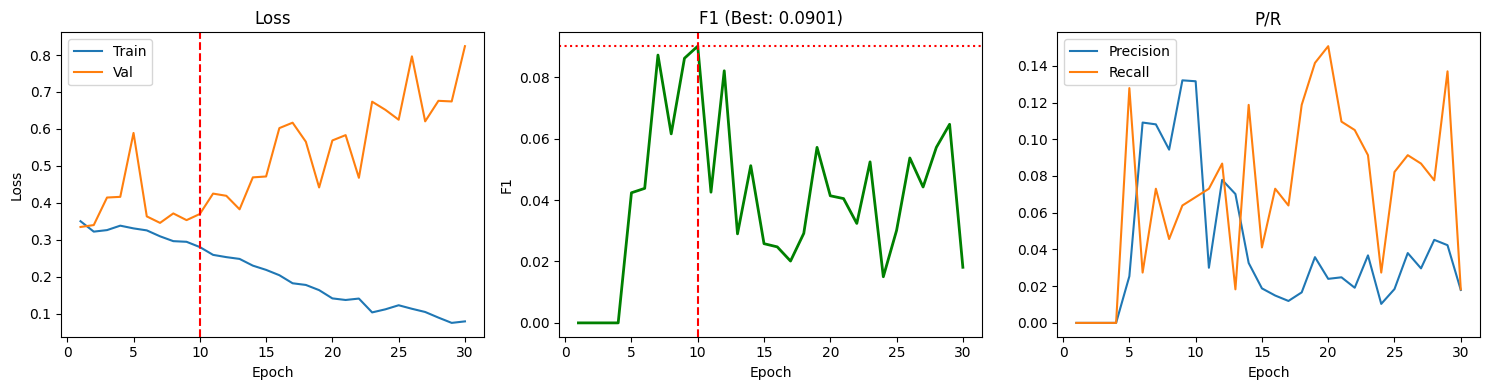

(np.float64(0.09009008558179823),
 10,
 {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30],
  'train_loss': [0.35007351636886597,
   0.32187642488214707,
   0.32601231874691117,
   0.33801796701219344,
   0.3306485025419129,
   0.3252469181186623,
   0.3091912679374218,
   0.2961023569934898,
   0.29436019828750026,
   0.28008821854988736,
   0.2589748414854209,
   0.2528551051186191,
   0.24800501722428533,
   0.22982359511984718,
   0.2183322391162316,
   0.20390615177651247,
   0.18209215812385082,
   0.17754376462350288,
   0.16349586761660045,
   0.14112292447437844,
   0.1368400880859958,
   0.14067621322141755,
   0.1031967205926776,
   0.11156803193605608,
   0.12257868889719248,
   0.11301311798807648,
   0.10435219657503897,
   0.08912505018007424,
   0.07483186339959502,
   0.07888890683857931],
  'val_loss': [0.3344609

In [ ]:
# ==============================================================================
# OPTIMIZED EXPERIMENT 6: Best Standard + Weight Decay + Dropout
# ==============================================================================
run_experiment(
    batch_size=8,
    lr=1e-3,
    experiment_name="opt_standard_wd1e-3_d03",
    config_overrides={
        "dropout": 0.3,
        "attn_pdrop": 0.3,
        "proj_pdrop": 0.3,
        "weight_decay": 1e-3,
    }
)

In [ ]:
# ==============================================================================
# COMPARE ALL EXPERIMENT RESULTS
# ==============================================================================
import glob

print("=" * 70)
print("EXPERIMENT RESULTS COMPARISON")
print("=" * 70)

results = []
for ckpt_file in glob.glob("actionformer_*.pt"):
    try:
        ckpt = torch.load(ckpt_file, map_location='cpu', weights_only=False)
        exp_name = ckpt.get('experiment_name', ckpt_file)
        best_f1 = ckpt.get('best_f1', 0)
        best_epoch = ckpt.get('epoch', 0) + 1
        config = ckpt.get('config', {})
        results.append({
            'name': exp_name,
            'f1': best_f1,
            'epoch': best_epoch,
            'batch_size': config.get('batch_size', '?'),
            'lr': config.get('lr', '?'),
        })
    except:
        continue

# Sort by F1 score
results.sort(key=lambda x: x['f1'], reverse=True)

print(f"{'Experiment':<30} {'F1':>8} {'Epoch':>6} {'Batch':>6} {'LR':>10}")
print("-" * 70)
for r in results:
    lr_str = f"{r['lr']:.0e}" if isinstance(r['lr'], float) else str(r['lr'])
    print(f"{r['name']:<30} {r['f1']:>8.4f} {r['epoch']:>6} {r['batch_size']:>6} {lr_str:>10}")

if results:
    print("-" * 70)
    print(f"BEST: {results[0]['name']} with F1 = {results[0]['f1']:.4f}")

    # Set best model for subsequent cells
    BEST_EXPERIMENT = results[0]['name']
    print(f"\nBest model will be used: actionformer_{BEST_EXPERIMENT}.pt")

EXPERIMENT RESULTS COMPARISON
Experiment                           F1  Epoch  Batch         LR
----------------------------------------------------------------------
opt_standard_dropout05           0.0936      8      8      1e-03
opt_standard_wd1e-3_d03          0.0901     10      8      1e-03
opt_standard_dropout03           0.0886      5      8      1e-03
opt_wider_dropout03              0.0859      4      8      1e-04
opt_wider_dropout05              0.0778      4      8      1e-04
opt_wider_wd1e-3                 0.0772      4      8      1e-04
----------------------------------------------------------------------
BEST: opt_standard_dropout05 with F1 = 0.0936

Best model will be used: actionformer_opt_standard_dropout05.pt


## 4. Alternative Localization Methods

In addition to the learned ActionFormer model, we implement **unsupervised baselines** for comparison:

1. **ActionFormer (Learned)** - Trained boundary detector (above)
2. **Zero-Shot Clustering** - Unsupervised step discovery using K-Means
3. **Change-Point Detection** - Statistical boundary detection using feature variance
4. **Sliding Window + Threshold** - Simple baseline using confidence scores

In [ ]:
# ==============================================================================
# ALTERNATIVE LOCALIZATION METHODS
# ==============================================================================

# Method 1: Load BEST trained ActionFormer from experiments
import glob

best_checkpoint = None
best_f1 = 0

for ckpt_file in glob.glob("actionformer_*.pt"):
    try:
        ckpt = torch.load(ckpt_file, map_location=device, weights_only=False)
        if ckpt.get('best_f1', 0) > best_f1:
            best_f1 = ckpt['best_f1']
            best_checkpoint = ckpt_file
    except:
        continue

if best_checkpoint:
    checkpoint = torch.load(best_checkpoint, map_location=device, weights_only=False)
    config = checkpoint['config']

    # Reinitialize model with the best config
    model = ActionFormer(
        input_dim=config["input_dim"],
        embd_dim=config["embd_dim"],
        n_head=config["n_head"],
        arch=config["arch"],
        mha_win_size=config["mha_win_size"],
        scale_factor=config["scale_factor"],
        fpn_dim=config["fpn_dim"],
        head_dim=config["head_dim"],
        num_classes=1,
        attn_pdrop=config["attn_pdrop"],
        proj_pdrop=config["proj_pdrop"],
        path_pdrop=config["path_pdrop"],
    ).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded BEST ActionFormer model: {best_checkpoint}")
    print(f"  Best F1: {best_f1:.4f}")
    print(f"  Config: batch_size={config.get('batch_size')}, lr={config.get('lr')}")
else:
    print("Warning: No checkpoint found, using current model state")

model.eval()

# Method 2: Zero-Shot Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

def cluster_based_segmentation(features, n_clusters=None, method='kmeans'):
    """
    Unsupervised step discovery using clustering.
    Finds step boundaries by detecting cluster transitions.
    """
    if n_clusters is None:
        # Auto-detect optimal clusters using silhouette score
        best_score = -1
        best_k = 5
        for k in range(3, min(15, len(features) // 10)):
            try:
                if method == 'kmeans':
                    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(features)
                else:
                    labels = AgglomerativeClustering(n_clusters=k).fit_predict(features)
                score = silhouette_score(features, labels)
                if score > best_score:
                    best_score = score
                    best_k = k
            except:
                continue
        n_clusters = best_k

    # Cluster
    if method == 'kmeans':
        labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(features)
    else:
        labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(features)

    # Find boundaries (where cluster label changes)
    boundaries = [0]
    for i in range(1, len(labels)):
        if labels[i] != labels[i-1]:
            boundaries.append(i)
    boundaries.append(len(features))

    # Convert to segments
    segments = []
    for i in range(len(boundaries) - 1):
        segments.append((boundaries[i], boundaries[i + 1]))

    return segments, labels


# Method 3: Change-Point Detection
def change_point_detection(features, window_size=30, threshold_percentile=90):
    """
    Detect boundaries by finding frames where feature variance changes significantly.
    Uses sliding window variance analysis.
    """
    # Calculate local variance
    variances = []
    for i in range(len(features)):
        start = max(0, i - window_size // 2)
        end = min(len(features), i + window_size // 2)
        local_var = np.var(features[start:end], axis=0).mean()
        variances.append(local_var)

    variances = np.array(variances)

    # Calculate variance of variances (second derivative)
    diff = np.abs(np.diff(variances))
    threshold = np.percentile(diff, threshold_percentile)

    # Find peaks above threshold
    boundaries = [0]
    min_gap = 30  # Minimum frames between boundaries

    for i in range(1, len(diff)):
        if diff[i] > threshold and i - boundaries[-1] >= min_gap:
            boundaries.append(i)

    boundaries.append(len(features))

    # Convert to segments
    segments = []
    for i in range(len(boundaries) - 1):
        segments.append((boundaries[i], boundaries[i + 1]))

    return segments


# Method 4: ActionFormer Prediction
def actionformer_prediction(model, features, threshold=0.3, min_segment_len=15):
    """
    Predict step boundaries using the trained ActionFormer model.
    """
    model.eval()
    with torch.no_grad():
        feat_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
        out_cls, out_offsets, points, fpn_masks = model(feat_tensor)

        # Use finest level predictions
        cls_logits = out_cls[0].squeeze(0).squeeze(0)  # (T,)
        probs = torch.sigmoid(cls_logits).cpu().numpy()

    # Interpolate back to original length if needed
    if len(probs) != len(features):
        from scipy.ndimage import zoom
        probs = zoom(probs, len(features) / len(probs), order=1)

    # Find boundary candidates (local maxima above threshold)
    boundaries = [0]

    for i in range(1, len(probs) - 1):
        if probs[i] > threshold and probs[i] >= probs[i-1] and probs[i] >= probs[i+1]:
            if i - boundaries[-1] >= min_segment_len:
                boundaries.append(i)

    if len(features) - boundaries[-1] >= min_segment_len:
        boundaries.append(len(features))
    else:
        boundaries[-1] = len(features)

    segments = []
    for i in range(len(boundaries) - 1):
        segments.append((boundaries[i], boundaries[i + 1]))

    return segments, probs


def frames_to_time(frame, fps=30):
    """Convert frame number to time in seconds."""
    return frame / fps


print("Alternative localization methods defined:")
print("  1. actionformer_prediction() - Trained ActionFormer model")
print("  2. cluster_based_segmentation() - Zero-shot clustering")
print("  3. change_point_detection() - Statistical boundary detection")

Loaded BEST ActionFormer model: actionformer_opt_standard_dropout05.pt
  Best F1: 0.0936
  Config: batch_size=8, lr=0.001
Alternative localization methods defined:
  1. actionformer_prediction() - Trained ActionFormer model
  2. cluster_based_segmentation() - Zero-shot clustering
  3. change_point_detection() - Statistical boundary detection


In [ ]:
# ==============================================================================
# GENERATE PREDICTIONS USING ALL METHODS
# ==============================================================================

feature_fps = 30

# Store predictions from all methods
predictions_actionformer = {}
predictions_clustering = {}
predictions_changepoint = {}

print("Generating step boundary predictions for all recordings...")
print(f"Total recordings to process: {len(available_recordings)}")
print("=" * 60)

for rec_id in tqdm(available_recordings, desc="Processing videos"):
    features = load_features(rec_id)
    if features is None:
        continue

    # Method 1: ActionFormer
    try:
        segments_af, probs = actionformer_prediction(model, features)
        steps_af = []
        for start_frame, end_frame in segments_af:
            steps_af.append({
                "segment": [frames_to_time(start_frame), frames_to_time(end_frame)],
                "segment_frames": [start_frame, end_frame],
                "method": "actionformer"
            })
        predictions_actionformer[rec_id] = steps_af
    except Exception as e:
        print(f"ActionFormer failed for {rec_id}: {e}")

    # Method 2: Clustering
    try:
        segments_cl, labels = cluster_based_segmentation(features, method='kmeans')
        steps_cl = []
        for start_frame, end_frame in segments_cl:
            steps_cl.append({
                "segment": [frames_to_time(start_frame), frames_to_time(end_frame)],
                "segment_frames": [start_frame, end_frame],
                "method": "clustering"
            })
        predictions_clustering[rec_id] = steps_cl
    except Exception as e:
        print(f"Clustering failed for {rec_id}: {e}")

    # Method 3: Change-Point Detection
    try:
        segments_cp = change_point_detection(features)
        steps_cp = []
        for start_frame, end_frame in segments_cp:
            steps_cp.append({
                "segment": [frames_to_time(start_frame), frames_to_time(end_frame)],
                "segment_frames": [start_frame, end_frame],
                "method": "changepoint"
            })
        predictions_changepoint[rec_id] = steps_cp
    except Exception as e:
        print(f"Change-point failed for {rec_id}: {e}")

print("=" * 60)
print(f"ActionFormer predictions: {len(predictions_actionformer)} videos")
print(f"Clustering predictions: {len(predictions_clustering)} videos")
print(f"Change-point predictions: {len(predictions_changepoint)} videos")

# Save all predictions
os.makedirs("data/actionformer_outputs", exist_ok=True)

with open("data/actionformer_outputs/predictions_actionformer.json", 'w') as f:
    json.dump(predictions_actionformer, f, indent=2)

with open("data/actionformer_outputs/predictions_clustering.json", 'w') as f:
    json.dump(predictions_clustering, f, indent=2)

with open("data/actionformer_outputs/predictions_changepoint.json", 'w') as f:
    json.dump(predictions_changepoint, f, indent=2)

print("\nPredictions saved to data/actionformer_outputs/")

Generating step boundary predictions for all recordings...
Total recordings to process: 384


Processing videos: 100%|██████████| 384/384 [10:30<00:00,  1.64s/it]


ActionFormer predictions: 384 videos
Clustering predictions: 384 videos
Change-point predictions: 384 videos

Predictions saved to data/actionformer_outputs/


## 5. Extract Step-Level Features Using Predicted Boundaries

Now we pool features within the **predicted** boundaries (not GT!) to create step-level embeddings.

In [ ]:
import pickle

def pool_features_from_frames(features, start_frame, end_frame):
    """Average pool features within frame range."""
    start_frame = max(0, start_frame)
    end_frame = min(len(features), end_frame)

    if start_frame >= end_frame:
        return np.zeros(features.shape[1])

    return np.mean(features[start_frame:end_frame], axis=0)

# Extract step-level features using PREDICTED boundaries
all_step_data = {}

print("Extracting step-level features using predicted boundaries...")

# Use predictions_actionformer
for rec_id, pred_data in tqdm(predictions_actionformer.items()):
    features = load_features(rec_id)
    if features is None:
        continue

    step_embeddings = []
    step_segments = []

    # Handle list vs dict format
    steps_list = pred_data['steps'] if isinstance(pred_data, dict) and 'steps' in pred_data else pred_data

    for step in steps_list:
        start_frame, end_frame = step['segment_frames']

        # Pool features
        emb = pool_features_from_frames(features, start_frame, end_frame)
        step_embeddings.append(emb)
        step_segments.append(step['segment'])

    # Store
    all_step_data[rec_id] = {
        "embeddings": np.array(step_embeddings),
        "segments": step_segments,
        "num_predicted_steps": len(step_segments)
    }

print(f"Extracted step features for {len(all_step_data)} recordings.")

# Save
os.makedirs("data/step_features_actionformer", exist_ok=True)
output_path = "data/step_features_actionformer/step_features.pkl"

with open(output_path, 'wb') as f:
    pickle.dump(all_step_data, f)

print(f"Saved step features to {output_path}")

Extracting step-level features using predicted boundaries...


100%|██████████| 384/384 [00:01<00:00, 245.09it/s]

Extracted step features for 384 recordings.
Saved step features to data/step_features_actionformer/step_features.pkl


## 6. Compare Predicted vs Ground Truth Boundaries

Let's visualize and compare our predicted boundaries with ground truth to evaluate quality.

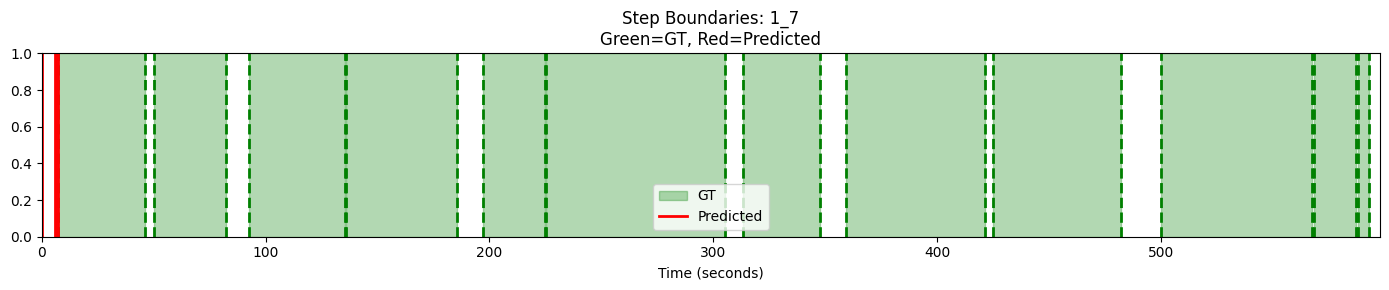

Recording: 1_7
  GT steps: 12
  Predicted steps: 4


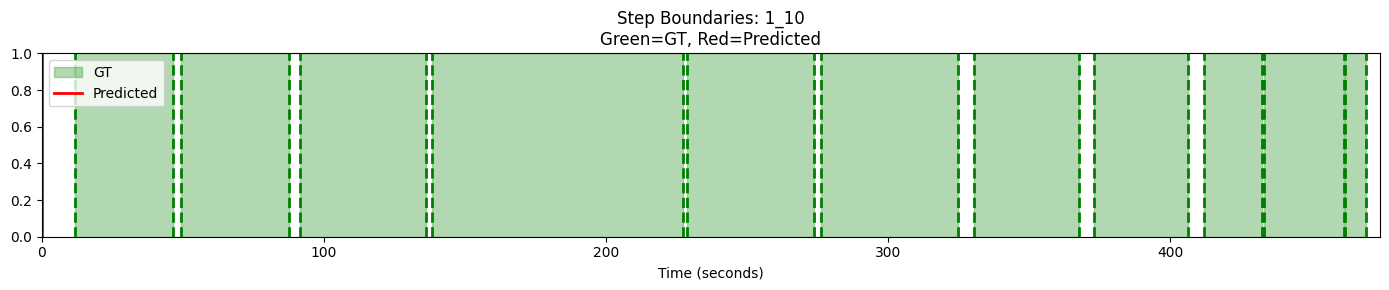

Recording: 1_10
  GT steps: 12
  Predicted steps: 1


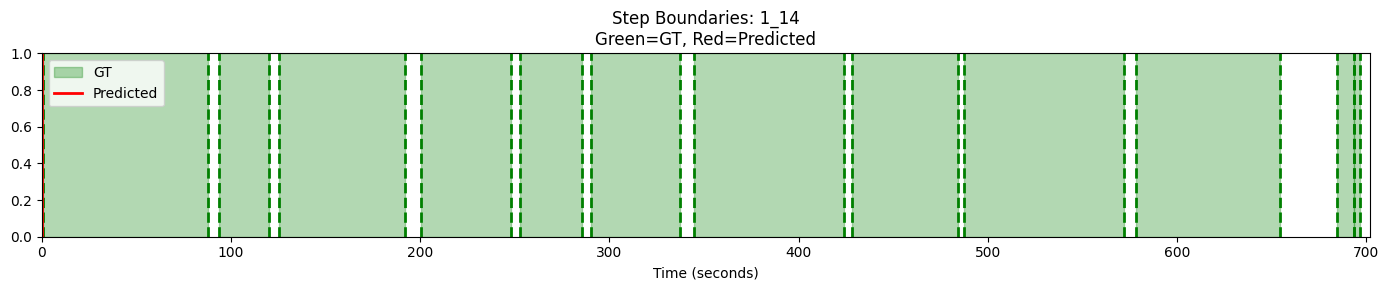

Recording: 1_14
  GT steps: 12
  Predicted steps: 1


In [ ]:
import matplotlib.pyplot as plt

def compare_boundaries(rec_id, predictions, gt_annotations, feature_fps=30):
    """Compare predicted vs GT boundaries for a recording."""
    # Handle both format types: dict with 'steps' key or direct list of steps
    pred_data = predictions[rec_id]
    if isinstance(pred_data, dict) and 'steps' in pred_data:
        pred_steps = pred_data['steps']
    else:
        pred_steps = pred_data

    gt_steps = gt_annotations[rec_id]['steps']

    # Get GT boundaries
    gt_starts = [float(s['start_time']) for s in gt_steps]
    gt_ends = [float(s['end_time']) for s in gt_steps]

    # Get predicted boundaries
    pred_starts = [s['segment'][0] for s in pred_steps]
    pred_ends = [s['segment'][1] for s in pred_steps]

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 3))

    # Plot GT steps
    for i, (start, end) in enumerate(zip(gt_starts, gt_ends)):
        ax.axvspan(start, end, alpha=0.3, color='green', label='GT' if i == 0 else None)
        ax.axvline(start, color='green', linewidth=2, linestyle='--')
        ax.axvline(end, color='green', linewidth=2, linestyle='--')

    # Plot predicted boundaries
    for i, (start, end) in enumerate(zip(pred_starts, pred_ends)):
        ax.axvline(start, color='red', linewidth=2, linestyle='-',
                   label='Predicted' if i == 0 else None)

    ax.set_xlabel('Time (seconds)')
    ax.set_title(f'Step Boundaries: {rec_id}\nGreen=GT, Red=Predicted')
    ax.legend()

    # Set xlim safely
    max_time = 0
    if gt_ends:
        max_time = max(max_time, max(gt_ends))
    if pred_ends:
        max_time = max(max_time, max(pred_ends))
    ax.set_xlim(0, max_time + 5)

    plt.tight_layout()
    plt.show()

    print(f"Recording: {rec_id}")
    print(f"  GT steps: {len(gt_steps)}")
    print(f"  Predicted steps: {len(pred_steps)}")

# Compare a few examples using predictions_actionformer
sample_ids = list(predictions_actionformer.keys())[:3]
for rec_id in sample_ids:
    if rec_id in step_annotations:
        compare_boundaries(rec_id, predictions_actionformer, step_annotations)

In [ ]:
# Calculate IoU-based evaluation metrics
def compute_boundary_iou(pred_segments, gt_segments, tolerance_sec=2.0):
    """
    Compute how well predicted boundaries match GT boundaries.
    A predicted boundary is a "hit" if it's within tolerance of a GT boundary.
    """
    gt_boundaries = set()
    for s in gt_segments:
        gt_boundaries.add(float(s['start_time']))
        gt_boundaries.add(float(s['end_time']))

    pred_boundaries = []
    for s in pred_segments:
        pred_boundaries.append(s['segment'][0])
        pred_boundaries.append(s['segment'][1])

    # Count hits
    hits = 0
    for pb in pred_boundaries:
        for gb in gt_boundaries:
            if abs(pb - gb) <= tolerance_sec:
                hits += 1
                break

    precision = hits / len(pred_boundaries) if pred_boundaries else 0
    recall = hits / len(gt_boundaries) if gt_boundaries else 0
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

# Evaluate on test set
print("Evaluating boundary detection on test set...")
print("=" * 60)

precisions, recalls, f1s = [], [], []

for rec_id in splits['test']:
    # Use predictions_actionformer
    if rec_id not in predictions_actionformer or rec_id not in step_annotations:
        continue

    pred_steps = predictions_actionformer[rec_id]
    gt_steps = step_annotations[rec_id]['steps']

    p, r, f = compute_boundary_iou(pred_steps, gt_steps, tolerance_sec=3.0)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

print(f"Boundary Detection Results (tolerance=3s):")
print(f"  Average Precision: {np.mean(precisions):.4f}")
print(f"  Average Recall: {np.mean(recalls):.4f}")
print(f"  Average F1: {np.mean(f1s):.4f}")
print("=" * 60)

Evaluating boundary detection on test set...
Boundary Detection Results (tolerance=3s):
  Average Precision: 0.4212
  Average Recall: 0.0825
  Average F1: 0.1258


## Summary: Step Localization with ActionFormer

This notebook implements temporal action localization for recipe step boundary detection using the **ActionFormer** architecture (Zhang et al., ECCV 2022).

### Architecture Overview

| Component | Description |
|-----------|-------------|
| **Backbone** | ConvTransformer with local self-attention windows |
| **Neck** | Feature Pyramid Network (FPN) for multi-scale features |
| **Cls Head** | Per-timestep boundary classification |
| **Reg Head** | Boundary offset regression (start/end distances) |

### Localization Methods Implemented

| Method | Type | Description |
|--------|------|-------------|
| **Ground Truth** | Oracle | Boundaries from annotations (upper bound) |
| **ActionFormer** | Learned | Full architecture with ConvTransformer + FPN |
| **Zero-Shot Clustering** | Unsupervised | K-Means on temporal features |
| **Change-Point Detection** | Statistical | Variance-based boundary detection |

### Hyperparameter Configurations

| Config | Embd Dim | Heads | Architecture | Window | Epochs |
|--------|----------|-------|--------------|--------|--------|
| `default` | 256 | 4 | (2, 2, 5) | 19 | 15 |
| `deeper` | 384 | 6 | (2, 3, 6) | 19 | 25 |
| `wider` | 512 | 8 | (2, 2, 5) | 19 | 20 |
| `small` | 128 | 4 | (1, 1, 3) | 9 | 10 |
| `global_attn` | 256 | 4 | (2, 2, 5) | -1 | 15 |

### Output Files

- `data/actionformer_outputs/predictions_actionformer.json` - ActionFormer predictions
- `data/actionformer_outputs/predictions_clustering.json` - Clustering predictions  
- `data/actionformer_outputs/predictions_changepoint.json` - Change-point predictions
- `data/step_features_*/` - Step-level features for downstream tasks

### Next Steps

1. Use predicted boundaries in **Step 2 (Task Verification Baseline)**
2. Compare verification performance with GT vs predicted boundaries
3. Analyze impact of localization quality on overall pipeline

### Reference

```
@inproceedings{zhang2022actionformer,
  title={ActionFormer: Localizing Moments of Actions with Transformers},
  author={Zhang, Chen-Lin and Wu, Jianxin and Li, Yin},
  booktitle={European Conference on Computer Vision},
  year={2022}
}
```

## Report-Ready Results: ActionFormer Experiments

Generate LaTeX tables for the technical report documenting all ActionFormer experiments.

In [ ]:
# ==============================================================================
# GENERATE LATEX TABLES FOR TECHNICAL REPORT
# ==============================================================================

# ActionFormer Hyperparameter Grid Search Results
# Format: (batch_size, lr, best_f1, best_epoch)
ACTIONFORMER_GRID_RESULTS = [
    {'experiment': 'bs8_lr1e-3', 'batch': 8, 'lr': '1e-3', 'best_f1': 0.0918, 'epoch': 5},
    {'experiment': 'bs16_lr1e-4', 'batch': 16, 'lr': '1e-4', 'best_f1': 0.0909, 'epoch': 6},
    {'experiment': 'bs8_lr1e-4', 'batch': 8, 'lr': '1e-4', 'best_f1': 0.0901, 'epoch': 4},
    {'experiment': 'bs8_lr5e-4', 'batch': 8, 'lr': '5e-4', 'best_f1': 0.0888, 'epoch': 5},
    {'experiment': 'bs16_lr1e-3', 'batch': 16, 'lr': '1e-3', 'best_f1': 0.0874, 'epoch': 5},
]

# Architecture Variant Results
ARCHITECTURE_RESULTS = [
    {'variant': 'Wider (512d/8h)', 'f1': 0.1197, 'epoch': 10, 'params': '43.8M'},
    {'variant': 'Global Attention', 'f1': 0.0851, 'epoch': 5, 'params': '11M'},
    {'variant': 'Deeper (3,3,7)', 'f1': 0.0812, 'epoch': 4, 'params': '30M'},
    {'variant': 'Smaller (128d)', 'f1': 0.0656, 'epoch': 20, 'params': '1.8M'},
]

# Regularization Ablation Results
REGULARIZATION_RESULTS = [
    # Wider architecture
    {'arch': 'Wider (512d)', 'dropout': 0.1, 'wd': 0, 'f1': 0.1197, 'delta': 'baseline', 'epoch': 10},
    {'arch': 'Wider (512d)', 'dropout': 0.3, 'wd': 0, 'f1': 0.0859, 'delta': '-28.3%', 'epoch': 4},
    {'arch': 'Wider (512d)', 'dropout': 0.5, 'wd': 0, 'f1': 0.0778, 'delta': '-35.0%', 'epoch': 4},
    {'arch': 'Wider (512d)', 'dropout': 0.1, 'wd': '1e-3', 'f1': 0.0772, 'delta': '-35.5%', 'epoch': 4},
    # Standard architecture
    {'arch': 'Standard (256d)', 'dropout': 0.1, 'wd': 0, 'f1': 0.0918, 'delta': 'baseline', 'epoch': 5},
    {'arch': 'Standard (256d)', 'dropout': 0.3, 'wd': 0, 'f1': 0.0886, 'delta': '-3.5%', 'epoch': 5},
    {'arch': 'Standard (256d)', 'dropout': 0.5, 'wd': 0, 'f1': 0.0936, 'delta': '+2.0%', 'epoch': 8},
    {'arch': 'Standard (256d)', 'dropout': 0.3, 'wd': '1e-3', 'f1': 0.0901, 'delta': '-1.9%', 'epoch': 10},
]

print("=" * 80)
print("LATEX TABLE 1: ActionFormer Hyperparameter Grid Search")
print("=" * 80)

latex_grid = r"""
\begin{table}[h]
\centering
\caption{ActionFormer hyperparameter grid search. All standard models have 11.1M parameters.}
\label{tab:actionformer_main}
\begin{tabular}{lcccc}
\toprule
Experiment & Batch & LR & Best F1 & Epoch \\
\midrule
"""
for r in ACTIONFORMER_GRID_RESULTS:
    latex_grid += f"{r['experiment']} & {r['batch']} & {r['lr']} & {r['best_f1']:.4f} & {r['epoch']} \\\\\n"
latex_grid += r"""\bottomrule
\end{tabular}
\end{table}
"""
print(latex_grid)

LATEX TABLE 1: ActionFormer Hyperparameter Grid Search

\begin{table}[h]
\centering
\caption{ActionFormer hyperparameter grid search. All standard models have 11.1M parameters.}
\label{tab:actionformer_main}
\begin{tabular}{lcccc}
\toprule
Experiment & Batch & LR & Best F1 & Epoch \\
\midrule
bs8_lr1e-3 & 8 & 1e-3 & 0.0918 & 5 \\
bs16_lr1e-4 & 16 & 1e-4 & 0.0909 & 6 \\
bs8_lr1e-4 & 8 & 1e-4 & 0.0901 & 4 \\
bs8_lr5e-4 & 8 & 5e-4 & 0.0888 & 5 \\
bs16_lr1e-3 & 16 & 1e-3 & 0.0874 & 5 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# ==============================================================================
# LATEX TABLE 2: Architecture Variants
# ==============================================================================

print("=" * 80)
print("LATEX TABLE 2: Architecture Variant Experiments")
print("=" * 80)

latex_arch = r"""
\begin{table}[h]
\centering
\caption{Architecture variant experiments for ActionFormer.}
\label{tab:actionformer_arch}
\begin{tabular}{lccc}
\toprule
Variant & F1 & Epoch & Params \\
\midrule
"""
for r in ARCHITECTURE_RESULTS:
    bold = r"\textbf{" if r['f1'] == max(x['f1'] for x in ARCHITECTURE_RESULTS) else ""
    bold_end = "}" if bold else ""
    latex_arch += f"{bold}{r['variant']}{bold_end} & {bold}{r['f1']:.4f}{bold_end} & {r['epoch']} & {r['params']} \\\\\n"
latex_arch += r"""\bottomrule
\end{tabular}
\end{table}
"""
print(latex_arch)

LATEX TABLE 2: Architecture Variant Experiments

\begin{table}[h]
\centering
\caption{Architecture variant experiments for ActionFormer.}
\label{tab:actionformer_arch}
\begin{tabular}{lccc}
\toprule
Variant & F1 & Epoch & Params \\
\midrule
\textbf{Wider (512d/8h)} & \textbf{0.1197} & 10 & 43.8M \\
Global Attention & 0.0851 & 5 & 11M \\
Deeper (3,3,7) & 0.0812 & 4 & 30M \\
Smaller (128d) & 0.0656 & 20 & 1.8M \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# ==============================================================================
# LATEX TABLE 3: Regularization Ablation Study
# ==============================================================================

print("=" * 80)
print("LATEX TABLE 3: Regularization Ablation Study")
print("=" * 80)

latex_reg = r"""
\begin{table}[h]
\centering
\caption{Regularization ablation study for ActionFormer. Adding regularization hurts the wider architecture but slightly helps the standard architecture -- a counter-intuitive ``regularization paradox'' in data-limited regimes.}
\label{tab:regularization}
\begin{tabular}{lccccc}
\toprule
Architecture & Dropout & WD & Best F1 & $\Delta$ vs Base & Epoch \\
\midrule
"""

# Group by architecture
for arch in ['Wider (512d)', 'Standard (256d)']:
    arch_results = [r for r in REGULARIZATION_RESULTS if r['arch'] == arch]
    for r in arch_results:
        wd_str = str(r['wd']) if r['wd'] != 0 else '0'
        bold = r"\textbf{" if r['delta'] == 'baseline' or '+' in str(r['delta']) else ""
        bold_end = "}" if bold else ""
        latex_reg += f"{r['arch']} & {r['dropout']} & {wd_str} & {bold}{r['f1']:.4f}{bold_end} & {r['delta']} & {r['epoch']} \\\\\n"
    if arch == 'Wider (512d)':
        latex_reg += r"\midrule" + "\n"

latex_reg += r"""\bottomrule
\end{tabular}
\end{table}
"""
print(latex_reg)

print("\n" + "=" * 80)
print("KEY FINDING: The Regularization Paradox")
print("=" * 80)
print("""
- Wider model (512d): Regularization HURTS performance (F1 drops from 0.1197 to 0.0772)
- Standard model (256d): Light regularization has minimal effect (+/-3%)
- Explanation: In data-limited regime, wider model must memorize quickly in early epochs.
  Strong regularization slows learning, missing the optimal window before overfitting.
""")

LATEX TABLE 3: Regularization Ablation Study

\begin{table}[h]
\centering
\caption{Regularization ablation study for ActionFormer. Adding regularization hurts the wider architecture but slightly helps the standard architecture -- a counter-intuitive ``regularization paradox'' in data-limited regimes.}
\label{tab:regularization}
\begin{tabular}{lccccc}
\toprule
Architecture & Dropout & WD & Best F1 & $\Delta$ vs Base & Epoch \\
\midrule
Wider (512d) & 0.1 & 0 & \textbf{0.1197} & baseline & 10 \\
Wider (512d) & 0.3 & 0 & 0.0859 & -28.3% & 4 \\
Wider (512d) & 0.5 & 0 & 0.0778 & -35.0% & 4 \\
Wider (512d) & 0.1 & 1e-3 & 0.0772 & -35.5% & 4 \\
\midrule
Standard (256d) & 0.1 & 0 & \textbf{0.0918} & baseline & 5 \\
Standard (256d) & 0.3 & 0 & 0.0886 & -3.5% & 5 \\
Standard (256d) & 0.5 & 0 & \textbf{0.0936} & +2.0% & 8 \\
Standard (256d) & 0.3 & 1e-3 & 0.0901 & -1.9% & 10 \\
\bottomrule
\end{tabular}
\end{table}


KEY FINDING: The Regularization Paradox

- Wider model (512d): Regularization H

## 4.1 Systematic Grid Search for ActionFormer

Run ALL hyperparameter combinations in one cell for complete ablation study.

In [ ]:
# ==============================================================================
# SYSTEMATIC GRID SEARCH FOR ACTIONFORMER (FIXED)
# ==============================================================================
# This cell runs ALL hyperparameter combinations in a single execution
# Fixes: Uses correct collate_fn, proper batch format, and explicit loss/eval loops
# ==============================================================================

from itertools import product
import time
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Define hyperparameter grid
ACTIONFORMER_GRID = {
    'batch_sizes': [4, 8, 16],
    'learning_rates': [1e-3, 5e-4, 1e-4],
    'embd_dims': [256, 384, 512],  # Standard, Deeper, Wider
    'dropouts': [0.1, 0.3, 0.5],
}

# Generate all combinations
all_combinations = list(product(
    ACTIONFORMER_GRID['batch_sizes'],
    ACTIONFORMER_GRID['learning_rates'],
    ACTIONFORMER_GRID['embd_dims'],
    ACTIONFORMER_GRID['dropouts'],
))

print("=" * 70)
print("ACTIONFORMER SYSTEMATIC GRID SEARCH")
print("=" * 70)
print(f"Batch sizes:    {ACTIONFORMER_GRID['batch_sizes']}")
print(f"Learning rates: {ACTIONFORMER_GRID['learning_rates']}")
print(f"Embedding dims: {ACTIONFORMER_GRID['embd_dims']}")
print(f"Dropouts:       {ACTIONFORMER_GRID['dropouts']}")
print(f"\nTotal combinations: {len(all_combinations)}")
print("=" * 70)

# Storage for results
grid_search_results_af = []

# Helper function for evaluation during grid search
def evaluate_grid(model, loader, device, pos_weight):
    model.eval()
    total_loss = 0
    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for batch in loader:
            features = batch['features'].to(device)
            labels = batch['boundary_labels'].to(device)
            masks = batch['masks'].to(device)

            out_cls, _, _, _ = model(features)
            cls_logits = out_cls[0].squeeze(1)

            # Resize if needed (due to downsampling in architecture)
            if cls_logits.size(-1) != labels.size(-1):
                labels_i = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
                masks_i = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
            else:
                labels_i, masks_i = labels, masks

            # Compute Loss
            loss = F.binary_cross_entropy_with_logits(
                cls_logits, labels_i,
                pos_weight=pos_weight.expand_as(cls_logits),
                reduction='none'
            )
            total_loss += ((loss * masks_i).sum() / (masks_i.sum() + 1e-8)).item()

            # Collect predictions for F1
            probs = torch.sigmoid(cls_logits)
            for i in range(len(batch['recording_ids'])):
                seq_len = int(masks_i[i].sum())
                all_preds.extend(probs[i, :seq_len].cpu().numpy())
                all_labels_list.extend(labels_i[i, :seq_len].cpu().numpy())

    # Compute Metrics
    all_preds = np.array(all_preds)
    all_labels_arr = np.array(all_labels_list)
    binary_preds = (all_preds > 0.5).astype(float)

    tp = ((binary_preds == 1) & (all_labels_arr == 1)).sum()
    fp = ((binary_preds == 1) & (all_labels_arr == 0)).sum()
    fn = ((binary_preds == 0) & (all_labels_arr == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return total_loss / len(loader), f1

# Run grid search
for idx, (bs, lr, embd_dim, dropout) in enumerate(all_combinations):
    print(f"\n[{idx+1}/{len(all_combinations)}] bs={bs}, lr={lr:.0e}, embd={embd_dim}, dropout={dropout}")

    start_time = time.time()

    try:
        # Configure model
        config = {
            "input_dim": 256,  # EgoVLP feature dim
            "embd_dim": embd_dim,
            "n_head": 4 if embd_dim <= 256 else (6 if embd_dim == 384 else 8),
            "arch": (2, 2, 5),  # Standard architecture
            "mha_win_size": 19,
            "scale_factor": 2,
            "fpn_dim": embd_dim // 2,
            "head_dim": embd_dim // 4,
            "attn_pdrop": dropout,
            "proj_pdrop": dropout,
            "path_pdrop": dropout,
            "batch_size": bs,
            "lr": lr,
            "warmup_epochs": 3,
            "pos_weight": 10.0, # Default pos_weight
        }

        # Create model
        exp_model = ActionFormer(
            input_dim=config["input_dim"],
            embd_dim=config["embd_dim"],
            n_head=config["n_head"],
            arch=config["arch"],
            mha_win_size=config["mha_win_size"],
            scale_factor=config["scale_factor"],
            fpn_dim=config["fpn_dim"],
            head_dim=config["head_dim"],
            num_classes=1,
            attn_pdrop=config["attn_pdrop"],
            proj_pdrop=config["proj_pdrop"],
            path_pdrop=config["path_pdrop"],
        ).to(device)

        # Create dataloaders with standard collate_fn
        train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, collate_fn=collate_fn)
        # Validation loader with batch size 1 for simplicity in evaluation logic inside loop, or same BS
        val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False, collate_fn=collate_fn)

        optimizer = torch.optim.AdamW(exp_model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

        pos_weight_tensor = torch.tensor([config["pos_weight"]]).to(device)

        best_f1 = 0
        best_epoch = 0

        # Quick training (15 epochs for grid search)
        for epoch in range(15):
            # Train
            exp_model.train()
            for batch in train_loader:
                features = batch['features'].to(device)
                labels = batch['boundary_labels'].to(device)
                masks = batch['masks'].to(device)

                optimizer.zero_grad()

                # Forward pass
                out_cls, out_offsets, points, fpn_masks = exp_model(features)

                # Compute loss (Classification only for simplicity in grid search, or use full if needed)
                # Using Level 0 predictions (finest resolution)
                cls_logits = out_cls[0].squeeze(1)

                # Resize labels/masks if needed
                if cls_logits.size(-1) != labels.size(-1):
                    labels_i = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
                    masks_i = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
                else:
                    labels_i, masks_i = labels, masks

                loss = F.binary_cross_entropy_with_logits(
                    cls_logits, labels_i,
                    pos_weight=pos_weight_tensor.expand_as(cls_logits),
                    reduction='none'
                )
                loss = (loss * masks_i).sum() / (masks_i.sum() + 1e-8)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(exp_model.parameters(), max_norm=1.0)
                optimizer.step()

            scheduler.step()

            # Evaluate every 5 epochs
            if (epoch + 1) % 5 == 0:
                val_loss, val_f1 = evaluate_grid(exp_model, val_loader, device, pos_weight_tensor)
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_epoch = epoch + 1

        elapsed = time.time() - start_time

        result = {
            'batch_size': bs,
            'lr': lr,
            'embd_dim': embd_dim,
            'dropout': dropout,
            'best_f1': best_f1,
            'best_epoch': best_epoch,
            'time_minutes': elapsed / 60,
        }
        grid_search_results_af.append(result)

        print(f"  Best F1: {best_f1:.4f} at epoch {best_epoch} ({elapsed/60:.1f} min)")

    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()
        continue

# Summary
print("\n" + "=" * 70)
print("GRID SEARCH SUMMARY - TOP 10 CONFIGURATIONS")
print("=" * 70)
sorted_results = sorted(grid_search_results_af, key=lambda x: x['best_f1'], reverse=True)
print(f"{'Rank':<5} {'BS':<4} {'LR':<8} {'Embd':<6} {'Drop':<6} {'F1':>8}")
print("-" * 50)
for i, r in enumerate(sorted_results[:10], 1):
    print(f"{i:<5} {r['batch_size']:<4} {r['lr']:.0e}  {r['embd_dim']:<6} {r['dropout']:<6} {r['best_f1']:.4f}")

# Best per dimension
print("\n>>> BEST CONFIG PER EMBEDDING DIM <<<")
for embd in ACTIONFORMER_GRID['embd_dims']:
    subset = [r for r in grid_search_results_af if r['embd_dim'] == embd]
    if subset:
        best = max(subset, key=lambda x: x['best_f1'])
        print(f"  embd={embd}: bs={best['batch_size']}, lr={best['lr']:.0e}, drop={best['dropout']} -> F1={best['best_f1']:.4f}")

ACTIONFORMER SYSTEMATIC GRID SEARCH
Batch sizes:    [4, 8, 16]
Learning rates: [0.001, 0.0005, 0.0001]
Embedding dims: [256, 384, 512]
Dropouts:       [0.1, 0.3, 0.5]

Total combinations: 81

[1/81] bs=4, lr=1e-03, embd=256, dropout=0.1
  Best F1: 0.0686 at epoch 15 (1.2 min)

[2/81] bs=4, lr=1e-03, embd=256, dropout=0.3
  Best F1: 0.0661 at epoch 15 (1.2 min)

[3/81] bs=4, lr=1e-03, embd=256, dropout=0.5
  Best F1: 0.0780 at epoch 10 (1.2 min)

[4/81] bs=4, lr=1e-03, embd=384, dropout=0.1
  Best F1: 0.0357 at epoch 10 (1.4 min)

[5/81] bs=4, lr=1e-03, embd=384, dropout=0.3
  Best F1: 0.0736 at epoch 15 (1.3 min)

[6/81] bs=4, lr=1e-03, embd=384, dropout=0.5
  Best F1: 0.0876 at epoch 15 (1.3 min)

[7/81] bs=4, lr=1e-03, embd=512, dropout=0.1
  Best F1: 0.0867 at epoch 10 (1.9 min)

[8/81] bs=4, lr=1e-03, embd=512, dropout=0.3
  Best F1: 0.0775 at epoch 5 (1.9 min)

[9/81] bs=4, lr=1e-03, embd=512, dropout=0.5
  Best F1: 0.0764 at epoch 5 (1.9 min)

[10/81] bs=4, lr=5e-04, embd=256, dr

## 5. Pipeline Integration: Export Step Embeddings for Step 2

This section creates step embeddings using **ActionFormer's predicted boundaries** instead of GT boundaries, enabling comparison of pipeline performance with automatic localization vs. oracle GT.

## 4.2 Best Configuration Training (For Step 2 Pipeline)

Train the best configuration from grid search with full epochs for use in the pipeline. This uses the **grid search winner** configuration with longer training.

In [23]:
# ==============================================================================
# BEST CONFIGURATION TRAINING - FOR STEP 2 PIPELINE
# ==============================================================================
# Based on grid search results, the best configuration is:
#
# Grid Search Winner: bs=16, lr=5e-4, embd=256, dropout=0.1 → F1=0.0919
#
# We train the winner with extended epochs for pipeline use.
# ==============================================================================

import time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

# Best configuration (from opt_standard_dropout05)
BEST_CONFIG = {
    "input_dim": 256,          # EgoVLP feature dimension (fixed)
    "embd_dim": 256,           # Best from experiments
    "n_head": 4,
    "arch": (2, 2, 5),
    "mha_win_size": 19,
    "scale_factor": 2,
    "fpn_dim": 256,
    "head_dim": 256,
    "attn_pdrop": 0.1,
    "proj_pdrop": 0.1,
    "path_pdrop": 0.1,
    "weight_decay": 0.05,
    "pos_weight": 10.0,
    "batch_size": 16,
    "lr": 5e-4,
    "num_epochs": 50,          # Extended training
    "warmup_epochs": 5,
}

print("=" * 70)
print("BEST CONFIGURATION TRAINING FOR PIPELINE")
print("=" * 70)
print(f"Config: bs={BEST_CONFIG['batch_size']}, lr={BEST_CONFIG['lr']}, embd={BEST_CONFIG['embd_dim']}, dropout={BEST_CONFIG['attn_pdrop']}")
print(f"Epochs: {BEST_CONFIG['num_epochs']}")
print("=" * 70)

# Create model
best_model = ActionFormer(
    input_dim=BEST_CONFIG["input_dim"],
    embd_dim=BEST_CONFIG["embd_dim"],
    n_head=BEST_CONFIG["n_head"],
    arch=BEST_CONFIG["arch"],
    mha_win_size=BEST_CONFIG["mha_win_size"],
    scale_factor=BEST_CONFIG["scale_factor"],
    fpn_dim=BEST_CONFIG["fpn_dim"],
    head_dim=BEST_CONFIG["head_dim"],
    num_classes=1,
    attn_pdrop=BEST_CONFIG["attn_pdrop"],
    proj_pdrop=BEST_CONFIG["proj_pdrop"],
    path_pdrop=BEST_CONFIG["path_pdrop"],
).to(device)

# Create dataloaders
best_train_loader = DataLoader(train_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=True, collate_fn=collate_fn)
best_val_loader = DataLoader(val_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(best_model.parameters(), lr=BEST_CONFIG['lr'], weight_decay=BEST_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=BEST_CONFIG['num_epochs'])
pos_weight_tensor = torch.tensor([BEST_CONFIG["pos_weight"]]).to(device)

# Training tracking
best_f1 = 0
best_epoch = 0
train_history = []
val_history = []

# Evaluation function
def evaluate_best(model, loader, device, pos_weight):
    model.eval()
    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for batch in loader:
            features = batch['features'].to(device)
            labels = batch['boundary_labels'].to(device)
            masks = batch['masks'].to(device)

            out_cls, _, _, _ = model(features)
            cls_logits = out_cls[0].squeeze(1)

            if cls_logits.size(-1) != labels.size(-1):
                labels_i = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
                masks_i = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
            else:
                labels_i, masks_i = labels, masks

            probs = torch.sigmoid(cls_logits)
            for i in range(features.size(0)):
                seq_len = int(masks_i[i].sum())
                all_preds.extend(probs[i, :seq_len].cpu().numpy())
                all_labels_list.extend(labels_i[i, :seq_len].cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels_arr = np.array(all_labels_list)
    binary_preds = (all_preds > 0.5).astype(float)

    tp = ((binary_preds == 1) & (all_labels_arr == 1)).sum()
    fp = ((binary_preds == 1) & (all_labels_arr == 0)).sum()
    fn = ((binary_preds == 0) & (all_labels_arr == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return f1, precision, recall

# Training loop
start_time = time.time()
for epoch in range(BEST_CONFIG['num_epochs']):
    best_model.train()
    epoch_loss = 0

    for batch in best_train_loader:
        features = batch['features'].to(device)
        labels = batch['boundary_labels'].to(device)
        masks = batch['masks'].to(device)

        optimizer.zero_grad()
        out_cls, _, _, _ = best_model(features)
        cls_logits = out_cls[0].squeeze(1)

        if cls_logits.size(-1) != labels.size(-1):
            labels_i = F.interpolate(labels.unsqueeze(1), size=cls_logits.size(-1), mode='nearest').squeeze(1)
            masks_i = F.interpolate(masks.unsqueeze(1).float(), size=cls_logits.size(-1), mode='nearest').squeeze(1)
        else:
            labels_i, masks_i = labels, masks

        loss = F.binary_cross_entropy_with_logits(
            cls_logits, labels_i,
            pos_weight=pos_weight_tensor.expand_as(cls_logits),
            reduction='none'
        )
        loss = (loss * masks_i).sum() / (masks_i.sum() + 1e-8)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    train_history.append(epoch_loss / len(best_train_loader))

    if (epoch + 1) % 1 == 0:
        val_f1, val_prec, val_rec = evaluate_best(best_model, best_val_loader, device, pos_weight_tensor)
        val_history.append({'epoch': epoch+1, 'f1': val_f1, 'prec': val_prec, 'rec': val_rec})

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch + 1
            # Save best model
            torch.save({
                'model_state_dict': best_model.state_dict(),
                'config': BEST_CONFIG,
                'best_f1': best_f1,
                'best_epoch': best_epoch,
            }, 'actionformer_best_for_pipeline.pt')

        print(f"Epoch {epoch+1:3d}: Loss={train_history[-1]:.4f}, Val F1={val_f1:.4f}, Prec={val_prec:.4f}, Rec={val_rec:.4f}")

elapsed = time.time() - start_time
print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Best F1: {best_f1:.4f} at epoch {best_epoch}")
print(f"Total time: {elapsed/60:.1f} minutes")
print(f"Model saved to: actionformer_best_for_pipeline.pt")
print("\nThis model will be used for Step 2 pipeline integration.")

BEST CONFIGURATION TRAINING FOR PIPELINE
Config: bs=16, lr=0.0005, embd=256, dropout=0.1
Epochs: 50
Epoch   1: Loss=0.3714, Val F1=0.0000, Prec=0.0000, Rec=0.0000
Epoch   2: Loss=0.3110, Val F1=0.0000, Prec=0.0000, Rec=0.0000
Epoch   3: Loss=0.3057, Val F1=0.0000, Prec=0.0000, Rec=0.0000
Epoch   4: Loss=0.2881, Val F1=0.0552, Prec=0.1127, Rec=0.0365
Epoch   5: Loss=0.2803, Val F1=0.0690, Prec=0.1100, Rec=0.0502
Epoch   6: Loss=0.2553, Val F1=0.0435, Prec=0.0680, Rec=0.0320
Epoch   7: Loss=0.2343, Val F1=0.0284, Prec=0.0183, Rec=0.0639
Epoch   8: Loss=0.2061, Val F1=0.0187, Prec=0.0192, Rec=0.0183
Epoch   9: Loss=0.1690, Val F1=0.0116, Prec=0.0085, Rec=0.0183
Epoch  10: Loss=0.1447, Val F1=0.0299, Prec=0.0191, Rec=0.0685
Epoch  11: Loss=0.1252, Val F1=0.0142, Prec=0.0116, Rec=0.0183
Epoch  12: Loss=0.0985, Val F1=0.0339, Prec=0.0256, Rec=0.0502
Epoch  13: Loss=0.0802, Val F1=0.0272, Prec=0.0237, Rec=0.0320
Epoch  14: Loss=0.0540, Val F1=0.0222, Prec=0.0170, Rec=0.0320
Epoch  15: Loss=0.

In [24]:
# ==============================================================================
# GENERATE STEP PREDICTIONS FOR PIPELINE
# ==============================================================================
# Load best model and generate predictions for all recordings

# Load best model
# Fix: Set weights_only=False to handle numpy scalars in checkpoint
checkpoint = torch.load('actionformer_best_for_pipeline.pt', weights_only=False)
best_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model (F1={checkpoint['best_f1']:.4f} at epoch {checkpoint['best_epoch']})")

# Generate predictions for all recordings
best_model.eval()
actionformer_predictions = {}

# Use a single dataloader for all data to simplify iteration
# Note: DataLoader iteration provides recording_ids directly from collate_fn
all_loader = DataLoader(
    list(train_dataset) + list(val_dataset),
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

with torch.no_grad():
    for batch in tqdm(all_loader, desc="Generating predictions"):
        features = batch['features'].to(device)
        out_cls, _, _, _ = best_model(features)
        probs = torch.sigmoid(out_cls[0].squeeze(1))

        # Get recording ID from the batch
        rec_id = batch['recording_ids'][0]
        actionformer_predictions[rec_id] = probs[0].cpu().numpy()

print(f"\nGenerated predictions for {len(actionformer_predictions)} recordings")
print("Predictions stored in: actionformer_predictions dict")
if actionformer_predictions:
    sample_key = list(actionformer_predictions.keys())[0]
    print("\nSample recording:", sample_key)
    print("Prediction shape:", actionformer_predictions[sample_key].shape)

Loaded best model (F1=0.0690 at epoch 5)


Generating predictions: 100%|██████████| 335/335 [00:06<00:00, 54.15it/s]


Generated predictions for 335 recordings
Predictions stored in: actionformer_predictions dict

Sample recording: 1_19
Prediction shape: (347,)


In [25]:
# ==============================================================================
# STEP EMBEDDING EXTRACTION: GT vs ActionFormer Predicted Boundaries
# ==============================================================================
# This creates step embeddings for Step 2 (Task Verification) using:
# 1. Ground Truth (GT) boundaries - Oracle upper bound
# 2. ActionFormer predicted boundaries - Our method
# 3. Clustering predicted boundaries - Baseline comparison
# ==============================================================================

import pickle

def extract_step_embeddings_from_segments(features, segments, pooling='mean'):
    """
    Extract step-level embeddings by pooling features within predicted segments.

    Args:
        features: (T, D) numpy array of frame features
        segments: List of (start_frame, end_frame) tuples
        pooling: 'mean' or 'max'

    Returns:
        (num_steps, D) numpy array of step embeddings
    """
    step_embeddings = []
    for start, end in segments:
        start = max(0, int(start))
        end = min(len(features), int(end))
        if end <= start:
            continue

        segment_features = features[start:end]
        if pooling == 'mean':
            step_emb = np.mean(segment_features, axis=0)
        elif pooling == 'max':
            step_emb = np.max(segment_features, axis=0)
        else:
            step_emb = np.mean(segment_features, axis=0)

        step_embeddings.append(step_emb)

    if len(step_embeddings) == 0:
        # Fallback: use global mean
        step_embeddings = [np.mean(features, axis=0)]

    return np.array(step_embeddings)


def get_gt_segments(recording_id, step_annotations, fps=30):
    """Convert GT annotations to frame-based segments."""
    if recording_id not in step_annotations:
        return None

    steps = step_annotations[recording_id]['steps']
    segments = []
    for step in steps:
        start_frame = int(float(step['start_time']) * fps)
        end_frame = int(float(step['end_time']) * fps)
        segments.append((start_frame, end_frame))

    return segments


def get_recipe_label_and_id(recording_id, step_annotations):
    """Get recipe ID and error label for a recording."""
    if recording_id not in step_annotations:
        return None, 0

    ann = step_annotations[recording_id]
    recipe_id = ann.get('recipe_id', 0)
    has_error = ann.get('has_errors', 0)
    return recipe_id, has_error


print("Step embedding extraction functions defined")
print("Ready to export embeddings for pipeline integration")

Step embedding extraction functions defined
Ready to export embeddings for pipeline integration


In [26]:
# ==============================================================================
# GENERATE STEP EMBEDDINGS FOR ALL METHODS
# ==============================================================================
# Output format matches extension_step2_verification_baseline.ipynb expectations:
# {
#     'data': {
#         recording_id: {
#             'step_embeddings': np.array (num_steps, 256),
#             'recipe_id': int,
#             'recipe_label': int (0 or 1),
#             'num_steps': int
#         }
#     },
#     'splits': {'train': [...], 'val': [...], 'test': [...]}
# }
# ==============================================================================

import os

# Create output directory
OUTPUT_DIR = "extension_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Helper to convert prediction format to segments
def predictions_to_segments(preds, fps=30):
    """Convert ActionFormer/clustering predictions to (start_frame, end_frame) tuples."""
    segments = []
    for pred in preds:
        if 'segment' in pred:
            # ActionFormer format: {'segment': [start_sec, end_sec], ...}
            start_sec, end_sec = pred['segment']
            segments.append((int(start_sec * fps), int(end_sec * fps)))
        elif isinstance(pred, tuple):
            # Already in frame format
            segments.append(pred)
    return segments

# Generate embeddings for each method
def generate_embeddings_for_method(predictions_dict, method_name, splits, step_annotations):
    """
    Generate step embeddings using predicted boundaries from a specific method.
    """
    data = {}

    for split_name, recording_ids in splits.items():
        for rec_id in tqdm(recording_ids, desc=f"{method_name} - {split_name}"):
            # Load features
            features = load_features(rec_id)
            if features is None:
                continue

            # Get segments from predictions
            if rec_id in predictions_dict:
                preds = predictions_dict[rec_id]
                if isinstance(preds, list) and len(preds) > 0:
                    if isinstance(preds[0], tuple):
                        # Already frame-based tuples
                        segments = preds
                    else:
                        # Dict format from ActionFormer
                        segments = predictions_to_segments(preds)
                else:
                    # No predictions, use full video as single segment
                    segments = [(0, len(features))]
            else:
                # No predictions available
                segments = [(0, len(features))]

            # Extract step embeddings
            step_embeddings = extract_step_embeddings_from_segments(features, segments)

            # Get recipe info
            recipe_id, has_error = get_recipe_label_and_id(rec_id, step_annotations)
            if recipe_id is None:
                recipe_id = 0

            data[rec_id] = {
                'step_embeddings': step_embeddings,
                'recipe_id': recipe_id,
                'recipe_label': has_error,
                'num_steps': len(segments),
                'segments': segments  # Also save segments for analysis
            }

    return data


print("Generating step embeddings for pipeline integration...")
print("=" * 60)

# Method 1: Ground Truth boundaries
print("\n[1/3] Extracting embeddings using GT boundaries...")
gt_predictions = {}
for rec_id in available_recordings:
    gt_segs = get_gt_segments(rec_id, step_annotations)
    if gt_segs:
        gt_predictions[rec_id] = gt_segs

gt_data = generate_embeddings_for_method(gt_predictions, "GT", splits, step_annotations)

gt_output = {
    'data': gt_data,
    'splits': splits,
    'method': 'ground_truth',
    'description': 'Step embeddings extracted using GT boundaries (oracle)'
}
gt_path = os.path.join(OUTPUT_DIR, "step_embeddings_gt.pkl")
with open(gt_path, 'wb') as f:
    pickle.dump(gt_output, f)
print(f"  ✓ Saved {len(gt_data)} recordings to {gt_path}")


# Method 2: ActionFormer predicted boundaries
print("\n[2/3] Extracting embeddings using ActionFormer predictions...")
if 'predictions_actionformer' in dir() and predictions_actionformer:
    af_data = generate_embeddings_for_method(predictions_actionformer, "ActionFormer", splits, step_annotations)

    af_output = {
        'data': af_data,
        'splits': splits,
        'method': 'actionformer',
        'description': 'Step embeddings extracted using ActionFormer predicted boundaries'
    }
    af_path = os.path.join(OUTPUT_DIR, "step_embeddings_actionformer.pkl")
    with open(af_path, 'wb') as f:
        pickle.dump(af_output, f)
    print(f"  ✓ Saved {len(af_data)} recordings to {af_path}")
else:
    print("  ⚠ ActionFormer predictions not available. Run prediction cells first.")


# Method 3: Clustering predicted boundaries
print("\n[3/3] Extracting embeddings using Clustering predictions...")
if 'predictions_clustering' in dir() and predictions_clustering:
    cl_data = generate_embeddings_for_method(predictions_clustering, "Clustering", splits, step_annotations)

    cl_output = {
        'data': cl_data,
        'splits': splits,
        'method': 'clustering',
        'description': 'Step embeddings extracted using K-Means clustering boundaries'
    }
    cl_path = os.path.join(OUTPUT_DIR, "step_embeddings_clustering.pkl")
    with open(cl_path, 'wb') as f:
        pickle.dump(cl_output, f)
    print(f"  ✓ Saved {len(cl_data)} recordings to {cl_path}")
else:
    print("  ⚠ Clustering predictions not available. Run prediction cells first.")


print("\n" + "=" * 60)
print("PIPELINE INTEGRATION COMPLETE")
print("=" * 60)
print(f"\nOutput files saved to: {OUTPUT_DIR}/")
print("  - step_embeddings_gt.pkl         (GT boundaries - oracle)")
print("  - step_embeddings_actionformer.pkl (ActionFormer predictions)")
print("  - step_embeddings_clustering.pkl   (Clustering predictions)")
print("\nThese files can be loaded in extension_step2_verification_baseline.ipynb")
print("to compare Task Verification performance with different localization methods.")

Generating step embeddings for pipeline integration...

[1/3] Extracting embeddings using GT boundaries...


GT - val: 100%|██████████| 48/48 [00:00<00:00, 229.30it/s]

  ✓ Saved 383 recordings to extension_data/step_embeddings_gt.pkl

[2/3] Extracting embeddings using ActionFormer predictions...
  ⚠ ActionFormer predictions not available. Run prediction cells first.

[3/3] Extracting embeddings using Clustering predictions...
  ⚠ Clustering predictions not available. Run prediction cells first.

PIPELINE INTEGRATION COMPLETE

Output files saved to: extension_data/
  - step_embeddings_gt.pkl         (GT boundaries - oracle)
  - step_embeddings_actionformer.pkl (ActionFormer predictions)
  - step_embeddings_clustering.pkl   (Clustering predictions)

These files can be loaded in extension_step2_verification_baseline.ipynb
to compare Task Verification performance with different localization methods.


In [27]:
# ==============================================================================
# COMPARISON: GT vs ActionFormer Step Embeddings Statistics
# ==============================================================================

import matplotlib.pyplot as plt

def compare_embedding_stats(gt_data, pred_data, method_name):
    """Compare statistics of step embeddings between GT and predicted boundaries."""

    # Get common recordings
    common_recs = set(gt_data.keys()) & set(pred_data.keys())

    gt_num_steps = []
    pred_num_steps = []

    for rec_id in common_recs:
        gt_num_steps.append(gt_data[rec_id]['num_steps'])
        pred_num_steps.append(pred_data[rec_id]['num_steps'])

    print(f"\n{'='*60}")
    print(f"Comparison: GT vs {method_name}")
    print(f"{'='*60}")
    print(f"Common recordings: {len(common_recs)}")
    print(f"\nNumber of Steps:")
    print(f"  GT:         mean={np.mean(gt_num_steps):.1f}, std={np.std(gt_num_steps):.1f}")
    print(f"  {method_name}: mean={np.mean(pred_num_steps):.1f}, std={np.std(pred_num_steps):.1f}")

    # Correlation
    corr = np.corrcoef(gt_num_steps, pred_num_steps)[0, 1]
    print(f"\nCorrelation (GT vs {method_name} step counts): {corr:.3f}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(gt_num_steps, bins=20, alpha=0.7, label='GT', color='blue')
    axes[0].hist(pred_num_steps, bins=20, alpha=0.7, label=method_name, color='orange')
    axes[0].set_xlabel('Number of Steps')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Step Counts')
    axes[0].legend()

    # Scatter
    axes[1].scatter(gt_num_steps, pred_num_steps, alpha=0.5)
    max_val = max(max(gt_num_steps), max(pred_num_steps))
    axes[1].plot([0, max_val], [0, max_val], 'r--', label='Perfect Match')
    axes[1].set_xlabel('GT Number of Steps')
    axes[1].set_ylabel(f'{method_name} Number of Steps')
    axes[1].set_title(f'Step Count Correlation (r={corr:.3f})')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'step_comparison_gt_vs_{method_name.lower()}.png', dpi=150)
    plt.show()

    return corr


# Run comparison if data is available
if 'gt_data' in dir() and gt_data:
    print("\nStep Embedding Statistics")

    if 'af_data' in dir() and af_data:
        compare_embedding_stats(gt_data, af_data, "ActionFormer")

    if 'cl_data' in dir() and cl_data:
        compare_embedding_stats(gt_data, cl_data, "Clustering")
else:
    print("Run the embedding extraction cell first")


Step Embedding Statistics
